In [1]:
#from neural_priors.utils.data import get_all_behavioral_data, get_all_subject_ids
import pingouin as pg
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os, pickle
from scipy import stats, odr, optimize
import statsmodels.api as sm
import itertools

In [2]:
plt.rcParams['legend.frameon'] = False
np.set_printoptions(linewidth=140)
pd.set_option('display.width', 170) # 80
pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 70)

In [3]:
#import apc_utils as apc

In [4]:
# from functools import cache
# from cachetools import cached

In [5]:
NARROW = 'narrow'
WIDE = 'wide'
CONDITIONS = [NARROW, WIDE]
#COLORS_COND = {NARROW:'C0', WIDE:'C1'}
COLORS_COND = {NARROW:'#56B4E9', WIDE:'C1'}; THIRD_COLOR = '#55BB55'; FOURTH_COLOR = 'C4' # THIRD_COLOR = '#009E73'; 
M_NARROW = 17.5
M_WIDE = 25.
SD_NARROW = 15./np.sqrt(12)
SD_WIDE   = 30./np.sqrt(12)
W_NARROW = 15.
W_WIDE   = 30.
HW_NARROW = W_NARROW/2
HW_WIDE   = W_WIDE/2

In [6]:
"#00BB00"

'#00BB00'

In [7]:
def quick_ols(y, x, include_intercept=True):
    if not include_intercept:
        model = sm.OLS(y, x)
    else:
        model = sm.OLS(y, sm.add_constant(x))
    return model.fit()

In [8]:
def paired_strip_plot(ax, x1, x2, y1, y2, jitter=0.05,
                      marker='o', markersize=8, col1='C0', col2='C1',
                      color_line='grey', alpha=0.4, line_width=0.5,
                      color_incr_line=None, color_decr_line=None
                      ):
    """
    Creates a paired strip plot on the given axis.
    
    Parameters:
      ax : matplotlib.axes.Axes
          The axis to plot on.
      x1, x2 : float
          The x-axis positions for the two groups.
      y1, y2 : array-like
          The y-values for the two groups. They should have the same length.
      jitter : float, optional
          The standard deviation of the jitter to add to the x positions (default 0.05).
      marker : str, optional
          The marker style for the points (default 'o').
      markersize : int, optional
          The marker size (default 8).
      col1 : str, optional
          The color for the points in group 1 (default 'C0').
      col2 : str, optional
          The color for the points in group 2 (default 'C1').
      color_line : str, optional
          The color for the connecting lines (default 'grey').
      alpha : float, optional
          The transparency for points and lines (default 0.4).
      line_width : float, optional
          The width of the connecting lines (default 0.5).
    """
    
    color_incr_line = color_incr_line or color_line
    color_decr_line = color_decr_line or color_line

    # Create jittered x positions for each group
    xs1 = np.full(len(y1), x1) + np.random.normal(0, jitter, size=len(y1))
    xs2 = np.full(len(y2), x2) + np.random.normal(0, jitter, size=len(y2))

    # Plot the points for both groups with separate colors
    ax.plot(xs1, y1, linestyle='None', marker=marker, markersize=markersize,
            color=col1, alpha=alpha)
    ax.plot(xs2, y2, linestyle='None', marker=marker, markersize=markersize,
            color=col2, alpha=alpha)

    # Connect each paired point with a line
    for xi1, xi2, yi1, yi2 in zip(xs1, xs2, y1, y2):
        c = color_incr_line if yi2 > yi1 else color_decr_line if yi2 < yi1 else color_line
        ax.plot([xi1, xi2], [yi1, yi2], color=c,
                linewidth=line_width, alpha=alpha)

In [9]:
# def obvious_index_filter(df, **kwargs):
#     r = df
#     for k,v in kwargs.items():
#         r = r.xs(v, level=k)
#     return r

def index_filter(df, **kwargs):
    """
    Filter a DataFrame based on index level value(s) and drop levels uniquely determined
    by a single-value filter. Can also filter by column values.

    For a MultiIndex, only those levels filtered by a single element (not list-like)
    that then have only one unique value in the result are dropped.
    For a simple index, if the filtering criterion is a single element and the index
    becomes constant, the index is reset (dropped).

    Parameters:
        df (pd.DataFrame): The DataFrame to filter.
        **kwargs: Each keyword corresponds to an index level name (or column name) and its filter condition.
                  The condition may be a single value or a list/tuple/set of acceptable values.
                  If the key is not an index level, it will be treated as a column name.

    Returns:
        pd.DataFrame: The filtered DataFrame.
    """
    # No filters provided; return the original DataFrame.
    if not kwargs:
        return df

    idx = df.index
    result_df = df

    # Separate index-level filters from column filters
    index_filters = {}
    column_filters = {}
    
    if isinstance(idx, pd.MultiIndex):
        for level, value in kwargs.items():
            if level in idx.names:
                index_filters[level] = value
            elif level in df.columns:
                column_filters[level] = value
            else:
                raise KeyError(f"'{level}' not found in MultiIndex levels {idx.names} or columns.")
    else:
        for level, value in kwargs.items():
            if idx.name == level:
                index_filters[level] = value
            elif level in df.columns:
                column_filters[level] = value
            else:
                raise KeyError(f"'{level}' not found in index or columns.")

    # MultiIndex handling.
    if isinstance(idx, pd.MultiIndex) and index_filters:
        mask = np.ones(len(result_df), dtype=bool)
        # Build the mask for each provided index level.
        for level, value in index_filters.items():
            if not isinstance(value, str) and hasattr(value, '__iter__'): #isinstance(value, (list, tuple, set)):
                mask &= idx.get_level_values(level).isin(value)
            else:
                mask &= (idx.get_level_values(level) == value)
        result_df = result_df[mask]

        # Only drop levels that were filtered with a single value and are constant.
        to_drop = [level for level, value in index_filters.items() 
                   if not isinstance(value, (list, tuple, set)) 
                   and result_df.index.get_level_values(level).nunique() == 1]
        if to_drop:
            # If we're dropping all levels, reset the index instead
            if len(to_drop) == len(result_df.index.names):
                result_df = result_df.reset_index(drop=True)
            else:
                result_df = result_df.droplevel(to_drop)

    # Simple index handling.
    elif index_filters:
        if len(index_filters) > 1:
            raise ValueError("A simple index DataFrame accepts only one filtering criterion.")
        key, value = next(iter(index_filters.items()))
        # Apply the filtering.
        if not isinstance(value, str) and hasattr(value, '__iter__'): # isinstance(value, (list, tuple, set)):
            mask = idx.isin(value)
        else:
            mask = (idx == value)
        result_df = result_df[mask]

        # Drop the index (by resetting it) only if the filter was a single value and the index is constant.
        if not isinstance(value, (list, tuple, set)) and result_df.index.nunique() == 1:
            result_df = result_df.reset_index(drop=True)

    # Column filtering
    for col, value in column_filters.items():
        if not isinstance(value, str) and hasattr(value, '__iter__'): # isinstance(value, (list, tuple, set)):
            result_df = result_df[result_df[col].isin(value)]
        else:
            result_df = result_df[result_df[col] == value]

    return result_df


# Models

In [308]:
#pars = pd.read_csv('main_models_roi-NPCr_desc-groundtruth_parameters 2026-03-03.tsv', sep='\t', index_col=[0, 1, 2, 3, 4])
pars = pd.read_csv('main_models_roi-NPCr_desc-groundtruth_parameters 2026-03-04.tsv.gz', sep='\t', index_col=[0, 1, 2, 3, 4])
model_names = dict( pars.index.to_frame().groupby(level=['model_label', 'model']).count().index.to_list() )
print(model_names)
pars.index = pars.index.droplevel('model')
pars

{-1: 'No tuning (null model)', 0: 'No shift (μ_wide = μ_narrow)', 1: 'Fixed shift (δ=2, no range constraint)', 2: 'Fitted shift ratio, shared across voxels', 3: 'Fitted shift ratio, free per voxel', 4: 'Efficient coding: fixed shift (δ=2)', 5: 'Efficient coding: shared shift ratio', 14: 'Free width ratio, per voxel', 15: 'Fitted width scaling, shared across voxels', 18: 'Fitted shift + width scaling, shared across voxels', 31: 'Fixed width scaling (δ_σ=1.29)', 32: 'Fixed width scaling + free amplitude ratio', 33: 'Fixed width scaling + shared amplitude ratio', 34: 'Fixed tuning, free amplitude per voxel', 35: 'Fixed tuning, shared amplitude ratio'}


loglikelihood      cvr2          aic          bic  mu_narrow    mu_wide  sd_narrow   sd_wide  delta_wide_narrow  \
subject model_label response_fit voxel                                                                                                                    
1       -1          False        0        -683.927119 -0.006575  1371.854238  1380.201810        NaN        NaN        NaN       NaN                NaN   
                                 1        -648.913000 -0.007867  1301.825999  1310.173572        NaN        NaN        NaN       NaN                NaN   
                                 2        -524.546526 -0.009274  1053.093052  1061.440624        NaN        NaN        NaN       NaN                NaN   
                                 3        -493.602638 -0.009871   991.205276   999.552849        NaN        NaN        NaN       NaN                NaN   
                                 4        -729.624278 -0.004070  1463.248556  1471.596128        NaN        NaN        NaN       NaN                NaN   
...                                               ...       ...          ...          ...        ...        ...        ...       ...                ...   
41       35         True         689      -282.819130  0.002408   581.638260   615.028549  13.954379  13.954379   1.004759  1.004759                1.0   
                                 690      -157.901799 -0.010143   331.803597   365.193886   6.049250   6.049250   0.345703  0.345703                1.0   
                                 691      -296.265313 -0.007799   608.530626   641.920915  13.249113  13.249113   1.071249  1.071249                1.0   
                                 692      -384.438352 -0.008265   784.876704   818.266993   6.319039   6.319039   0.629053  0.629053                1.0   
                                 693      -372.018928 -0.014594   760.037856   793.428145   4.694068   4.694068   1.950531  1.950531                1.0   

                                        delta_wide_wide  amplitude_narrow  amplitude_wide  baseline_narrow  baseline_wide        r2  
subject model_label response_fit voxel                                                                                               
1       -1          False        0                  NaN               NaN             NaN              NaN            NaN       NaN  
                                 1                  NaN               NaN             NaN              NaN            NaN       NaN  
                                 2                  NaN               NaN             NaN              NaN            NaN       NaN  
                                 3                  NaN               NaN             NaN              NaN            NaN       NaN  
                                 4                  NaN               NaN             NaN              NaN            NaN       NaN  
...                                                 ...               ...             ...              ...            ...       ...  
41       35         True         689                1.0          0.566024        0.697475        -0.201817      -0.201817  0.025628  
                                 690                1.0          0.306008        0.349368         0.277439       0.277439  0.005846  
                                 691                1.0          0.486240        0.590661        -0.224115      -0.224115  0.016805  
                                 692                1.0          0.301389        0.343183        -0.108462      -0.108462  0.014363  
                                 693                1.0          0.359996        0.421646        -0.207523      -0.207523  0.004826  

[885457 rows x 15 columns]

In [310]:
#index_filter(pars, model_label=18)

In [311]:
#bids_folder = Path('/data/ds-neuralpriors')
old_pars_ground_truth = pd.read_csv('group_roi-NPCr_desc-groundtruth_parameters 2025-09-03.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
old_pars_estimates = pd.read_csv('group_roi-NPCr_desc-responses_parameters 2025-09-03.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])

old_pars = pd.concat([old_pars_ground_truth, old_pars_estimates], keys=['ground_truth', 'estimates'], names=['type'], axis=0)

# rename index level subject_id to subject
old_pars.index.set_names('subject', level='subject_id', inplace=True)

old_pars.index.set_names('voxel', level=-1, inplace=True)

old_pars.index.unique(level='smoothed')

old_pars

parameter                                               mu                   sd           delta_wide      amplitude            baseline                  r2      cvr2
range                                               narrow       wide    narrow      wide     narrow wide    narrow      wide    narrow      wide       nan       nan
type         subject model_label smoothed voxel                                                                                                                      
ground_truth 1       0           True     0      10.698851  10.698851  0.128387  0.128387        1.0  1.0  0.287954  0.287954 -0.117511 -0.117511  0.007678 -0.018960
                                          1      12.097051  12.097051  0.047358  0.047358        1.0  1.0  0.396764  0.396764 -0.512096 -0.512096  0.007553 -0.019339
                                          2      13.019329  13.019329  0.156827  0.156827        1.0  1.0  0.160411  0.160411 -0.514299 -0.514299  0.005133 -0.026036
                                          3      15.027272  15.027272  0.071559  0.071559        1.0  1.0  0.305217  0.305217 -0.310229 -0.310229  0.014921 -0.021961
                                          4      11.410503  11.410503  0.092538  0.092538        1.0  1.0  0.359884  0.359884 -0.109330 -0.109330  0.007671 -0.015200
...                                                    ...        ...       ...       ...        ...  ...       ...       ...       ...       ...       ...       ...
estimates    41      33          True     689    13.448326  16.896652  0.565678  0.728476        2.0  2.0  0.464496  0.518247 -0.045288 -0.045288  0.029204  0.011950
                                          690     9.908031   9.908031  0.152317  0.196154        2.0  2.0  0.108694  0.121272  0.277198  0.277198  0.006743 -0.015981
                                          691    13.634396  17.268791  0.521635  0.671758        2.0  2.0  0.387509  0.432351 -0.075840 -0.075840  0.022160  0.002292
                                          692     8.510156   8.510156  0.498837  0.642400        2.0  2.0  0.241137  0.269041 -0.121465 -0.121465  0.014179 -0.008607
                                          693    13.615266  17.230532  0.599750  0.772355        2.0  2.0  0.331217  0.369545 -0.205013 -0.205013  0.007632 -0.006012

[1160254 rows x 12 columns]

In [312]:
pars.index.get_level_values('subject').unique()

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41], dtype='int64', name='subject')

In [313]:
pars.index.get_level_values('model_label').unique()

Index([-1, 0, 1, 2, 3, 4, 5, 14, 15, 18, 31, 32, 33, 34, 35], dtype='int64', name='model_label')

In [314]:
pars_groundtruth_0806 = pd.read_csv('group_roi-NPCr_desc-groundtruth_parameters 2025-08-06.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars_groundtruth_0903 = pd.read_csv('group_roi-NPCr_desc-groundtruth_parameters 2025-09-03.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars_groundtruth_0513 = pd.read_csv('group_roi-NPCr_desc-groundtruth_parameters 2025-05-13.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars_estimates_0903 = pd.read_csv('group_roi-NPCr_desc-responses_parameters 2025-09-03.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars_estimates_0806 = pd.read_csv('group_roi-NPCr_desc-responses_parameters 2025-08-06.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
pars_estimates_0513 = pd.read_csv('group_roi-NPCr_desc-responses_parameters 2025-05-13.tsv', sep='\t', index_col=[0, 1, 2, 3], header=[0, 1, ])
print('% cvR2>0')
print(f'Ground Truth:\tSep3: {(pars_groundtruth_0903.loc[:,15,True].cvr2["nan"] > 0).mean():.4f}, Aug 6: {(pars_groundtruth_0806.loc[:,15,True].cvr2["nan"] > 0).mean():.4f}, May 13: {(pars_groundtruth_0513.loc[:,15,True].cvr2["nan"] > 0).mean():.4f}')
print(f'Estimates:\tSep3: {(pars_estimates_0903.loc[:,15,True].cvr2["nan"] > 0).mean():.4f}, Aug 6: {(pars_estimates_0806.loc[:,15,True].cvr2["nan"] > 0).mean():.4f}, May 13: {(pars_estimates_0513.loc[:,15,True].cvr2["nan"] > 0).mean():.4f}')
print((index_filter(pars, response_fit=False, model_label=15).cvr2 > 0).mean())
print((index_filter(pars, response_fit=True,  model_label=15).cvr2 > 0).mean())

% cvR2>0
Ground Truth:	Sep3: 0.2877, Aug 6: 0.2877, May 13: 0.2884
Estimates:	Sep3: 0.3189, Aug 6: 0.3189, May 13: 0.3182
0.28772148167556416
0.31893361281236693


In [315]:
ratiosd_groundtruth_0903 = ( pars_groundtruth_0903.loc[:,15,True].sd.wide / pars_groundtruth_0903.loc[:,15,True].sd.narrow ).groupby('subject_id').first()
ratiosd_groundtruth_0806 = ( pars_groundtruth_0806.loc[:,15,True].sd.wide / pars_groundtruth_0806.loc[:,15,True].sd.narrow ).groupby('subject_id').first()
ratiosd_groundtruth_0513 = ( pars_groundtruth_0513.loc[:,15,True].sd.wide / pars_groundtruth_0513.loc[:,15,True].sd.narrow ).groupby('subject_id').first()
ratiosd_estimates_0903 = ( pars_estimates_0903.loc[:,15,True].sd.wide / pars_estimates_0903.loc[:,15,True].sd.narrow ).groupby('subject_id').first()
ratiosd_estimates_0806 = ( pars_estimates_0806.loc[:,15,True].sd.wide / pars_estimates_0806.loc[:,15,True].sd.narrow ).groupby('subject_id').first()
ratiosd_estimates_0513 = ( pars_estimates_0513.loc[:,15,True].sd.wide / pars_estimates_0513.loc[:,15,True].sd.narrow ).groupby('subject_id').first()
print('MEAN ratio_sd')
print(f'Ground Truth SD Ratios:\tSep 3: {ratiosd_groundtruth_0903.mean():.4f}, Aug 6: {ratiosd_groundtruth_0806.mean():.4f}, May 13: {ratiosd_groundtruth_0513.mean():.4f}')
print(f'Estimates SD Ratios:\tSep 3: {ratiosd_estimates_0903.mean():.4f}, Aug 6: {ratiosd_estimates_0806.mean():.4f}, May 13: {ratiosd_estimates_0513.mean():.4f}')
print('\nMEDIAN ratio_sd')
print(f'Ground Truth SD Ratios:\tSep 3: {ratiosd_groundtruth_0903.median():.4f}, Aug 6: {ratiosd_groundtruth_0806.median():.4f}, May 13: {ratiosd_groundtruth_0513.median():.4f}')
print(f'Estimates SD Ratios:\tSep 3: {ratiosd_estimates_0903.median():.4f}, Aug 6: {ratiosd_estimates_0806.median():.4f}, May 13: {ratiosd_estimates_0513.median():.4f}')

MEAN ratio_sd
Ground Truth SD Ratios:	Sep 3: 1.2878, Aug 6: 1.2878, May 13: 1.2651
Estimates SD Ratios:	Sep 3: 1.3048, Aug 6: 1.3048, May 13: 1.2715

MEDIAN ratio_sd
Ground Truth SD Ratios:	Sep 3: 1.3093, Aug 6: 1.3093, May 13: 1.2877
Estimates SD Ratios:	Sep 3: 1.3212, Aug 6: 1.3212, May 13: 1.3026


In [316]:
ytype = 'ground_truth'
da = index_filter(old_pars, smoothed=True, type=ytype)
da['cvr2_pos'] = da.cvr2 > 0
old_rez = da.groupby(['subject', 'model_label']).cvr2_pos.mean()
old_rez = old_rez.unstack()
old_rez

model_label,0,1,2,3,4,5,12,14,15,18,25,26,27,28,29,30,31,32,33
subject,,,,,,,,,,,,,,,,,,,
1,0.118029,0.128405,0.102464,0.093385,0.140078,0.110246,0.133593,0.116732,0.118029,0.103761,0.160830,0.114137,0.146563,0.125811,0.141375,0.111543,0.155642,0.143969,0.143969
2,0.127907,0.124419,0.090698,0.106977,0.125581,0.108140,0.086047,0.086047,0.118605,0.094186,0.105814,0.109302,0.102326,0.117442,0.096512,0.117442,0.115116,0.105814,0.117442
3,0.070028,0.061625,0.040616,0.040616,0.065826,0.043417,0.054622,0.032213,0.040616,0.047619,0.042017,0.046218,0.039216,0.040616,0.030812,0.032213,0.047619,0.026611,0.040616
4,0.298065,0.305806,0.245161,0.209032,0.308387,0.280000,0.249032,0.243871,0.282581,0.274839,0.313548,0.272258,0.291613,0.278710,0.294194,0.243871,0.312258,0.291613,0.304516
5,0.165436,0.168390,0.078287,0.094535,0.175775,0.051699,0.135894,0.124077,0.181684,0.118168,0.177253,0.158050,0.152142,0.131462,0.152142,0.132939,0.192024,0.172821,0.172821
6,0.196273,0.240994,0.188820,0.191304,0.257143,0.214907,0.285714,0.318012,0.350311,0.277019,0.346584,0.180124,0.259627,0.218634,0.257143,0.217391,0.334161,0.311801,0.320497
7,0.445067,0.434978,0.467489,0.419283,0.449552,0.447309,0.452915,0.426009,0.477578,0.461883,0.471973,0.437220,0.440583,0.437220,0.437220,0.410314,0.465247,0.450673,0.469731
8,0.366352,0.331761,0.347484,0.279874,0.360063,0.345912,0.336478,0.319182,0.369497,0.372642,0.397799,0.316038,0.339623,0.320755,0.333333,0.290881,0.393082,0.360063,0.391509
9,0.442700,0.452119,0.445840,0.365777,0.458399,0.419152,0.463108,0.412873,0.463108,0.447410,0.466248,0.431711,0.428571,0.427002,0.431711,0.390895,0.470958,0.427002,0.463108


In [317]:
# ytype = 'ground_truth'
# da = index_filter(pars, smoothed=True, type=ytype)
da = index_filter(pars, response_fit=False)
da['cvr2_pos'] = da.cvr2 > 0
rez = da.groupby(['subject', 'model_label']).cvr2_pos.mean()
rez = rez.unstack()
###### DROPPING -1
rez = rez.drop(columns=[-1], errors='ignore')
rez

model_label,0,1,2,3,4,5,14,15,18,31,32,33,34,35
subject,,,,,,,,,,,,,,
1,0.114137,0.128405,0.102464,0.097276,0.137484,0.118029,0.116732,0.118029,0.103761,0.155642,0.143969,0.143969,0.115435,0.127108
2,0.123256,0.124419,0.090698,0.109302,0.124419,0.104651,0.086047,0.118605,0.094186,0.115116,0.105814,0.117442,0.100000,0.102326
3,0.072829,0.061625,0.040616,0.044818,0.071429,0.043417,0.032213,0.040616,0.047619,0.047619,0.026611,0.040616,0.086835,0.088235
4,0.298065,0.305806,0.245161,0.212903,0.308387,0.273548,0.243871,0.282581,0.274839,0.312258,0.291613,0.304516,0.265806,0.281290
5,0.172821,0.168390,0.078287,0.107829,0.184638,0.054653,0.124077,0.181684,0.118168,0.192024,0.172821,0.172821,0.186115,0.181684
6,0.192547,0.240994,0.188820,0.195031,0.260870,0.226087,0.318012,0.350311,0.277019,0.334161,0.311801,0.320497,0.197516,0.216149
7,0.448430,0.434978,0.467489,0.420404,0.450673,0.445067,0.426009,0.477578,0.461883,0.465247,0.450673,0.469731,0.429372,0.468610
8,0.369497,0.331761,0.347484,0.283019,0.356918,0.338050,0.319182,0.369497,0.372642,0.393082,0.360063,0.391509,0.327044,0.372642
9,0.444270,0.452119,0.445840,0.368917,0.461538,0.425432,0.412873,0.463108,0.447410,0.470958,0.427002,0.463108,0.450549,0.461538


In [318]:
rez[[0,1,2,3,4,5,14,15,18,31,32,33]] - old_rez[[0,1,2,3,4,5,14,15,18,31,32,33]]

model_label,0,1,2,3,4,5,14,15,18,31,32,33
subject,,,,,,,,,,,,
1,-0.003891,0.0,0.0,0.003891,-0.002594,0.007782,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.004651,0.0,0.0,0.002326,-0.001163,-0.003488,0.0,0.0,0.0,0.0,0.0,0.0
3,0.002801,0.0,0.0,0.004202,0.005602,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.0,0.003871,0.000000,-0.006452,0.0,0.0,0.0,0.0,0.0,0.0
5,0.007386,0.0,0.0,0.013294,0.008863,0.002954,0.0,0.0,0.0,0.0,0.0,0.0
6,-0.003727,0.0,0.0,0.003727,0.003727,0.011180,0.0,0.0,0.0,0.0,0.0,0.0
7,0.003363,0.0,0.0,0.001121,0.001121,-0.002242,0.0,0.0,0.0,0.0,0.0,0.0
8,0.003145,0.0,0.0,0.003145,-0.003145,-0.007862,0.0,0.0,0.0,0.0,0.0,0.0
9,0.001570,0.0,0.0,0.003140,0.003140,0.006279,0.0,0.0,0.0,0.0,0.0,0.0


In [319]:
rez.columns

Index([0, 1, 2, 3, 4, 5, 14, 15, 18, 31, 32, 33, 34, 35], dtype='int64', name='model_label')

In [320]:
da = index_filter(old_pars, smoothed=True, type='estimates')
da['cvr2_pos'] = da.cvr2 > 0
old_rez_est = da.groupby(['subject', 'model_label']).cvr2_pos.mean()
old_rez_est = old_rez_est.unstack()
#rez_est

In [321]:
da = index_filter(pars, response_fit=True)
da['cvr2_pos'] = da.cvr2 > 0
rez_est = da.groupby(['subject', 'model_label']).cvr2_pos.mean()
rez_est = rez_est.unstack()
#rez_est

In [322]:
rez_est

model_label,0,1,2,3,4,5,14,15,18,31,32,33,34,35
subject,,,,,,,,,,,,,,
1,0.149157,0.123217,0.101167,0.105058,0.138781,0.121920,0.125811,0.137484,0.132296,0.150454,0.143969,0.159533,0.151751,0.146563
2,0.117442,0.180233,0.167442,0.139535,0.184884,0.176744,0.155814,0.166279,0.154651,0.172093,0.162791,0.172093,0.111628,0.119767
3,0.092437,0.121849,0.099440,0.051821,0.121849,0.106443,0.061625,0.107843,0.091036,0.119048,0.082633,0.109244,0.117647,0.140056
4,0.216774,0.246452,0.174194,0.221935,0.249032,0.245161,0.298065,0.345806,0.318710,0.332903,0.292903,0.321290,0.207742,0.210323
5,0.172821,0.153619,0.079764,0.096012,0.168390,0.118168,0.159527,0.192024,0.146233,0.197932,0.175775,0.174298,0.143279,0.155096
6,0.180124,0.176398,0.142857,0.146584,0.181366,0.152795,0.207453,0.275776,0.237267,0.244720,0.226087,0.238509,0.154037,0.161491
7,0.428251,0.393498,0.441704,0.378924,0.414798,0.413677,0.395740,0.461883,0.449552,0.461883,0.445067,0.459641,0.423767,0.446188
8,0.347484,0.407233,0.356918,0.334906,0.426101,0.419811,0.349057,0.446541,0.408805,0.444969,0.426101,0.444969,0.385220,0.410377
9,0.485086,0.477237,0.475667,0.434851,0.492936,0.474097,0.466248,0.455259,0.448980,0.483516,0.463108,0.458399,0.472527,0.474097


In [323]:
rez_est[[0,1,2,3,4,5,14,15,18,31,32,33]] - old_rez_est[[0,1,2,3,4,5,14,15,18,31,32,33]]

model_label,0,1,2,3,4,5,14,15,18,31,32,33
subject,,,,,,,,,,,,
1,-0.002594,0.0,0.0,0.001297,0.002594,0.009079,0.0,0.0,0.0,0.0,0.0,0.0
2,0.001163,0.0,0.0,-0.001163,-0.001163,-0.005814,0.0,0.0,0.0,0.0,0.0,0.0
3,0.007003,0.0,0.0,0.002801,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.002581,0.0,0.0,0.007742,-0.003871,0.005161,0.0,0.0,0.0,0.0,0.0,0.0
5,0.004431,0.0,0.0,0.007386,0.010340,0.001477,0.0,0.0,0.0,0.0,0.0,0.0
6,0.000000,0.0,0.0,0.003727,0.004969,-0.012422,0.0,0.0,0.0,0.0,0.0,0.0
7,0.002242,0.0,0.0,0.000000,0.002242,-0.001121,0.0,0.0,0.0,0.0,0.0,0.0
8,0.004717,0.0,0.0,0.029874,0.001572,0.006289,0.0,0.0,0.0,0.0,0.0,0.0
9,0.001570,0.0,0.0,0.004710,0.000000,-0.014129,0.0,0.0,0.0,0.0,0.0,0.0


In [324]:
rez_est.columns

Index([0, 1, 2, 3, 4, 5, 14, 15, 18, 31, 32, 33, 34, 35], dtype='int64', name='model_label')

In [325]:
compare_gt_vs_est = []
for mo in rez_est.columns:
    ttest_result = pg.ttest(x=rez[mo], y=rez_est[mo], paired=True ) #, alternative='less')
    # Append the results to the list, including the t-test result as a row
    compare_gt_vs_est.append({
        'Model': mo,
        'Mean gt': rez[mo].mean(),
        'Mean est': rez_est[mo].mean(),
        **ttest_result.iloc[0].to_dict()  # Add all columns from the t-test result
    })
compare_gt_vs_est = pd.DataFrame(compare_gt_vs_est).set_index('Model')
compare_gt_vs_est

,Mean gt,Mean est,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model,,,,,,,,,,
0,0.259915,0.280115,-1.935608,38,two-sided,0.060382,"[-0.04, 0.0]",0.112629,0.93,0.105367
1,0.275806,0.298597,-2.407027,38,two-sided,0.021049,"[-0.04, -0.0]",0.128645,2.195,0.122694
2,0.262671,0.282952,-1.862133,38,two-sided,0.070331,"[-0.04, 0.0]",0.110401,0.824,0.103152
3,0.238256,0.263062,-2.786363,38,two-sided,0.008272,"[-0.04, -0.01]",0.147509,4.839,0.146272
4,0.283238,0.303130,-2.038660,38,two-sided,0.048486,"[-0.04, -0.0]",0.111276,1.107,0.104016
5,0.265790,0.296499,-3.203308,38,two-sided,0.002749,"[-0.05, -0.01]",0.164175,12.59,0.169955
14,0.259189,0.285912,-3.125457,38,two-sided,0.003395,"[-0.04, -0.01]",0.151108,10.466,0.151161
15,0.286667,0.315511,-2.892568,38,two-sided,0.006292,"[-0.05, -0.01]",0.156980,6.124,0.159404
18,0.274279,0.305074,-2.988444,38,two-sided,0.004894,"[-0.05, -0.01]",0.167901,7.612,0.175612


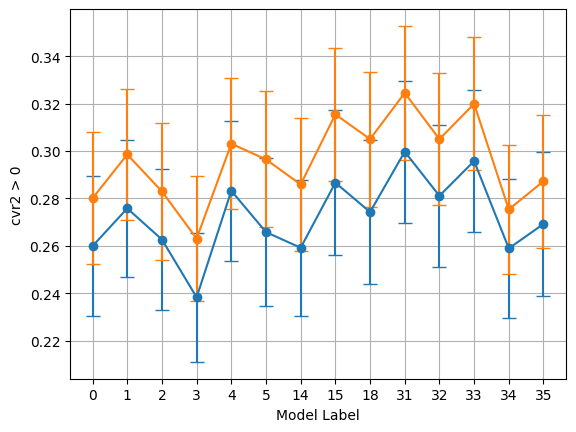

In [326]:
# plt.errorbar(x=rez.columns, y=rez.mean(), yerr=rez.sem(), fmt='-o', capsize=5)
# plt.errorbar(x=rez_est.columns, y=rez_est.mean(), yerr=rez_est.sem(), fmt='-o', capsize=5)
plt.errorbar(x=np.arange(100,100+len(rez.columns)), y=rez.mean(), yerr=rez.sem(), fmt='-o', capsize=5)
plt.errorbar(x=np.arange(100,100+len(rez.columns)), y=rez_est.mean(), yerr=rez_est.sem(), fmt='-o', capsize=5)
plt.xlabel('Model Label')
plt.ylabel('cvr2 > 0')
plt.grid()
plt.xticks(np.arange(100,100+len(rez.columns)));
plt.gca().set_xticklabels(rez.columns);

In [327]:
compare_gt_vs_est.loc[4]

Mean gt             0.283238
Mean est             0.30313
T                   -2.03866
dof                       38
alternative        two-sided
p-val               0.048486
CI95%          [-0.04, -0.0]
cohen-d             0.111276
BF10                   1.107
power               0.104016
Name: 4, dtype: object

In [328]:
rez.columns

Index([0, 1, 2, 3, 4, 5, 14, 15, 18, 31, 32, 33, 34, 35], dtype='int64', name='model_label')

In [329]:
compare_res_gt = []
# Iterate over the model pairs and perform paired t-tests
# for (mo1, mo2) in [(4, 12), (4, 14), (4, 15), (18, 4), (25,31)]:
for (mo1, mo2) in itertools.combinations([0, 1, 2, 3, 4, 5, 14, 15, 18, 31, 32, 33, 34, 35], 2): # 18, 25, 
    ttest_result = pg.ttest(x=rez[mo1], y=rez[mo2], paired=True)
    # Append the results to the list, including the t-test result as a row
    compare_res_gt.append({
        'Model1': mo1,
        'Model2': mo2,
        'Mean Model 1': rez[mo1].mean(),
        'Mean Model 2': rez[mo2].mean(),
        **ttest_result.iloc[0].to_dict()  # Add all columns from the t-test result
    })
compare_res_gt = pd.DataFrame(compare_res_gt)
compare_res_gt = compare_res_gt.set_index(['Model1', 'Model2'])
compare_res_gt

Mean Model 1  Mean Model 2         T  dof alternative     p-val           CI95%   cohen-d      BF10     power
Model1 Model2                                                                                                               
0      1           0.259915      0.275806 -2.777688   38   two-sided  0.008457   [-0.03, -0.0]  0.087078     4.748  0.082774
       2           0.259915      0.262671 -0.455787   38   two-sided  0.651137   [-0.01, 0.01]  0.014889      0.19  0.050942
       3           0.259915      0.238256  3.236765   38   two-sided  0.002509    [0.01, 0.04]  0.121974    13.642  0.115177
       4           0.259915      0.283238 -4.379767   38   two-sided  0.000090  [-0.03, -0.01]  0.126631   268.951  0.120380
       5           0.259915      0.265790 -0.916787   38   two-sided  0.365036   [-0.02, 0.01]  0.031012     0.255  0.054094
...                     ...           ...       ...  ...         ...       ...             ...       ...       ...       ...
32     34          0.281107      0.258916  3.153435   38   two-sided  0.003148    [0.01, 0.04]  0.119996    11.181  0.113031
       35          0.281107      0.269221  1.660205   38   two-sided  0.105104    [-0.0, 0.03]  0.063190     0.604  0.067124
33     34          0.295812      0.258916  4.994500   38   two-sided  0.000014    [0.02, 0.05]  0.199469  1530.436  0.228695
       35          0.295812      0.269221  3.678817   38   two-sided  0.000723    [0.01, 0.04]  0.141340    41.081  0.138184
34     35          0.258916      0.269221 -3.636648   38   two-sided  0.000816   [-0.02, -0.0]  0.055313    36.864  0.063092

[91 rows x 10 columns]

In [ ]:
old_compare_res_est = []
# Iterate over the model pairs and perform paired t-tests
#for (mo1, mo2) in [(4, 12), (4, 14), (4, 15), (18, 4)]:
for (mo1, mo2) in itertools.combinations([0, 1, 2, 3, 4, 5, 14, 15, 18, 25, 31, 32, 33, ], 2): 
    ttest_result = pg.ttest(x=old_rez_est[mo1], y=old_rez_est[mo2], paired=True)
    # Append the results to the list, including the t-test result as a row
    old_compare_res_est.append({
        'Model1': mo1,
        'Model2': mo2,
        'Mean Model 1': old_rez_est[mo1].mean(),
        'Mean Model 2': old_rez_est[mo2].mean(),
        **ttest_result.iloc[0].to_dict()  # Add all columns from the t-test result
    })
old_compare_res_est = pd.DataFrame(old_compare_res_est)
old_compare_res_est = old_compare_res_est.set_index(['Model1', 'Model2'])
#old_compare_res_est

In [331]:
compare_res_est = []
# Iterate over the model pairs and perform paired t-tests
#for (mo1, mo2) in [(4, 12), (4, 14), (4, 15), (18, 4)]:
for (mo1, mo2) in itertools.combinations([0, 1, 2, 3, 4, 5, 14, 15, 18, 31, 32, 33, 34, 35], 2): # 25, 
    ttest_result = pg.ttest(x=rez_est[mo1], y=rez_est[mo2], paired=True)
    # Append the results to the list, including the t-test result as a row
    compare_res_est.append({
        'Model1': mo1,
        'Model2': mo2,
        'Mean Model 1': rez_est[mo1].mean(),
        'Mean Model 2': rez_est[mo2].mean(),
        **ttest_result.iloc[0].to_dict()  # Add all columns from the t-test result
    })
compare_res_est = pd.DataFrame(compare_res_est)
compare_res_est = compare_res_est.set_index(['Model1', 'Model2'])
compare_res_est

Mean Model 1  Mean Model 2         T  dof alternative         p-val           CI95%   cohen-d       BF10     power
Model1 Model2                                                                                                                    
0      1           0.280115      0.298597 -2.826445   38   two-sided  7.464772e-03  [-0.03, -0.01]  0.106270      5.285  0.099169
       2           0.280115      0.282952 -0.412710   38   two-sided  6.821385e-01   [-0.02, 0.01]  0.015951      0.187  0.051081
       3           0.280115      0.263062  2.028175   38   two-sided  4.959473e-02     [0.0, 0.03]  0.100284      1.087  0.093683
       4           0.280115      0.303130 -3.727331   38   two-sided  6.283716e-04  [-0.04, -0.01]  0.132439     46.568  0.127160
       5           0.280115      0.296499 -2.331584   38   two-sided  2.512463e-02   [-0.03, -0.0]  0.092669      1.894  0.087194
...                     ...           ...       ...  ...         ...           ...             ...       ...        ...       ...
32     34          0.305058      0.275352  4.455568   38   two-sided  7.152318e-05    [0.02, 0.04]  0.172507    332.018  0.182787
       35          0.305058      0.287309  2.373600   38   two-sided  2.277442e-02     [0.0, 0.03]  0.101667      2.055  0.094921
33     34          0.319992      0.275352  6.179811   38   two-sided  3.226669e-07    [0.03, 0.06]  0.257547  4.913e+04  0.347671
       35          0.319992      0.287309  4.514648   38   two-sided  5.969090e-05    [0.02, 0.05]  0.186025    391.585  0.204980
34     35          0.275352      0.287309 -4.057709   38   two-sided  2.378594e-04  [-0.02, -0.01]  0.069036    111.537  0.070475

[91 rows x 10 columns]

In [332]:
model_names

{-1: 'No tuning (null model)',
 0: 'No shift (μ_wide = μ_narrow)',
 1: 'Fixed shift (δ=2, no range constraint)',
 2: 'Fitted shift ratio, shared across voxels',
 3: 'Fitted shift ratio, free per voxel',
 4: 'Efficient coding: fixed shift (δ=2)',
 5: 'Efficient coding: shared shift ratio',
 14: 'Free width ratio, per voxel',
 15: 'Fitted width scaling, shared across voxels',
 18: 'Fitted shift + width scaling, shared across voxels',
 31: 'Fixed width scaling (δ_σ=1.29)',
 32: 'Fixed width scaling + free amplitude ratio',
 33: 'Fixed width scaling + shared amplitude ratio',
 34: 'Fixed tuning, free amplitude per voxel',
 35: 'Fixed tuning, shared amplitude ratio'}

In [601]:
index_filter(compare_res_est, Model2=4,)

,Mean Model 1,Mean Model 2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model1,,,,,,,,,,
0,0.280115,0.30313,-3.727331,38,two-sided,6.283716e-04,"[-0.04, -0.01]",0.132439,46.568,0.127160
1,0.298597,0.30313,-2.347626,38,two-sided,2.420266e-02,"[-0.01, -0.0]",0.026106,1.954,0.052899
2,0.282952,0.30313,-3.420210,38,two-sided,1.508698e-03,"[-0.03, -0.01]",0.113611,21.358,0.106359
3,0.263062,0.30313,-8.299557,38,two-sided,4.628455e-10,"[-0.05, -0.03]",0.236042,2.365e+07,0.300809


In [600]:
index_filter(old_compare_res_est, Model2=4,)

,Mean Model 1,Mean Model 2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model1,,,,,,,,,,
0,0.279088,0.301325,-3.633257,38,two-sided,8.242335e-04,"[-0.03, -0.01]",0.127370,36.545,0.121224
1,0.298597,0.301325,-1.407472,38,two-sided,1.674151e-01,"[-0.01, 0.0]",0.015684,0.428,0.051045
2,0.282952,0.301325,-3.186236,38,two-sided,2.879455e-03,"[-0.03, -0.01]",0.103260,12.088,0.096368
3,0.259048,0.301325,-8.258465,38,two-sided,5.234141e-10,"[-0.05, -0.03]",0.248617,2.104e+07,0.327867


In [335]:
index_filter(old_compare_res_est, Model2=5,)

,Mean Model 1,Mean Model 2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model1,,,,,,,,,,
0,0.279088,0.291914,-1.995938,38,two-sided,5.314412e-02,"[-0.03, 0.0]",0.072274,1.029,0.072464
1,0.298597,0.291914,1.687191,38,two-sided,9.976012e-02,"[-0.0, 0.01]",0.037786,0.629,0.056086
2,0.282952,0.291914,-1.974131,38,two-sided,5.566848e-02,"[-0.02, 0.0]",0.049582,0.992,0.060504
3,0.259048,0.291914,-5.836502,38,two-sided,9.542291e-07,"[-0.04, -0.02]",0.189978,1.785e+04,0.211787
4,0.301325,0.291914,2.592253,38,two-sided,1.345899e-02,"[0.0, 0.02]",0.053155,3.196,0.062084


In [336]:
index_filter(compare_res_est, Model2=5,)

,Mean Model 1,Mean Model 2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model1,,,,,,,,,,
0,0.280115,0.296499,-2.331584,38,two-sided,2.512463e-02,"[-0.03, -0.0]",0.092669,1.894,0.087194
1,0.298597,0.296499,0.671113,38,two-sided,5.062080e-01,"[-0.0, 0.01]",0.011872,0.213,0.050599
2,0.282952,0.296499,-2.521319,38,two-sided,1.600596e-02,"[-0.02, -0.0]",0.075026,2.761,0.074229
3,0.263062,0.296499,-6.966512,38,two-sided,2.729784e-08,"[-0.04, -0.02]",0.193447,4.994e+05,0.217874
4,0.303130,0.296499,2.196206,38,two-sided,3.425123e-02,"[0.0, 0.01]",0.037558,1.468,0.056012


In [337]:
1.345899e-02

0.01345899

In [338]:
old_compare_res_est.reset_index()[(old_compare_res_est.reset_index().Model1 == 18) | (old_compare_res_est.reset_index().Model2 == 18)].set_index(['Model1', 'Model2'])

,,Mean Model 1,Mean Model 2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model1,Model2,,,,,,,,,,
0,18,0.279088,0.305074,-3.370299,38,two-sided,1.734544e-03,"[-0.04, -0.01]",0.147224,18.88,0.145890
1,18,0.298597,0.305074,-1.369453,38,two-sided,1.788971e-01,"[-0.02, 0.0]",0.036826,0.409,0.055779
2,18,0.282952,0.305074,-3.308126,38,two-sided,2.061252e-03,"[-0.04, -0.01]",0.123026,16.214,0.116334
3,18,0.259048,0.305074,-8.871793,38,two-sided,8.522324e-11,"[-0.06, -0.04]",0.267562,1.183e+08,0.370397
4,18,0.301325,0.305074,-0.801768,38,two-sided,4.276727e-01,"[-0.01, 0.01]",0.021289,0.233,0.051927
5,18,0.291914,0.305074,-2.419512,38,two-sided,2.043490e-02,"[-0.02, -0.0]",0.073543,2.25,0.073269
14,18,0.285912,0.305074,-5.557298,38,two-sided,2.304495e-06,"[-0.03, -0.01]",0.108738,7858.129,0.101529
15,18,0.315511,0.305074,2.940512,38,two-sided,5.551349e-03,"[0.0, 0.02]",0.058903,6.824,0.064861
18,25,0.305074,0.321951,-4.020461,38,two-sided,2.657435e-04,"[-0.03, -0.01]",0.094945,100.915,0.089077


In [339]:
compare_res_est.reset_index()[(compare_res_est.reset_index().Model1 == 18) | (compare_res_est.reset_index().Model2 == 18)].set_index(['Model1', 'Model2'])

,,Mean Model 1,Mean Model 2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model1,Model2,,,,,,,,,,
0,18,0.280115,0.305074,-3.244499,38,two-sided,2.455903e-03,"[-0.04, -0.01]",0.141782,13.898,0.138751
1,18,0.298597,0.305074,-1.369453,38,two-sided,1.788971e-01,"[-0.02, 0.0]",0.036826,0.409,0.055779
2,18,0.282952,0.305074,-3.308126,38,two-sided,2.061252e-03,"[-0.04, -0.01]",0.123026,16.214,0.116334
3,18,0.263062,0.305074,-8.403938,38,two-sided,3.389546e-10,"[-0.05, -0.03]",0.244164,3.18e+07,0.318168
4,18,0.303130,0.305074,-0.430974,38,two-sided,6.689219e-01,"[-0.01, 0.01]",0.011065,0.188,0.050520
5,18,0.296499,0.305074,-1.827301,38,two-sided,7.551591e-02,"[-0.02, 0.0]",0.047969,0.78,0.059828
14,18,0.285912,0.305074,-5.557298,38,two-sided,2.304495e-06,"[-0.03, -0.01]",0.108738,7858.129,0.101529
15,18,0.315511,0.305074,2.940512,38,two-sided,5.551349e-03,"[0.0, 0.02]",0.058903,6.824,0.064861
18,31,0.305074,0.324579,-6.328995,38,two-sided,2.015734e-07,"[-0.03, -0.01]",0.109976,7.632e+04,0.102735


In [340]:
pg.ttest(x=old_rez_est[4], y=old_rez_est[5], paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,2.592253,38,two-sided,0.013459,"[0.0, 0.02]",0.053155,3.196,0.062084


In [341]:
pg.ttest(x=rez_est[4], y=rez_est[5], paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,2.196206,38,two-sided,0.034251,"[0.0, 0.01]",0.037558,1.468,0.056012


In [342]:
index_filter( compare_res_est, Model1=[4,5], Model2=35 )

,Mean Model 1,Mean Model 2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model1,,,,,,,,,,
4,0.303130,0.287309,2.429199,38,two-sided,0.019970,"[0.0, 0.03]",0.090650,2.293,0.085564
5,0.296499,0.287309,1.324319,38,two-sided,0.193307,"[-0.0, 0.02]",0.051766,0.387,0.061456


In [343]:
index_filter( compare_res_gt, Model1=[4,5], Model2=35 )

,Mean Model 1,Mean Model 2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model1,,,,,,,,,,
4,0.283238,0.269221,2.522481,38,two-sided,0.015961,"[0.0, 0.03]",0.075081,2.768,0.074265
5,0.265790,0.269221,-0.564554,38,two-sided,0.575695,"[-0.02, 0.01]",0.017881,0.2,0.051359


In [344]:
rez_est[[5,35]].mean()

model_label
5     0.296499
35    0.287309
dtype: float64

In [345]:
rez[[5,35]].mean()

model_label
5     0.265790
35    0.269221
dtype: float64

In [346]:
model_names

{-1: 'No tuning (null model)',
 0: 'No shift (μ_wide = μ_narrow)',
 1: 'Fixed shift (δ=2, no range constraint)',
 2: 'Fitted shift ratio, shared across voxels',
 3: 'Fitted shift ratio, free per voxel',
 4: 'Efficient coding: fixed shift (δ=2)',
 5: 'Efficient coding: shared shift ratio',
 14: 'Free width ratio, per voxel',
 15: 'Fitted width scaling, shared across voxels',
 18: 'Fitted shift + width scaling, shared across voxels',
 31: 'Fixed width scaling (δ_σ=1.29)',
 32: 'Fixed width scaling + free amplitude ratio',
 33: 'Fixed width scaling + shared amplitude ratio',
 34: 'Fixed tuning, free amplitude per voxel',
 35: 'Fixed tuning, shared amplitude ratio'}

## Figure S1

In [347]:
# Model 1: delta_wide is 2
# model 2: delta_wide is free but same across voxels
# model 4: delta_wide is 2 and identity below 10
# model 5: delta_wide is fitted, same across voxels, but identity below 10
# ===> Compare 4 vs 1, and 5 vs 2
index_filter(compare_res_est, Model1=[1,2,4,5], Model2=[1,2,4,5])

Mean Model 1  Mean Model 2         T  dof alternative     p-val           CI95%   cohen-d    BF10     power
Model1 Model2                                                                                                             
1      2           0.298597      0.282952  2.796163   38   two-sided  0.008068     [0.0, 0.03]  0.088022   4.944  0.083500
       4           0.298597      0.303130 -2.347626   38   two-sided  0.024203   [-0.01, -0.0]  0.026106   1.954  0.052899
       5           0.298597      0.296499  0.671113   38   two-sided  0.506208    [-0.0, 0.01]  0.011872   0.213  0.050599
2      4           0.282952      0.303130 -3.420210   38   two-sided  0.001509  [-0.03, -0.01]  0.113611  21.358  0.106359
       5           0.282952      0.296499 -2.521319   38   two-sided  0.016006   [-0.02, -0.0]  0.075026   2.761  0.074229
4      5           0.303130      0.296499  2.196206   38   two-sided  0.034251     [0.0, 0.01]  0.037558   1.468  0.056012

In [348]:
index_filter(compare_res_gt, Model1=[1,2,4,5], Model2=[1,2,4,5])

Mean Model 1  Mean Model 2         T  dof alternative     p-val           CI95%   cohen-d    BF10     power
Model1 Model2                                                                                                             
1      2           0.275806      0.262671  2.962197   38   two-sided  0.005244     [0.0, 0.02]  0.071720   7.169  0.072117
       4           0.275806      0.283238 -2.814304   38   two-sided  0.007701   [-0.01, -0.0]  0.040791   5.146  0.057096
       5           0.275806      0.265790  2.168768   38   two-sided  0.036426     [0.0, 0.02]  0.053412   1.396  0.062202
2      4           0.262671      0.283238 -3.900317   38   two-sided  0.000379  [-0.03, -0.01]  0.111278  73.269  0.104018
       5           0.262671      0.265790 -0.672516   38   two-sided  0.505324   [-0.01, 0.01]  0.016409   0.213  0.051144
4      5           0.283238      0.265790  3.984570   38   two-sided  0.000296    [0.01, 0.03]  0.092237  91.671  0.086842

In [349]:
pd.concat([pg.ttest(x=rez_est[1], y=rez_est[4], paired=True, alternative='less'),
           pg.ttest(x=rez_est[2], y=rez_est[5], paired=True, alternative='less'),
           pg.ttest(x=rez[1], y=rez[4], paired=True, alternative='less'),
           pg.ttest(x=rez[2], y=rez[5], paired=True, alternative='less')],
          keys=['1 vs 4 - Est', '2 vs 5 - Est', '1 vs 4 - gt', '2 vs 5 - gt'])

,,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
1 vs 4 - Est,T-test,-2.347626,38,less,0.012101,"[-inf, -0.0]",0.026106,3.908,0.068811
2 vs 5 - Est,T-test,-2.521319,38,less,0.008003,"[-inf, -0.0]",0.075026,5.522,0.118086
1 vs 4 - gt,T-test,-2.814304,38,less,0.003851,"[-inf, -0.0]",0.040791,10.291,0.081565
2 vs 5 - gt,T-test,-0.672516,38,less,0.252662,"[-inf, 0.0]",0.016409,0.427,0.061271


In [350]:
# Model 32: like model 31, but free amplitudes
# Model 33: Like model 31, but subject-specific amplitude ratios
# ===> Compare 32 vs 31, and 33 vs 31
index_filter(compare_res_est, Model1=[31], Model2=[32,33])

Mean Model 1  Mean Model 2         T  dof alternative         p-val         CI95%   cohen-d       BF10     power
Model1 Model2                                                                                                                  
31     32          0.324579      0.305058  6.117373   38   two-sided  3.929561e-07  [0.01, 0.03]  0.111450  4.086e+04  0.104189
       33          0.324579      0.319992  2.355788   38   two-sided  2.374538e-02   [0.0, 0.01]  0.026023      1.985  0.052881

In [351]:
index_filter(compare_res_gt, Model1=[31], Model2=[32,33])

Mean Model 1  Mean Model 2         T  dof alternative         p-val         CI95%   cohen-d       BF10     power
Model1 Model2                                                                                                                  
31     32          0.299754      0.281107  6.411029   38   two-sided  1.556739e-07  [0.01, 0.02]  0.099822  9.723e+04  0.093274
       33          0.299754      0.295812  2.714824   38   two-sided  9.918061e-03   [0.0, 0.01]  0.021093      4.143  0.051892

In [352]:
pd.concat([pg.ttest(x=rez_est[32], y=rez_est[31], paired=True,), # alternative='less'),
           pg.ttest(x=rez_est[33], y=rez_est[31], paired=True,), # alternative='less'),
           pg.ttest(x=rez[32], y=rez[31], paired=True,), # alternative='less'),
           pg.ttest(x=rez[33], y=rez[31], paired=True,)], # alternative='less')],
          keys=['32 vs 31 - Est', '33 vs 31 - Est', '32 vs 31 - gt', '33 vs 31 - gt'])

,,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
32 vs 31 - Est,T-test,-6.117373,38,two-sided,3.929561e-07,"[-0.03, -0.01]",0.111450,4.086e+04,0.104189
33 vs 31 - Est,T-test,-2.355788,38,two-sided,2.374538e-02,"[-0.01, -0.0]",0.026023,1.985,0.052881
32 vs 31 - gt,T-test,-6.411029,38,two-sided,1.556739e-07,"[-0.02, -0.01]",0.099822,9.723e+04,0.093274
33 vs 31 - gt,T-test,-2.714824,38,two-sided,9.918061e-03,"[-0.01, -0.0]",0.021093,4.143,0.051892


In [353]:
def star_line(ax, x1, x2, y, pval, star_size=10, star_offset=0, star_color='black', line_color='black', line_width=1, vertical_lines_length=0.05, ):
    """
    Draws a star and a line between two x positions at a specified y position on the given axis.
    """
    # Determine the number of stars based on the p-value
    stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
    
    # Draw the stars at the specified position
    ax.text((x1 + x2) / 2, y + star_offset, stars, fontsize=star_size, color=star_color, ha='center', va='bottom')

    # Draw a line between the two x positions at the specified y position
    ax.plot([x1, x2], [y, y], color=line_color, linewidth=line_width)

    if vertical_lines_length != 0:
        # Draw vertical lines at the ends of the horizontal line
        ax.plot([x1, x1], [y - vertical_lines_length, y], color=line_color, linewidth=line_width)
        ax.plot([x2, x2], [y - vertical_lines_length, y], color=line_color, linewidth=line_width)

In [354]:
from matplotlib.transforms import ScaledTranslation

In [355]:
model_names

{-1: 'No tuning (null model)',
 0: 'No shift (μ_wide = μ_narrow)',
 1: 'Fixed shift (δ=2, no range constraint)',
 2: 'Fitted shift ratio, shared across voxels',
 3: 'Fitted shift ratio, free per voxel',
 4: 'Efficient coding: fixed shift (δ=2)',
 5: 'Efficient coding: shared shift ratio',
 14: 'Free width ratio, per voxel',
 15: 'Fitted width scaling, shared across voxels',
 18: 'Fitted shift + width scaling, shared across voxels',
 31: 'Fixed width scaling (δ_σ=1.29)',
 32: 'Fixed width scaling + free amplitude ratio',
 33: 'Fixed width scaling + shared amplitude ratio',
 34: 'Fixed tuning, free amplitude per voxel',
 35: 'Fixed tuning, shared amplitude ratio'}

In [356]:
# fig, ax = plt.subplots(figsize=(7.5, 5))
# C_GT = plt.cm.winter(.7)
# C_EST = plt.cm.autumn(.3)
# modelz = dict( [(0, 'No shift'),(1, '$\mu_w = 2 \mu_n$'), (2, '$\mu_w = r_\mu \mu_n$'),
#                                 (3, 'Free shifts'), (4, 'Efficient shifts'), (5, 'Participant-specific slopes'), 
#                                 (14, 'Free widths'), (31, 'Best-fitting: fixed width-scaling'), (15, 'Participant-specific scaling'),
#                                 (32, 'Free amplitudes'), (33, 'Participant-specific amplitude ratio'),
#                                 (34, 'Fixed tuning, free amplitudes'), (35, 'Fixed-tuning, participant-specific amplitude ratio')
#                                 #(18, 'Participant-specific shift and width scaling'),
#                                 ] )
# x_model = {mo:i for i,mo in enumerate(modelz.keys()) } # absissa positions for the models
# #(4, 'No width change'),
# these_rez_est = rez_est.loc[:,list(modelz.keys())].rename(columns=modelz)
# these_rez = rez.loc[:,list(modelz.keys())].rename(columns=modelz)
# # combine these_rez, these_rez_est, adding an index level
# these_rez_combined = pd.concat([these_rez, these_rez_est], axis=1, keys=['gt', 'est'], names=['type'])
# # these_comp = compare_gt_vs_est.loc[modelz.keys()].rename(modelz)
# # these_comp
# sns.pointplot(these_rez, errorbar='se', color=C_GT, markersize=5, linewidth=1, ax=ax, capsize=.1)
# sns.pointplot(these_rez_est, errorbar='se', color=C_EST, markersize=5, linewidth=1, ax=ax, capsize=.1)
# ax.set_xlabel(None)
# handles = [plt.Line2D([0], [0], color=C_EST, lw=1, label='Estimates'),
#            plt.Line2D([0], [0], color=C_GT, lw=1, label='Correct numbers')]
# ax.legend(handles=handles, loc='lower left')
# #### x ticks labels positions
# ax.tick_params(axis='both', tickdir='in', length=2)
# plt.setp(ax.get_xticklabels(), rotation=20, ha='right', va='top', rotation_mode="anchor");
# # Create offset transform
# dx = 12./72.; dy = 2/72. 
# offset = ScaledTranslation(dx, dy, fig.dpi_scale_trans)
# # apply offset transform to all x ticklabels.
# for label in ax.xaxis.get_majorticklabels(): label.set_transform(label.get_transform() + offset)
# #
# ax.set_yticks([.22, .24, .26, .28, .3, .32, .34])
# ax.set_yticklabels(['.22', '.24', '.26', '.28', '.30', '.32', '.34'])
# ax.set_ylabel('% cv$R^2$ > 0', y=.6, ha='right')
# #
# ax.spines.left.set_bounds((.22, .34))
# ax.spines.bottom.set_bounds((0, len(modelz)-1))
# sns.despine(fig)
# #
# for i,k in enumerate( modelz.keys()):
#     r = compare_gt_vs_est.loc[k]
#     stars = '***' if r['p-val'] < 0.001 else '**' if r['p-val'] < 0.01 else '*' if r['p-val'] < 0.05 else ''
#     x = i #+ 0.1
#     y = r['Mean est'] + .035
#     ax.text(x, y, stars, ha='center', va='center', fontsize=12)
# ax.set_xlim(-.5,len(modelz)+.5)
# #ax.set_title('Models fits')
# #ax.set_ylim(None, .38)

# # tests 1-4, 2-5
# r = pg.ttest(x=rez_est[1], y=rez_est[4], paired=True, ).iloc[0] # alternative='less'
# print(rez_est[4].mean() - rez_est[1].mean())
# print(f"1,4 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
# r = pg.ttest(x=rez_est[2], y=rez_est[5], paired=True, ).iloc[0] # alternative='less'
# print(f"2,5 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
# #star_line(ax, 2, 5, .345, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=.002)
# r = pg.ttest(x=rez[1], y=rez[4], paired=True, ).iloc[0] # alternative='less'
# print(f"1,4  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
# star_line(ax, 1, 4, .365, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=.002)
# r = pg.ttest(x=rez[2], y=rez[5], paired=True, ).iloc[0] # alternative='less'
# print(f"2,5  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")

# # print('##')
# # r = pg.ttest(x=rez_est[1], y=rez_est[2], paired=True, ).iloc[0]
# # print(f"1,2 est $t({r.dof})={r['T']:.2f}$, $P={r['p-val']:.2g}$")
# # star_line(ax, 1, 2, .345, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=.002)
# # r = pg.ttest(x=rez[1], y=rez[2], paired=True, ).iloc[0]
# # print(f"1,2  gt $t({r.dof})={r['T']:.2f}$, $P={r['p-val']:.2g}$")
# # star_line(ax, 1, 2, .355, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=.002)

# print('##')
# r = pg.ttest(x=rez_est[2], y=rez_est[4], paired=True, ).iloc[0]
# print(f"2,4 est $t({r.dof})={r['T']:.2f}$, $P={r['p-val']:.2g}$")
# star_line(ax, 2, 4, .345, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=.002)
# r = pg.ttest(x=rez[2], y=rez[4], paired=True, ).iloc[0]
# print(f"2,4  gt $t({r.dof})={r['T']:.2f}$, $P={r['p-val']:.2g}$")
# star_line(ax, 2, 4, .355, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=.002)

# print('##')
# # tests 33, 32 vs 31
# r = pg.ttest(x=rez_est[32], y=rez_est[31], paired=True,).iloc[0] # alternative='less'),
# print(f"32,31 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
# star_line(ax,  x_model[32], x_model[31], .245, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=-.002, star_offset=-.008)
# r = pg.ttest(x=rez_est[33], y=rez_est[31], paired=True,).iloc[0] # alternative='less'),
# print(f"33,31 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
# star_line(ax,  x_model[33], x_model[31], .237, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=-.002, star_offset=-.008)
# r = pg.ttest(x=rez[32], y=rez[31], paired=True,).iloc[0] # alternative='less'),
# print(f"32,31  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
# star_line(ax,  x_model[32], x_model[31], .225, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=-.002, star_offset=-.008)
# r = pg.ttest(x=rez[33], y=rez[31], paired=True,).iloc[0] # alternative='less'),
# print(f"33,31  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
# star_line(ax,  x_model[33], x_model[31], .217, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=-.002, star_offset=-.008)

# print('##')
# # test 18 vs 31
# if 18 in rez_est.columns:
#     r = pg.ttest(x=rez_est[18], y=rez_est[31], paired=True,).iloc[0] # alternative='less'),
#     print(f"18,31 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
#     #star_line(ax,  x_model[18], x_model[31], .245, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=-.002, star_offset=-.008)
#     r = pg.ttest(x=rez[18], y=rez[31], paired=True,).iloc[0] # alternative='less'),
#     print(f"18,31  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
#     #star_line(ax,  x_model[18], x_model[31], .225, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=-.002, star_offset=-.008)

# ax.grid(c='#FaFaFa', zorder=-10000)

# #fig.savefig('figures/models_fits.pdf', bbox_inches='tight')


In [357]:
rez[31].mean()

0.29975373145843764

0.004532752774616511
1,4 est $P=0.024$, $t(38)=-2.35$
2,5 est $P=0.016$, $t(38)=-2.52$
1,4  gt $P=0.0077$, $t(38)=-2.81$
2,5  gt $P=0.51$, $t(38)=-0.67$
##
4,5 est $P=0.034$, $t(38)=2.20$
4,5  gt $P=0.0003$, $t(38)=3.98$
##
2,4 est $t(38)=-3.42$, $P=0.0015$
2,4  gt $t(38)=-3.90$, $P=0.00038$
##
32,31 est $P=3.9e-07$, $t(38)=-6.12$
33,31 est $P=0.024$, $t(38)=-2.36$
32,31  gt $P=1.6e-07$, $t(38)=-6.41$
33,31  gt $P=0.0099$, $t(38)=-2.71$
##
18,31 est $P=2e-07$, $t(38)=-6.33$
18,31  gt $P=3e-06$, $t(38)=-5.47$
(0.20337060406589097, 0.3706013998063861)


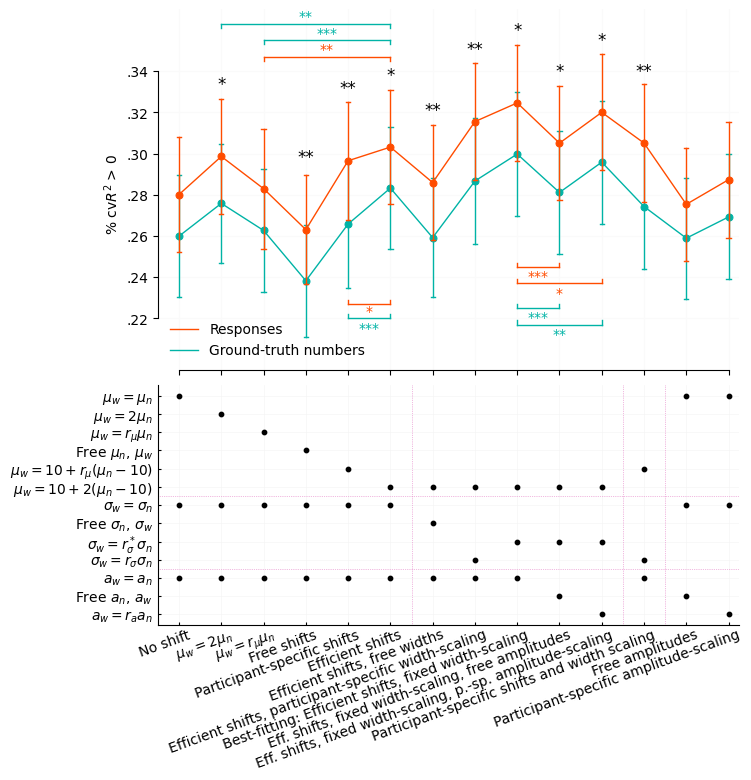

In [457]:
fig, axs = plt.subplots(nrows=2, figsize=(7.5, 8), sharex=True, height_ratios=[.6,.4])
C_GT = plt.cm.winter(.7)
C_EST = plt.cm.autumn(.3)
# modelz = dict( [(0, 'No shift'),(1, '$\mu_w = 2 \mu_n$'), (2, '$\mu_w = r_\mu \mu_n$'),
#                                 (3, 'Free shifts'), (5, 'Participant-specific slopes'), (4, 'Efficient shifts'), 
#                                 (14, 'Free widths'), (31, 'Best-fitting: fixed width-scaling'), (15, 'Participant-specific scaling'),
#                                 (32, 'Free amplitudes'), (33, 'Participant-specific amplitude ratio'),
#                                 (34, 'Fixed tuning, free amplitudes'), (35, 'Fixed-tuning, participant-specific amplitude ratio')
#                                 #(18, 'Participant-specific shift and width scaling'),
#                                 ] )
modelz = dict( [(0, 'No shift'),(1, '$\mu_w = 2 \mu_n$'), (2, '$\mu_w = r_\mu \mu_n$'),
                (3, 'Free shifts'),
                (5, 'Participant-specific shifts'),
                (4, 'Efficient shifts'), 
                (14, 'Efficient shifts, free widths'),
                (15, 'Efficient shifts, participant-specific width-scaling'),
                (31, 'Best-fitting: Efficient shifts, fixed width-scaling'),
                (32, 'Eff. shifts, fixed width-scaling, free amplitudes'),
                (33, 'Eff. shifts, fixed width-scaling, p.-sp. amplitude-scaling'),
                (18, 'Participant-specific shifts and width scaling'),
                (34, 'Free amplitudes'),
                (35, 'Participant-specific amplitude-scaling')
                ] )
x_model = {mo:i for i,mo in enumerate(modelz.keys()) } # absissa positions for the models
these_rez_est = rez_est.loc[:,list(modelz.keys())].rename(columns=modelz) #.rename(columns={k:(v+f' ({k})') for k,v in modelz.items()}) #
these_rez = rez.loc[:,list(modelz.keys())].rename(columns=modelz) #.rename(columns={k:(v+f' ({k})') for k,v in modelz.items()}) #.rename(columns=modelz)
# combine these_rez, these_rez_est, adding an index level
these_rez_combined = pd.concat([these_rez, these_rez_est], axis=1, keys=['gt', 'est'], names=['type'])

######### plot cvr2s
ax = axs[0]
sns.pointplot(these_rez, errorbar='se', color=C_GT, markersize=5, linewidth=1, ax=ax, capsize=.1)
sns.pointplot(these_rez_est, errorbar='se', color=C_EST, markersize=5, linewidth=1, ax=ax, capsize=.1)
ax.set_xlabel(None)
handles = [plt.Line2D([0], [0], color=C_EST, lw=1, label='Responses'),
           plt.Line2D([0], [0], color=C_GT, lw=1, label='Ground-truth numbers')]
ax.legend(handles=handles, loc='lower left')
ax.set_yticks([.22, .24, .26, .28, .3, .32, .34])
ax.set_yticklabels(['.22', '.24', '.26', '.28', '.30', '.32', '.34'])
ax.set_ylabel('% cv$R^2$ > 0', y=.6, ha='right')
#
ax.spines.left.set_bounds((.22, .34))
ax.spines.bottom.set_bounds((0, len(modelz)-1))
sns.despine(fig)
#
for i,k in enumerate( modelz.keys()):
    r = compare_gt_vs_est.loc[k]
    if r['p-val'] < 0.05:
        stars = '***' if r['p-val'] < 0.001 else '**' if r['p-val'] < 0.01 else '*' #if r['p-val'] < 0.05 else ''
        x = i #+ 0.1
        y = r['Mean est'] + .035
        ax.text(x, y, stars, ha='center', va='center', fontsize=12)
ax.set_xlim(-.5,len(modelz)-1+.25)
#ax.set_title('Models fits')

# tests 1-4, 2-5
r = pg.ttest(x=rez_est[1], y=rez_est[4], paired=True, ).iloc[0] # alternative='less'
print(rez_est[4].mean() - rez_est[1].mean())
print(f"1,4 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
r = pg.ttest(x=rez_est[2], y=rez_est[5], paired=True, ).iloc[0] # alternative='less'
print(f"2,5 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
#star_line(ax, 2, 5, .345, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=.002)
r = pg.ttest(x=rez[1], y=rez[4], paired=True, ).iloc[0] # alternative='less'
print(f"1,4  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
star_line(ax, x_model[1], x_model[4], .363, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=.002)
r = pg.ttest(x=rez[2], y=rez[5], paired=True, ).iloc[0] # alternative='less'
print(f"2,5  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")

# test 4-5
print('##')
r = pg.ttest(x=rez_est[4], y=rez_est[5], paired=True, ).iloc[0]
print(f"4,5 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
star_line(ax, x_model[4], x_model[5], .227, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=-.002, star_offset=-.007)
r = pg.ttest(x=rez[4], y=rez[5], paired=True, ).iloc[0]
print(f"4,5  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
star_line(ax, x_model[4], x_model[5], .22, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=-.002, star_offset=-.008)

# print('##')
# r = pg.ttest(x=rez_est[1], y=rez_est[2], paired=True, ).iloc[0]
# print(f"1,2 est $t({r.dof})={r['T']:.2f}$, $P={r['p-val']:.2g}$")
# star_line(ax, 1, 2, .345, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=.002)
# r = pg.ttest(x=rez[1], y=rez[2], paired=True, ).iloc[0]
# print(f"1,2  gt $t({r.dof})={r['T']:.2f}$, $P={r['p-val']:.2g}$")
# star_line(ax, 1, 2, .355, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=.002)

print('##')
r = pg.ttest(x=rez_est[2], y=rez_est[4], paired=True, ).iloc[0]
print(f"2,4 est $t({r.dof})={r['T']:.2f}$, $P={r['p-val']:.2g}$")
star_line(ax, x_model[2], x_model[4], .347, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=.002)
r = pg.ttest(x=rez[2], y=rez[4], paired=True, ).iloc[0]
print(f"2,4  gt $t({r.dof})={r['T']:.2f}$, $P={r['p-val']:.2g}$")
star_line(ax, x_model[2], x_model[4], .355, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=.002)

print('##')
# tests 33, 32 vs 31
r = pg.ttest(x=rez_est[32], y=rez_est[31], paired=True,).iloc[0] # alternative='less'),
print(f"32,31 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
star_line(ax,  x_model[32], x_model[31], .245, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=-.002, star_offset=-.008)
r = pg.ttest(x=rez_est[33], y=rez_est[31], paired=True,).iloc[0] # alternative='less'),
print(f"33,31 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
star_line(ax,  x_model[33], x_model[31], .237, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=-.002, star_offset=-.008)
r = pg.ttest(x=rez[32], y=rez[31], paired=True,).iloc[0] # alternative='less'),
print(f"32,31  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
star_line(ax,  x_model[32], x_model[31], .225, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=-.002, star_offset=-.008)
r = pg.ttest(x=rez[33], y=rez[31], paired=True,).iloc[0] # alternative='less'),
print(f"33,31  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
star_line(ax,  x_model[33], x_model[31], .217, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=-.002, star_offset=-.008)

print('##')
# test 18 vs 31
if 18 in rez_est.columns:
    r = pg.ttest(x=rez_est[18], y=rez_est[31], paired=True,).iloc[0] # alternative='less'),
    print(f"18,31 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
    #star_line(ax,  x_model[18], x_model[31], .245, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=-.002, star_offset=-.008)
    r = pg.ttest(x=rez[18], y=rez[31], paired=True,).iloc[0] # alternative='less'),
    print(f"18,31  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
    #star_line(ax,  x_model[18], x_model[31], .225, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=-.002, star_offset=-.008)

ax.grid(c='#FaFaFa', zorder=-10000)

print(ax.get_ylim()) # (0.20337060406589097, 0.3706013998063861)
ax.set_ylim(.195, .37)

####### models' characteristics
ax = axs[1]
chars = ['$\mu_w = \mu_n$', '$\mu_w = 2 \mu_n$', '$\mu_w = r_\mu \mu_n$', 'Free $\mu_n$, $\mu_w$', '$\mu_w = 10 + r_\mu(\mu_n - 10)$', '$\mu_w = 10 + 2(\mu_n - 10)$', 
         '$\sigma_w = \sigma_n$', 'Free $\sigma_n$, $\sigma_w$', '$\sigma_w = r_\sigma^* \sigma_n$', '$\sigma_w = r_\sigma \sigma_n$',  
         '$a_w = a_n$', 'Free $a_n$, $a_w$', '$a_w = r_a a_n$',]
chars_y  = {ch:-i for i,ch in enumerate(chars)}
mo_chars = {}
mo_chars[0] = [ '$\mu_w = \mu_n$', '$\sigma_w = \sigma_n$', '$a_w = a_n$']
mo_chars[1] = [ '$\mu_w = 2 \mu_n$', '$\sigma_w = \sigma_n$', '$a_w = a_n$']
mo_chars[2] = [ '$\mu_w = r_\mu \mu_n$', '$\sigma_w = \sigma_n$', '$a_w = a_n$']
mo_chars[3] = [ 'Free $\mu_n$, $\mu_w$', '$\sigma_w = \sigma_n$', '$a_w = a_n$']
mo_chars[4] = [ '$\mu_w = 10 + 2(\mu_n - 10)$', '$\sigma_w = \sigma_n$', '$a_w = a_n$']
mo_chars[5] = [ '$\mu_w = 10 + r_\mu(\mu_n - 10)$', '$\sigma_w = \sigma_n$', '$a_w = a_n$']
mo_chars[14] = [ '$\mu_w = 10 + 2(\mu_n - 10)$', 'Free $\sigma_n$, $\sigma_w$', '$a_w = a_n$']
mo_chars[15] = [ '$\mu_w = 10 + 2(\mu_n - 10)$', '$\sigma_w = r_\sigma \sigma_n$', '$a_w = a_n$']
mo_chars[18] = [ '$\mu_w = 10 + r_\mu(\mu_n - 10)$', '$\sigma_w = r_\sigma \sigma_n$', '$a_w = a_n$']
mo_chars[31] = [ '$\mu_w = 10 + 2(\mu_n - 10)$', '$\sigma_w = r_\sigma^* \sigma_n$', '$a_w = a_n$']
mo_chars[32] = [ '$\mu_w = 10 + 2(\mu_n - 10)$', '$\sigma_w = r_\sigma^* \sigma_n$', 'Free $a_n$, $a_w$']
mo_chars[33] = [ '$\mu_w = 10 + 2(\mu_n - 10)$', '$\sigma_w = r_\sigma^* \sigma_n$', '$a_w = r_a a_n$']
mo_chars[34] = [ '$\mu_w = \mu_n$', '$\sigma_w = \sigma_n$', 'Free $a_n$, $a_w$']
mo_chars[35] = [ '$\mu_w = \mu_n$', '$\sigma_w = \sigma_n$', '$a_w = r_a a_n$']

for mo in modelz.keys():
    x_mo = x_model[mo]
    if mo not in mo_chars:
        print(f'Model {mo} has no characteristics defined')
        continue
    for ch in mo_chars[mo]:
        y_ch = chars_y[ch]
        ax.scatter(x_mo, y_ch, color='black', zorder=1000, s=10) #, marker='x')

ax.set_yticks(list(chars_y.values()))
ax.set_yticklabels(chars_y.keys());

ax.axhline(-5.5, color='C6', lw=.5, ls=':')
ax.axhline(-9.5, color='C6', lw=.5, ls=':')

ax.axvline( 5.5, color='C6', lw=.5, ls=':')
ax.axvline(10.5, color='C6', lw=.5, ls=':')
ax.axvline(11.5, color='C6', lw=.5, ls=':')

# ylm = ax.get_ylim(); print(ylm)
# ax.plot([4.5, 4.5], [.6,-5.5], color='C6', lw=.5, ls=':')
# ax.plot([5.5, 5.5], [-5.5,-9.5], color='C6', lw=.5, ls=':')
# ax.plot([8.5, 8.5], [-9.5, -12.5], color='C6', lw=.5, ls=':')
# ax.set_ylim(ylm)

# ylm = ax.get_ylim(); print(ylm)
# ax.scatter(x_model[31], ylm[0], marker='*', color='yellow', ec='grey', lw=1, s=100, clip_on=False, zorder=10000)
# ax.set_ylim(ylm)

ax.grid(zorder=-1000, c='#F5F5F5', lw=.5);

# ax.annotate('Same widths', xy=(2.5, -7.5), ha='center', va='center', fontsize=9, bbox=dict(boxstyle="round,pad=0.4", fc="w", lw=0.5, ec='lightgrey'))
# ax.annotate('Same amplitudes', xy=(2.5, -11.25), ha='center', va='center', fontsize=9, bbox=dict(boxstyle="round,pad=0.4", fc="w", lw=0.5, ec='lightgrey'))
# ax.annotate('Efficient shifts', xy=(8, -3), ha='center', va='center', fontsize=9, bbox=dict(boxstyle="round,pad=0.4", fc="w", lw=0.5, ec='lightgrey'))

#### x ticks labels positions
ax.tick_params(axis='both', tickdir='in', length=2)
ax.set_xticks(range(len(modelz)))
#ax.set_xticklabels(relabel_modelz.values())
plt.setp(ax.get_xticklabels(), rotation=20, ha='right', va='top', rotation_mode="anchor");
# Create offset transform
dx = 6./72.; dy = 2/72. 
offset = ScaledTranslation(dx, dy, fig.dpi_scale_trans)
# apply offset transform to all x ticklabels.
for label in ax.xaxis.get_majorticklabels(): label.set_transform(label.get_transform() + offset)
#

fig.subplots_adjust(hspace=.05)

fig.savefig('figures/models_fits.pdf', bbox_inches='tight')


In [431]:
index_filter( compare_res_est, Model1=[5,15,], Model2=18 )

,Mean Model 1,Mean Model 2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model1,,,,,,,,,,
5,0.296499,0.305074,-1.827301,38,two-sided,0.075516,"[-0.02, 0.0]",0.047969,0.78,0.059828
15,0.315511,0.305074,2.940512,38,two-sided,0.005551,"[0.0, 0.02]",0.058903,6.824,0.064861


In [397]:
rez_est[5].mean(), rez_est[35].mean()

(0.296499445753637, 0.28730853803264306)

In [398]:
pg.ttest(x=rez_est[4], y=rez_est[35], paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,2.429199,38,two-sided,0.01997,"[0.0, 0.03]",0.09065,2.293,0.085564


In [399]:
index_filter( compare_res_est, Model1=[4,5], Model2=35 )

,Mean Model 1,Mean Model 2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model1,,,,,,,,,,
4,0.303130,0.287309,2.429199,38,two-sided,0.019970,"[0.0, 0.03]",0.090650,2.293,0.085564
5,0.296499,0.287309,1.324319,38,two-sided,0.193307,"[-0.0, 0.02]",0.051766,0.387,0.061456


In [400]:
index_filter( compare_res_gt, Model1=[4,5], Model2=35 )

,Mean Model 1,Mean Model 2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model1,,,,,,,,,,
4,0.283238,0.269221,2.522481,38,two-sided,0.015961,"[0.0, 0.03]",0.075081,2.768,0.074265
5,0.265790,0.269221,-0.564554,38,two-sided,0.575695,"[-0.02, 0.01]",0.017881,0.2,0.051359


In [401]:
pg.ttest(x=old_rez_est[5], y=rez_est[35], paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.734776,38,two-sided,0.466987,"[-0.01, 0.02]",0.025912,0.222,0.052856


In [402]:
pg.ttest(x=old_rez[5], y=rez[35], paired=True)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-0.569883,38,two-sided,0.572111,"[-0.02, 0.01]",0.018052,0.201,0.051385


In [403]:
index_filter( compare_res_gt, Model1=[3,4,5], Model2=34 )

,Mean Model 1,Mean Model 2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model1,,,,,,,,,,
3,0.238256,0.258916,-3.754358,38,two-sided,0.000581,"[-0.03, -0.01]",0.116816,49.953,0.109659
4,0.283238,0.258916,4.334735,38,two-sided,0.000103,"[0.01, 0.04]",0.132545,237.453,0.127287
5,0.265790,0.258916,1.048144,38,two-sided,0.301193,"[-0.01, 0.02]",0.036411,0.287,0.055649


In [404]:
print( rez_est[3].mean(), rez_est[34].mean() )
pg.ttest(x=rez_est[3], y=rez_est[34], paired=True)

0.26306227358792245 0.27535213544954856


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-1.964664,38,two-sided,0.056796,"[-0.02, 0.0]",0.072992,0.976,0.072918


In [405]:
from matplotlib.colors import to_hex

to_hex(C_GT)

'#00b3a6'

In [406]:
pg.ttest(x=rez_est[1], y=rez_est[4], paired=True, alternative='less').iloc[0] #['p-val']

T                 -2.347626
dof                      38
alternative            less
p-val              0.012101
CI95%          [-inf, -0.0]
cohen-d            0.026106
BF10                  3.908
power              0.068811
Name: T-test, dtype: object

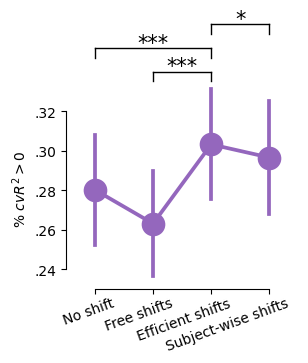

In [407]:
fig, ax = plt.subplots(figsize=(3, 3.6))
modelz = dict( [(0, 'No shift'), (3, 'Free shifts'), (4, 'Efficient shifts'), (5, 'Subject-wise shifts')] )
these_rez = rez_est.loc[:,list(modelz.keys())].rename(columns=modelz)
these_rez
#sns.stripplot(these_rez, color=FOURTH_COLOR) 
sns.pointplot(these_rez, errorbar='se', color=FOURTH_COLOR, markersize=15, ax=ax)
ax.set_xlabel(None)
#### x ticks labels positions
plt.setp(ax.get_xticklabels(), rotation=20, ha='right', va='top', rotation_mode="anchor")
# Create offset transform
dx = 12/72.; dy = 2/72. 
offset = ScaledTranslation(dx, dy, fig.dpi_scale_trans)
# apply offset transform to all x ticklabels.
for label in ax.xaxis.get_majorticklabels(): label.set_transform(label.get_transform() + offset)
ax.set_xlim(-.5,3.5)
#### y 
ax.set_yticks([.24, .26, .28, .3, .32])
ax.set_yticklabels(['.24', '.26', '.28', '.30', '.32'])
ax.set_ylabel('% $cvR^2 > 0$', y=.5, ha='right')
#ax.set_ylim(.23, .33)
ax.spines.left.set_bounds((.24, .32))
ax.spines.bottom.set_bounds((0, 3))
sns.despine(fig)
# (0,4), (3,4), (5,4) 
vll = 0.005
star_size = 15
star_offset = -.0025
star_line(ax, 0, 2, .352, compare_res_est.loc[(0,4)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
star_line(ax, 1, 2, .340, compare_res_est.loc[(3,4)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
star_line(ax, 3, 2, .364, compare_res_est.loc[(4,5)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)

In [408]:
these_rez

model_label,No shift,Free shifts,Efficient shifts,Subject-wise shifts
subject,,,,
1,0.149157,0.105058,0.138781,0.121920
2,0.117442,0.139535,0.184884,0.176744
3,0.092437,0.051821,0.121849,0.106443
4,0.216774,0.221935,0.249032,0.245161
5,0.172821,0.096012,0.168390,0.118168
6,0.180124,0.146584,0.181366,0.152795
7,0.428251,0.378924,0.414798,0.413677
8,0.347484,0.334906,0.426101,0.419811
9,0.485086,0.434851,0.492936,0.474097


In [409]:
df33 = index_filter(pars, type='estimates', smoothed=True, model_label=33, ) 
df33.amplitude.wide / df33.amplitude.narrow

KeyError: "'type' not found in MultiIndex levels ['subject', 'model_label', 'response_fit', 'voxel'] or columns."

(array([ 1.,  0.,  0.,  0.,  0.,  6., 15., 12.,  4.,  1.]),
 array([0.66450057, 0.70962245, 0.75474432, 0.7998662 , 0.84498807, 0.89010994, 0.93523182, 0.98035369, 1.02547557, 1.07059744, 1.11571931]),
 <BarContainer object of 10 artists>)

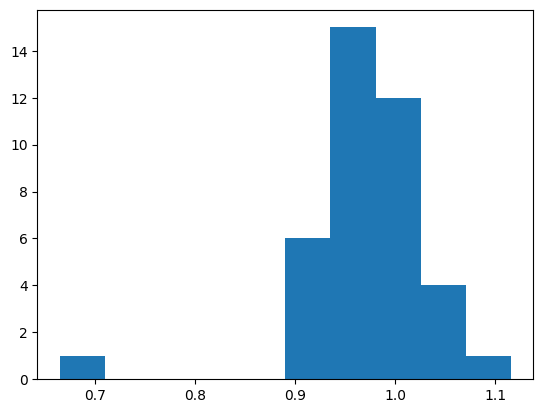

In [47]:
amp_ratios = df33.groupby('subject').first().amplitude.wide / df33.groupby('subject').first().amplitude.narrow
plt.hist(amp_ratios, bins=10)

In [48]:
amp_ratios.describe()

count    39.000000
mean      0.972722
std       0.067116
min       0.664501
25%       0.950117
50%       0.975984
75%       1.003974
max       1.115719
dtype: float64

In [49]:
pg.ttest(amp_ratios, 1)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-2.538209,38,two-sided,0.015362,"[0.95, 0.99]",0.406439,2.858,0.696266


## Median cvR2

In [410]:
model_list = [0,1,2,3,4,5,14,15,18,31,32,33,34,35] #### Only keeping these models
print(len(model_list))
# cvr2s = index_filter(pars, model_label=model_list).cvr2
# print( cvr2s.index.get_level_values('smoothed').unique() )
# cvr2s.index = cvr2s.index.droplevel('smoothed')
#cvr2s = cvr2s.squeeze("columns")
cvr2s = index_filter(pars, model_label=model_list).cvr2
cvr2s

14


subject  model_label  response_fit  voxel
1        0            False         0       -0.019311
                                    1       -0.019491
                                    2       -0.026083
                                    3       -0.022119
                                    4       -0.015362
                                               ...   
41       35           True          689      0.002408
                                    690     -0.010143
                                    691     -0.007799
                                    692     -0.008265
                                    693     -0.014594
Name: cvr2, Length: 854924, dtype: float64

In [411]:
keep_sv = cvr2s.gt(0).groupby(level=["subject", "voxel"]).any()
keep_sv

subject  voxel
1        0        False
         1        False
         2        False
         3        False
         4        False
                  ...  
41       689       True
         690      False
         691       True
         692      False
         693       True
Name: cvr2, Length: 30533, dtype: bool

In [412]:
#sv = cvr2s.index.droplevel(["type", "model_label"])           # index aligned to rows, but only (subject, voxel)
sv = cvr2s.index.droplevel(["model_label", "response_fit"])           # index aligned to rows, but only (subject, voxel)
mask = keep_sv.reindex(sv).to_numpy()
cvr2s_filtered = cvr2s.loc[mask]
cvr2s_filtered

subject  model_label  response_fit  voxel
1        0            False         7       -0.007489
                                    10       0.006088
                                    13       0.012343
                                    14       0.003788
                                    16       0.012375
                                               ...   
41       35           True          687      0.010161
                                    688     -0.011249
                                    689      0.002408
                                    691     -0.007799
                                    693     -0.014594
Name: cvr2, Length: 431508, dtype: float64

In [413]:
cvr2s_filtered.groupby(level=["subject", "voxel"]).count()

subject  voxel
1        7        28
         10       28
         13       28
         14       28
         16       28
                  ..
41       687      28
         688      28
         689      28
         691      28
         693      28
Name: cvr2, Length: 15411, dtype: int64

In [414]:
old_cvr2s = index_filter(old_pars, model_label=model_list).cvr2
old_cvr2s.index = old_cvr2s.index.droplevel('smoothed')
old_cvr2s = old_cvr2s.squeeze("columns")
old_keep_sv = old_cvr2s.gt(0).groupby(level=["subject", "voxel"]).any()
old_sv = old_cvr2s.index.droplevel(["type", "model_label"])           # index aligned to rows, but only (subject, voxel)
old_mask = old_keep_sv.reindex(old_sv).to_numpy()
old_cvr2s_filtered = old_cvr2s.loc[old_mask]
old_cvr2s_filtered

type          subject  model_label  voxel
ground_truth  1        0            3       -0.021961
                                    7       -0.007448
                                    10       0.006230
                                    13       0.012389
                                    14       0.003699
                                               ...   
estimates     41       33           687      0.014492
                                    688     -0.003951
                                    689      0.011950
                                    691      0.002292
                                    693     -0.006012
Name: nan, Length: 365088, dtype: float64

In [415]:
# ytype = 'ground_truth'
# da = index_filter(cvr2s_filtered, type=ytype)
da = index_filter(cvr2s_filtered, response_fit=False)
rez_median = da.groupby(['subject', 'model_label']).median()
rez_median = rez_median.unstack()
rez_median

model_label,0,1,2,3,4,5,14,15,18,31,32,33,34,35
subject,,,,,,,,,,,,,,
1,-0.002587,-0.001296,-0.004558,-0.005694,-0.000106,-0.002781,-0.002727,-0.003330,-0.003579,0.001845,0.000785,0.001003,-0.003916,-0.001921
2,-0.003056,-0.003416,-0.006001,-0.006278,-0.003124,-0.005343,-0.006311,-0.003566,-0.005564,-0.003501,-0.004015,-0.003508,-0.004337,-0.004310
3,-0.006709,-0.009248,-0.009684,-0.014745,-0.008335,-0.009225,-0.012349,-0.007701,-0.007722,-0.008420,-0.010341,-0.008911,-0.005278,-0.005621
4,0.001231,0.001209,-0.002801,-0.004484,0.001120,-0.000384,-0.002336,-0.000004,-0.000482,0.001660,0.000615,0.001326,-0.000974,-0.000081
5,0.000005,-0.000601,-0.011288,-0.007012,0.000867,-0.011065,-0.003849,0.000601,-0.003570,0.001896,0.000079,-0.000096,0.001002,0.000459
6,-0.003303,-0.000646,-0.003162,-0.003219,0.000335,-0.001156,0.003088,0.003915,0.001430,0.003257,0.002466,0.002871,-0.002063,-0.001378
7,0.009945,0.010331,0.013128,0.008048,0.011112,0.011027,0.009608,0.014654,0.012534,0.014082,0.013283,0.014172,0.008982,0.010565
8,0.002553,0.001022,0.001447,-0.001869,0.002284,0.001119,0.000378,0.003229,0.003496,0.005219,0.003063,0.005060,0.000734,0.003471
9,0.011485,0.008304,0.011317,0.003567,0.010829,0.008056,0.007199,0.012231,0.010101,0.012617,0.009576,0.011890,0.009358,0.009668


In [416]:
ytype = 'ground_truth'
da = index_filter(old_cvr2s_filtered, type=ytype)
#da = index_filter(cvr2s_filtered, response_fit=False)
old_rez_median = da.groupby(['subject', 'model_label']).median()
old_rez_median = old_rez_median.unstack()
#old_rez_median

In [417]:
#da = index_filter(cvr2s_filtered, type='estimates')
da = index_filter(cvr2s_filtered, response_fit=True)
rez_est_median = da.groupby(['subject', 'model_label']).median()
rez_est_median = rez_est_median.unstack()
rez_est_median

model_label,0,1,2,3,4,5,14,15,18,31,32,33,34,35
subject,,,,,,,,,,,,,,
1,0.001388,-0.001368,-0.003375,-0.003062,0.000039,-0.001555,-0.002080,-0.000169,-0.000164,0.001620,0.000499,0.002322,0.001860,0.000685
2,-0.005271,0.000965,0.000330,-0.001544,0.000804,0.000782,-0.000937,0.000446,-0.000534,0.000725,-0.000313,0.000959,-0.004676,-0.004091
3,-0.004848,-0.003306,-0.005033,-0.010133,-0.002362,-0.003755,-0.007200,-0.002920,-0.004505,-0.002651,-0.006379,-0.003312,-0.002189,-0.001614
4,-0.005143,-0.002502,-0.008122,-0.004887,-0.002477,-0.002283,0.001148,0.004122,0.002291,0.003455,0.000842,0.002677,-0.004610,-0.004282
5,-0.000055,-0.001900,-0.005531,-0.005799,-0.000914,-0.002911,-0.001101,0.000837,-0.001755,0.001319,0.000272,0.000115,-0.002302,-0.001708
6,-0.003785,-0.004672,-0.005329,-0.006425,-0.003678,-0.005132,-0.002274,0.000732,-0.000568,-0.000283,-0.001280,-0.000831,-0.003863,-0.003010
7,0.010387,0.009361,0.012608,0.008423,0.010184,0.010064,0.010228,0.014695,0.012985,0.014344,0.012263,0.014018,0.009627,0.011282
8,0.001655,0.004891,0.001426,0.001165,0.005253,0.004902,0.002374,0.005758,0.004433,0.006248,0.006366,0.006028,0.002310,0.003141
9,0.015085,0.015091,0.013845,0.010539,0.016620,0.014947,0.011908,0.014219,0.012769,0.015148,0.014183,0.013487,0.013251,0.013009


In [418]:
da = index_filter(old_cvr2s_filtered, type='estimates')
#da = index_filter(cvr2s_filtered, response_fit=True)
old_rez_est_median = da.groupby(['subject', 'model_label']).median()
old_rez_est_median = old_rez_est_median.unstack()

In [419]:
rez_median[[5,35]].mean() #, old_rez_median[[5,]].mean()

model_label
5     0.000985
35    0.001499
dtype: float64

In [420]:
rez_est_median[[5,35]].mean()

model_label
5     0.003871
35    0.002980
dtype: float64

In [421]:
pg.ttest(x=rez_median[5], y=rez_median[35], paired=True,)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-0.950456,38,two-sided,0.347887,"[-0.0, 0.0]",0.052527,0.263,0.061798


In [422]:
pg.ttest(x=rez_est_median[5], y=rez_est_median[35], paired=True,)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,1.649376,38,two-sided,0.107314,"[-0.0, 0.0]",0.103425,0.595,0.096519


In [423]:
pg.ttest(x=rez_est_median[4], y=rez_est_median[35], paired=True,)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,2.053087,38,two-sided,0.046995,"[0.0, 0.0]",0.139531,1.136,0.135881


In [424]:
compare_gt_vs_est_median = []
for mo in rez_est_median.columns:
    ttest_result = pg.ttest(x=rez_median[mo], y=rez_est_median[mo], paired=True ) #, alternative='less')
    # Append the results to the list, including the t-test result as a row
    compare_gt_vs_est_median.append({
        'Model': mo,
        'Mean gt': rez_median[mo].mean(),
        'Mean est': rez_est_median[mo].mean(),
        **ttest_result.iloc[0].to_dict()  # Add all columns from the t-test result
    })
compare_gt_vs_est_median = pd.DataFrame(compare_gt_vs_est_median).set_index('Model')
compare_gt_vs_est_median

,Mean gt,Mean est,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model,,,,,,,,,,
0,0.000528,0.001981,-1.848663,38,two-sided,0.072299,"[-0.0, 0.0]",0.168224,0.807,0.176109
1,0.001852,0.003714,-2.601831,38,two-sided,0.013145,"[-0.0, -0.0]",0.215578,3.261,0.259159
2,0.001066,0.002853,-2.260207,38,two-sided,0.029621,"[-0.0, -0.0]",0.187891,1.653,0.208177
3,-0.001301,0.001444,-3.661086,38,two-sided,0.000761,"[-0.0, -0.0]",0.298434,39.249,0.443071
4,0.002346,0.004150,-2.416177,38,two-sided,0.020597,"[-0.0, -0.0]",0.208377,2.235,0.245274
5,0.000985,0.003871,-3.927156,38,two-sided,0.000350,"[-0.0, -0.0]",0.307056,78.672,0.463838
14,0.000772,0.003051,-3.160279,38,two-sided,0.003090,"[-0.0, -0.0]",0.250454,11.364,0.331901
15,0.002980,0.005382,-3.263411,38,two-sided,0.002332,"[-0.0, -0.0]",0.261775,14.547,0.357204
18,0.002160,0.004495,-3.146904,38,two-sided,0.003204,"[-0.0, -0.0]",0.257234,11.01,0.346968


In [270]:
# fig, ax = plt.subplots(figsize=(7.5, 5))
# C_GT = plt.cm.winter(.7)
# C_EST = plt.cm.autumn(.3)
# modelz = dict( [(0, 'No shift'),(1, '$\mu_w = 2 \mu_n$'), (2, '$\mu_w = r_\mu \mu_n$'),
#                                 (3, 'Free shifts'), (4, 'Efficient shifts'), (5, 'Participant-specific slopes'), 
#                                 (14, 'Free widths'), (31, 'Best-fitting: fixed width-scaling'), (15, 'Participant-specific scaling'),
#                                 (32, 'Free amplitudes'), (33, 'Participant-specific amplitude ratio'),
#                                 (34, 'Fixed tuning, free amplitudes'), (35, 'Fixed-tuning, participant-specific amplitude ratio')
#                                 #(18, 'Participant-specific shift and width scaling'),
#                                 ] )
# x_model = {mo:i for i,mo in enumerate(modelz.keys()) } # absissa positions for the models
# #(4, 'No width change'),
# these_rez_est = rez_est_median.loc[:,list(modelz.keys())].rename(columns=modelz)
# these_rez = rez_median.loc[:,list(modelz.keys())].rename(columns=modelz)
# # combine these_rez, these_rez_est, adding an index level
# these_rez_combined = pd.concat([these_rez, these_rez_est], axis=1, keys=['gt', 'est'], names=['type'])
# sns.pointplot(these_rez, errorbar='se', color=C_GT, markersize=5, linewidth=1, ax=ax, capsize=.1)
# sns.pointplot(these_rez_est, errorbar='se', color=C_EST, markersize=5, linewidth=1, ax=ax, capsize=.1)
# ax.set_xlabel(None)
# handles = [plt.Line2D([0], [0], color=C_EST, lw=1, label='Estimates'),
#            plt.Line2D([0], [0], color=C_GT, lw=1, label='Correct numbers')]
# ax.legend(handles=handles, loc='lower left')
# #### x ticks labels positions
# ax.tick_params(axis='both', tickdir='in', length=2)
# plt.setp(ax.get_xticklabels(), rotation=20, ha='right', va='top', rotation_mode="anchor");
# # Create offset transform
# dx = 12./72.; dy = 2/72. 
# offset = ScaledTranslation(dx, dy, fig.dpi_scale_trans)
# # apply offset transform to all x ticklabels.
# for label in ax.xaxis.get_majorticklabels(): label.set_transform(label.get_transform() + offset)
# #
# # ax.set_yticks([.22, .24, .26, .28, .3, .32, .34])
# # ax.set_yticklabels(['.22', '.24', '.26', '.28', '.30', '.32', '.34'])
# ax.set_ylabel('Median cv$R^2$', y=.6, ha='right')
# #
# ax.spines.left.set_bounds((-0.002, 0.008))
# ax.spines.bottom.set_bounds((0, len(modelz)-1))
# sns.despine(fig)
# #
# for i,k in enumerate( modelz.keys()):
#     r = compare_gt_vs_est_median.loc[k]
#     stars = '***' if r['p-val'] < 0.001 else '**' if r['p-val'] < 0.01 else '*' if r['p-val'] < 0.05 else ''
#     x = i #+ 0.1
#     y = r['Mean est'] + .002
#     ax.text(x, y, stars, ha='center', va='center', fontsize=12)
# ax.set_xlim(-.5,len(modelz)-.5)
# #ax.set_title('Models fits')
# #ax.set_ylim(None, .38)

# # tests 1-4, 2-5
# r = pg.ttest(x=rez_est_median[1], y=rez_est_median[4], paired=True, ).iloc[0] # alternative='less'
# print(rez_est_median[4].mean() - rez_est_median[1].mean())
# print(f"1,4 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
# r = pg.ttest(x=rez_est_median[2], y=rez_est_median[5], paired=True, ).iloc[0] # alternative='less'
# print(f"2,5 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
# #star_line(ax, 2, 5, .345, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=.002)
# r = pg.ttest(x=rez_median[1], y=rez_median[4], paired=True, ).iloc[0] # alternative='less'
# print(f"1,4  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
# star_line(ax, x_model[1], x_model[4], .008, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=.0002)
# r = pg.ttest(x=rez_median[2], y=rez_median[5], paired=True, ).iloc[0] # alternative='less'
# print(f"2,5  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")

# # print('##')
# # r = pg.ttest(x=rez_est[1], y=rez_est[2], paired=True, ).iloc[0]
# # print(f"1,2 est $t({r.dof})={r['T']:.2f}$, $P={r['p-val']:.2g}$")
# # star_line(ax, 1, 2, .345, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=.002)
# # r = pg.ttest(x=rez[1], y=rez[2], paired=True, ).iloc[0]
# # print(f"1,2  gt $t({r.dof})={r['T']:.2f}$, $P={r['p-val']:.2g}$")
# # star_line(ax, 1, 2, .355, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=.002)

# print('##')
# r = pg.ttest(x=rez_est_median[2], y=rez_est_median[4], paired=True, ).iloc[0]
# print(f"2,4 est $t({r.dof})={r['T']:.2f}$, $P={r['p-val']:.2g}$")
# star_line(ax, 2, 4, .007, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=.0002)
# r = pg.ttest(x=rez_median[2], y=rez_median[4], paired=True, ).iloc[0]
# print(f"2,4  gt $t({r.dof})={r['T']:.2f}$, $P={r['p-val']:.2g}$")
# star_line(ax, 2, 4, .0075, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=.0002)

# print('##')
# # tests 33, 32 vs 31
# r = pg.ttest(x=rez_est_median[32], y=rez_est_median[31], paired=True,).iloc[0] # alternative='less'),
# print(f"32,31 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
# star_line(ax,  x_model[32], x_model[31], .001, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=-.0002, star_offset=-.0005)
# r = pg.ttest(x=rez_est_median[33], y=rez_est_median[31], paired=True,).iloc[0] # alternative='less'),
# print(f"33,31 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
# #star_line(ax, 10, 7, .0005, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=-.0002, star_offset=-.0008)
# r = pg.ttest(x=rez_median[32], y=rez_median[31], paired=True,).iloc[0] # alternative='less'),
# print(f"32,31  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
# star_line(ax,  x_model[32], x_model[31], .0005, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=-.0002, star_offset=-.0005)
# r = pg.ttest(x=rez_median[33], y=rez_median[31], paired=True,).iloc[0] # alternative='less'),
# print(f"33,31  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
# #star_line(ax, 10, 7, -.0005, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=-.0002, star_offset=-.0008)

# ax.grid(c='#FaFaFa', zorder=-10000)

# ax.ticklabel_format( axis='y', style='sci', scilimits=(-2, -2), useMathText=True )
# #ax.yaxis.get_offset_text().set_fontsize(8)
# ax.yaxis.get_offset_text().set_x(-.025)

# #fig.savefig('figures/models_fits_mediancvr2.pdf', bbox_inches='tight')

0.000436065608974359
1,4 est $P=0.0071$, $t(38)=-2.84$
2,5 est $P=0.014$, $t(38)=-2.58$
1,4  gt $P=0.02$, $t(38)=-2.42$
2,5  gt $P=0.83$, $t(38)=0.22$
##
4,5 est $P=0.31$, $t(38)=1.02$
4,5  gt $P=0.00078$, $t(38)=3.65$
##
2,4 est $t(38)=-2.87$, $P=0.0067$
2,4  gt $t(38)=-2.56$, $P=0.014$
##
32,31 est $P=2.6e-07$, $t(38)=-6.25$
33,31 est $P=0.037$, $t(38)=-2.16$
32,31  gt $P=8.7e-07$, $t(38)=-5.87$
33,31  gt $P=0.076$, $t(38)=-1.83$


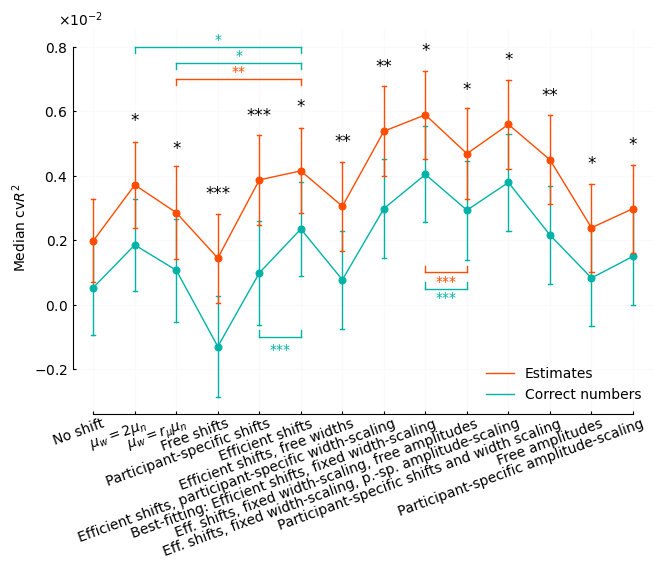

In [425]:
#fig, axs = plt.subplots(nrows=2, figsize=(7.5, 8), sharex=True, height_ratios=[.6,.4])
fig, ax = plt.subplots(figsize=(7.5, 5))
C_GT = plt.cm.winter(.7)
C_EST = plt.cm.autumn(.3)
# modelz = dict( [(0, 'No shift'),(1, '$\mu_w = 2 \mu_n$'), (2, '$\mu_w = r_\mu \mu_n$'),
#                                 (3, 'Free shifts'), (5, 'Participant-specific slopes'), (4, 'Efficient shifts'), 
#                                 (14, 'Free widths'), (31, 'Best-fitting: fixed width-scaling'), (15, 'Participant-specific scaling'),
#                                 (32, 'Free amplitudes'), (33, 'Participant-specific amplitude ratio'),
#                                 (34, 'Fixed tuning, free amplitudes'), (35, 'Fixed-tuning, participant-specific amplitude ratio')
#                                 #(18, 'Participant-specific shift and width scaling'),
#                                 ] )
modelz = dict( [(0, 'No shift'),(1, '$\mu_w = 2 \mu_n$'), (2, '$\mu_w = r_\mu \mu_n$'),
                (3, 'Free shifts'),
                (5, 'Participant-specific shifts'),
                (4, 'Efficient shifts'), 
                (14, 'Efficient shifts, free widths'),
                (15, 'Efficient shifts, participant-specific width-scaling'),
                (31, 'Best-fitting: Efficient shifts, fixed width-scaling'),
                (32, 'Eff. shifts, fixed width-scaling, free amplitudes'),
                (33, 'Eff. shifts, fixed width-scaling, p.-sp. amplitude-scaling'),
                (18, 'Participant-specific shifts and width scaling'),
                (34, 'Free amplitudes'),
                (35, 'Participant-specific amplitude-scaling')
                ] )
x_model = {mo:i for i,mo in enumerate(modelz.keys()) } # abscissa positions for the models
these_rez_est = rez_est_median.loc[:,list(modelz.keys())].rename(columns=modelz)
these_rez = rez_median.loc[:,list(modelz.keys())].rename(columns=modelz)
# combine these_rez, these_rez_est, adding an index level
these_rez_combined = pd.concat([these_rez, these_rez_est], axis=1, keys=['gt', 'est'], names=['type'])

#### plot cvr2s
#ax = axs[0]
sns.pointplot(these_rez, errorbar='se', color=C_GT, markersize=5, linewidth=1, ax=ax, capsize=.1)
sns.pointplot(these_rez_est, errorbar='se', color=C_EST, markersize=5, linewidth=1, ax=ax, capsize=.1)
ax.set_xlabel(None)
handles = [plt.Line2D([0], [0], color=C_EST, lw=1, label='Estimates'),
           plt.Line2D([0], [0], color=C_GT, lw=1, label='Correct numbers')]
ax.legend(handles=handles, loc='lower right')
# ax.set_yticks([.22, .24, .26, .28, .3, .32, .34])
# ax.set_yticklabels(['.22', '.24', '.26', '.28', '.30', '.32', '.34'])
ax.set_ylabel('Median cv$R^2$', y=.6, ha='right')
#
ax.spines.left.set_bounds((-0.002, 0.008))
ax.spines.bottom.set_bounds((0, len(modelz)-1))
sns.despine(fig)
#
for i,k in enumerate( modelz.keys()):
    r = compare_gt_vs_est_median.loc[k]
    if r['p-val'] < 0.05:
        stars = '***' if r['p-val'] < 0.001 else '**' if r['p-val'] < 0.01 else '*'
        x = i #+ 0.1
        y = r['Mean est'] + .002
        ax.text(x, y, stars, ha='center', va='center', fontsize=12)
ax.set_xlim(-.5,len(modelz)-.5)
#ax.set_title('Models fits')
#ax.set_ylim(None, .38)

# tests 1-4, 2-5
r = pg.ttest(x=rez_est_median[1], y=rez_est_median[4], paired=True, ).iloc[0] # alternative='less'
print(rez_est_median[4].mean() - rez_est_median[1].mean())
print(f"1,4 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
r = pg.ttest(x=rez_est_median[2], y=rez_est_median[5], paired=True, ).iloc[0] # alternative='less'
print(f"2,5 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
#star_line(ax, 2, 5, .345, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=.002)
r = pg.ttest(x=rez_median[1], y=rez_median[4], paired=True, ).iloc[0] # alternative='less'
print(f"1,4  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
star_line(ax, x_model[1], x_model[4], .008, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=.0002)
r = pg.ttest(x=rez_median[2], y=rez_median[5], paired=True, ).iloc[0] # alternative='less'
print(f"2,5  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")

# test 4-5
print('##')
r = pg.ttest(x=rez_est_median[4], y=rez_est_median[5], paired=True, ).iloc[0]
print(f"4,5 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
#star_line(ax, x_model[4], x_model[5], .007, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=-.002, star_offset=-.007)
r = pg.ttest(x=rez_median[4], y=rez_median[5], paired=True, ).iloc[0]
print(f"4,5  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
star_line(ax, x_model[4], x_model[5], -.001, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=-.0002, star_offset=-.0006)

# print('##')
# r = pg.ttest(x=rez_est[1], y=rez_est[2], paired=True, ).iloc[0]
# print(f"1,2 est $t({r.dof})={r['T']:.2f}$, $P={r['p-val']:.2g}$")
# star_line(ax, 1, 2, .345, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=.002)
# r = pg.ttest(x=rez[1], y=rez[2], paired=True, ).iloc[0]
# print(f"1,2  gt $t({r.dof})={r['T']:.2f}$, $P={r['p-val']:.2g}$")
# star_line(ax, 1, 2, .355, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=.002)

print('##')
r = pg.ttest(x=rez_est_median[2], y=rez_est_median[4], paired=True, ).iloc[0]
print(f"2,4 est $t({r.dof})={r['T']:.2f}$, $P={r['p-val']:.2g}$")
star_line(ax, x_model[2], x_model[4], .007, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=.0002)
r = pg.ttest(x=rez_median[2], y=rez_median[4], paired=True, ).iloc[0]
print(f"2,4  gt $t({r.dof})={r['T']:.2f}$, $P={r['p-val']:.2g}$")
star_line(ax, x_model[2], x_model[4], .0075, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=.0002)

print('##')
# tests 33, 32 vs 31
r = pg.ttest(x=rez_est_median[32], y=rez_est_median[31], paired=True,).iloc[0] # alternative='less'),
print(f"32,31 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
star_line(ax,  x_model[32], x_model[31], .001, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=-.0002, star_offset=-.0005)
r = pg.ttest(x=rez_est_median[33], y=rez_est_median[31], paired=True,).iloc[0] # alternative='less'),
print(f"33,31 est $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
#star_line(ax, 10, 7, .0005, r['p-val'], star_color=C_EST, line_color=C_EST, vertical_lines_length=-.0002, star_offset=-.0008)
r = pg.ttest(x=rez_median[32], y=rez_median[31], paired=True,).iloc[0] # alternative='less'),
print(f"32,31  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
star_line(ax,  x_model[32], x_model[31], .0005, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=-.0002, star_offset=-.0005)
r = pg.ttest(x=rez_median[33], y=rez_median[31], paired=True,).iloc[0] # alternative='less'),
print(f"33,31  gt $P={r['p-val']:.2g}$, $t({r.dof})={r['T']:.2f}$")
#star_line(ax, 10, 7, -.0005, r['p-val'], star_color=C_GT, line_color=C_GT, vertical_lines_length=-.0002, star_offset=-.0008)

ax.grid(c='#FaFaFa', zorder=-10000)

ax.ticklabel_format( axis='y', style='sci', scilimits=(-2, -2), useMathText=True )
#ax.yaxis.get_offset_text().set_fontsize(8)
ax.yaxis.get_offset_text().set_x(-.025)


####### models' characteristics
if False:
    ax = axs[1]
    chars = ['$\mu_w = \mu_n$', '$\mu_w = 2 \mu_n$', '$\mu_w = r_\mu \mu_n$', 'Free $\mu_n$, $\mu_w$', '$\mu_w = 10 + r_\mu(\mu_n - 10)$', '$\mu_w = 10 + 2(\mu_n - 10)$', 
            '$\sigma_w = \sigma_n$', 'Free $\sigma_n$, $\sigma_w$', '$\sigma_w = r_\sigma^* \sigma_n$', '$\sigma_w = r_\sigma \sigma_n$',  
            '$a_w = a_n$', 'Free $a_n$, $a_w$', '$a_w = r_a a_n$',]
    chars_y  = {ch:-i for i,ch in enumerate(chars)}
    mo_chars = {}
    mo_chars[0] = [ '$\mu_w = \mu_n$', '$\sigma_w = \sigma_n$', '$a_w = a_n$']
    mo_chars[1] = [ '$\mu_w = 2 \mu_n$', '$\sigma_w = \sigma_n$', '$a_w = a_n$']
    mo_chars[2] = [ '$\mu_w = r_\mu \mu_n$', '$\sigma_w = \sigma_n$', '$a_w = a_n$']
    mo_chars[3] = [ 'Free $\mu_n$, $\mu_w$', '$\sigma_w = \sigma_n$', '$a_w = a_n$']
    mo_chars[4] = [ '$\mu_w = 10 + 2(\mu_n - 10)$', '$\sigma_w = \sigma_n$', '$a_w = a_n$']
    mo_chars[5] = [ '$\mu_w = 10 + r_\mu(\mu_n - 10)$', '$\sigma_w = \sigma_n$', '$a_w = a_n$']
    mo_chars[14] = [ '$\mu_w = 10 + 2(\mu_n - 10)$', 'Free $\sigma_n$, $\sigma_w$', '$a_w = a_n$']
    mo_chars[15] = [ '$\mu_w = 10 + 2(\mu_n - 10)$', '$\sigma_w = r_\sigma \sigma_n$', '$a_w = a_n$']
    mo_chars[18] = [ '$\mu_w = 10 + r_\mu(\mu_n - 10)$', '$\sigma_w = r_\sigma \sigma_n$', '$a_w = a_n$']
    mo_chars[31] = [ '$\mu_w = 10 + 2(\mu_n - 10)$', '$\sigma_w = r_\sigma^* \sigma_n$', '$a_w = a_n$']
    mo_chars[32] = [ '$\mu_w = 10 + 2(\mu_n - 10)$', '$\sigma_w = r_\sigma^* \sigma_n$', 'Free $a_n$, $a_w$']
    mo_chars[33] = [ '$\mu_w = 10 + 2(\mu_n - 10)$', '$\sigma_w = r_\sigma^* \sigma_n$', '$a_w = r_a a_n$']
    mo_chars[34] = [ '$\mu_w = \mu_n$', '$\sigma_w = \sigma_n$', 'Free $a_n$, $a_w$']
    mo_chars[35] = [ '$\mu_w = \mu_n$', '$\sigma_w = \sigma_n$', '$a_w = r_a a_n$']

    for mo in modelz.keys():
        x_mo = x_model[mo]
        if mo not in mo_chars:
            print(f'Model {mo} has no characteristics defined')
            continue
        for ch in mo_chars[mo]:
            y_ch = chars_y[ch]
            ax.scatter(x_mo, y_ch, color='black', zorder=1000, s=10) #, marker='x')

    ax.set_yticks(list(chars_y.values()))
    ax.set_yticklabels(chars_y.keys());

    ax.axhline(-5.5, color='C6', lw=.5, ls=':')
    ax.axhline(-9.5, color='C6', lw=.5, ls=':')
    ax.axvline( 5.5, color='C6', lw=.5, ls=':')
    # ylm = ax.get_ylim()
    # ax.plot([5.5, 5.5], [.6,-9.5], color='C6', lw=.5, ls=':')
    # ax.plot([8.5, 8.5], [-9.5, -12.5], color='C6', lw=.5, ls=':')
    # ax.set_ylim(ylm)
    ax.axvline(10.5, color='C6', lw=.5, ls=':')

    ax.grid(zorder=-1000, c='#F5F5F5', lw=.5);

#### x ticks labels positions
ax.tick_params(axis='both', tickdir='in', length=2)
ax.set_xticks(range(len(modelz)))
#ax.set_xticklabels(relabel_modelz.values())
plt.setp(ax.get_xticklabels(), rotation=20, ha='right', va='top', rotation_mode="anchor");
# Create offset transform
dx = 6./72.; dy = 2/72. 
offset = ScaledTranslation(dx, dy, fig.dpi_scale_trans)
# apply offset transform to all x ticklabels.
for label in ax.xaxis.get_majorticklabels(): label.set_transform(label.get_transform() + offset)
#

fig.subplots_adjust(hspace=.05)

#fig.savefig('figures/models_fits_mediancvr2.pdf', bbox_inches='tight')

# Model 3 - Free mus

In [ ]:
# df3 = index_filter(pars, type='estimates', smoothed=True, model_label=3, )  
# df3 = df3[ df3[('cvr2', 'nan')] > 0] #.drop(columns='alpha')
# df3.index.rename(['subject', 'voxel'], inplace=True)
df3 = index_filter(pars, response_fit=True, model_label=3, )
df3 = df3[ df3.cvr2 > 0] #.drop(columns='alpha')
# df3[('mu', 'delta_wn')] = df3[('mu', 'wide')] - df3[('mu', 'narrow')]
df3['mu_delta_wn'] = df3.mu_wide - df3.mu_narrow
df3

loglikelihood      cvr2          aic          bic  mu_narrow    mu_wide  sd_narrow   sd_wide  delta_wide_narrow  delta_wide_wide  amplitude_narrow  \
subject voxel                                                                                                                                                       
1       10       -677.201419  0.002170  1368.402839  1397.619342  11.646183  16.414830   0.640069  0.640069           3.360705         3.360705          0.932299   
        19       -473.480295  0.000912   960.960589   990.177092  11.699677  12.154384   0.298934  0.298934           0.430426         0.430426          0.366663   
        20       -610.865530  0.007719  1235.731060  1264.947563  12.507132  13.631181   0.314262  0.314262          -0.776955        -0.776955          0.500344   
        21       -377.025342  0.016012   768.050684   797.267187  11.739922  12.658052   0.323154  0.323154          -0.099157        -0.099157          0.339501   
        22       -464.387007  0.028518   942.774015   971.990518  12.506612  13.647224   0.303706  0.303706          -1.198131        -1.198131          0.433534   
...                      ...       ...          ...          ...        ...        ...        ...       ...                ...              ...               ...   
41      683      -108.747367  0.006951   231.494735   260.711237  12.313602  17.939056   0.597588  0.597588           3.066650         3.066650          0.325162   
        684      -221.511331  0.017459   457.022663   486.239166  15.968842  20.634487   0.141029  0.141029           1.843896         1.843896          0.254356   
        686      -439.890599  0.003730   893.781197   922.997700  11.896980  11.783724   0.284192  0.284192           0.860540         0.860540          0.308699   
        687      -427.382900  0.008037   868.765800   897.982302  12.097210  11.868726   0.275779  0.275779           0.708703         0.708703          0.322676   
        689      -282.312403  0.004068   578.624806   607.841309  11.006373  16.906227   1.139575  1.139575           3.631219         3.631219          0.953917   

               amplitude_wide  baseline_narrow  baseline_wide        r2  mu_delta_wn  
subject voxel                                                                         
1       10           0.932299        -1.058889      -1.058889  0.022221     4.768647  
        19           0.366663        -0.324689      -0.324689  0.027029     0.454707  
        20           0.500344        -0.590443      -0.590443  0.029939     1.124049  
        21           0.339501        -0.182824      -0.182824  0.034865     0.918130  
        22           0.433534        -0.417246      -0.417246  0.041086     1.140612  
...                       ...              ...            ...       ...          ...  
41      683          0.325162        -0.010526      -0.010526  0.036368     5.625454  
        684          0.254356         0.155281       0.155281  0.041298     4.665645  
        686          0.308699        -0.232461      -0.232461  0.027282    -0.113256  
        687          0.322676        -0.061422      -0.061422  0.031247    -0.228484  
        689          0.953917        -0.511845      -0.511845  0.027683     5.899854  

[8131 rows x 16 columns]

In [464]:
# df3_gt = index_filter(pars, type='ground_truth', smoothed=True, model_label=3, ) 
# df3_gt = df3_gt[ df3_gt[('cvr2', 'nan')] > 0] #.drop(columns='alpha')
# df3_gt.index.rename(['subject', 'voxel'], inplace=True)
# df3_gt[('mu', 'delta_wn')] = df3_gt[('mu', 'wide')] - df3_gt[('mu', 'narrow')]
df3_gt = index_filter(pars, response_fit=False, model_label=3, )
df3_gt = df3_gt[ df3_gt.cvr2 > 0] 
df3_gt['mu_delta_wn'] = df3_gt.mu_wide - df3_gt.mu_narrow
df3_gt

loglikelihood      cvr2          aic          bic  mu_narrow    mu_wide  sd_narrow   sd_wide  delta_wide_narrow  delta_wide_wide  amplitude_narrow  \
subject voxel                                                                                                                                                       
1       16       -543.150389  0.006654  1100.300778  1129.517281  11.953689  11.970137   0.141939  0.141939           0.539351         0.539351          0.491276   
        17       -563.888462  0.000619  1141.776925  1170.993427  11.811804  12.694811   0.135494  0.135494           1.304827         1.304827          0.573474   
        19       -469.965924  0.014735   953.931847   983.148350  11.668624  12.151473   0.113303  0.113303           1.201622         1.201622          0.462347   
        20       -606.758146  0.009499  1227.516291  1256.732794  12.026028  13.326386   0.169726  0.169726           1.411364         1.411364          0.570810   
        21       -377.396163  0.004464   768.792326   798.008829  11.616263  11.897877   0.107611  0.107611           0.422172         0.422172          0.347648   
...                      ...       ...          ...          ...        ...        ...        ...       ...                ...              ...               ...   
41      684      -224.554208  0.012689   463.108416   492.324919  12.167647  16.722458   1.175210  1.175210           3.029041         3.029041          0.996748   
        688      -277.328570  0.005810   568.657139   597.873642  11.588984  17.674347   1.409025  1.409025           3.225628         3.225628          1.224181   
        689      -283.064011  0.011833   580.128022   609.344524   8.280071  12.495578   1.832362  1.832362          -0.393533        -0.393533          1.289015   
        691      -294.054883  0.014391   602.109766   631.326269   9.055554  13.853920   1.751025  1.751025          -0.623786        -0.623786          1.445718   
        693      -370.066462  0.004493   754.132923   783.349426   9.668491  14.695103   1.655109  1.655109          -0.707371        -0.707371          1.193858   

               amplitude_wide  baseline_narrow  baseline_wide        r2  mu_delta_wn  
subject voxel                                                                         
1       16           0.491276        -0.291168      -0.291168  0.040713     0.016448  
        17           0.573474        -0.441848      -0.441848  0.048362     0.883007  
        19           0.462347        -0.286405      -0.286405  0.041172     0.482849  
        20           0.570810        -0.525027      -0.525027  0.046398     1.300358  
        21           0.347648        -0.114130      -0.114130  0.033372     0.281614  
...                       ...              ...            ...       ...          ...  
41      684          0.996748        -0.705511      -0.705511  0.029065     4.554811  
        688          1.224181        -1.061010      -1.061010  0.016533     6.085363  
        689          1.289015        -0.856375      -0.856375  0.024634     4.215507  
        691          1.445718        -1.117993      -1.117993  0.025819     4.798366  
        693          1.193858        -1.041921      -1.041921  0.012889     5.026612  

[7330 rows x 16 columns]

In [467]:
for meth in ['pearson', 'spearman', ]:
    print(pg.corr( df3.mu_narrow, df3.mu_wide, method=meth))
#
for meth in ['pearson', 'spearman', ]:
    print(pg.corr( df3_gt.mu_narrow, df3_gt.mu_wide, method=meth))

# was:
#             n         r         CI95%  p-val BF10  power
# pearson  8008  0.668998  [0.66, 0.68]    0.0  inf    1.0
#              n         r         CI95%  p-val  power
# spearman  8008  0.767203  [0.76, 0.78]    0.0    1.0

            n         r         CI95%  p-val BF10  power
pearson  8131  0.654089  [0.64, 0.67]    0.0  inf    1.0
             n         r         CI95%  p-val  power
spearman  8131  0.765371  [0.76, 0.77]    0.0    1.0
            n         r         CI95%  p-val BF10  power
pearson  7330  0.655864  [0.64, 0.67]    0.0  inf    1.0
             n         r         CI95%  p-val  power
spearman  7330  0.736863  [0.73, 0.75]    0.0    1.0


In [582]:
#meth = 'pearson'
meth = 'spearman'
print( pg.corr( df3.mu_narrow, df3.mu_wide, method=meth ) )
subject_corrs = df3.groupby(level='subject').apply(lambda g: pg.corr(g.mu_narrow, g.mu_wide, method=meth))
subject_corrs.describe()

             n         r         CI95%  p-val  power
spearman  8131  0.765371  [0.76, 0.77]    0.0    1.0


,n,r,p-val,power
count,39.000000,39.000000,3.900000e+01,39.000000
mean,208.487179,0.657946,2.528624e-05,0.996345
std,141.568074,0.167399,1.014219e-04,0.012899
min,37.000000,0.268862,5.812806e-117,0.940374
25%,91.000000,0.566458,2.915007e-39,0.999991
50%,160.000000,0.688341,6.521792e-21,1.000000
75%,294.000000,0.792552,4.047984e-09,1.000000
max,521.000000,0.967255,4.796752e-04,1.000000


In [583]:
print( subject_corrs['r'].min() )
subject_corrs['r'].describe(percentiles=[.25,.75])

0.2688616995698983


count    39.000000
mean      0.657946
std       0.167399
min       0.268862
25%       0.566458
50%       0.688341
75%       0.792552
max       0.967255
Name: r, dtype: float64

In [584]:
( subject_corrs['p-val'] < 0.001 ).mean()

1.0

In [585]:
pg.multicomp(subject_corrs['p-val'])[1].max()

0.0008551730616147633

In [586]:
df3[df3.mu_narrow>=10].mu_delta_wn.groupby('subject').mean().mean()

2.8915804081376555

In [590]:
ttres = pg.ttest( df3[df3.mu_narrow>=10].mu_delta_wn.groupby('subject').mean(), y=0 )
print(ttres['p-val'].iloc[0])
ttres

8.803458870166777e-06


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,5.131304,38,two-sided,0.000009,"[1.75, 4.03]",0.821666,2271.154,0.998809


37 subjects have median $\mu$ in Wide condition larger than in Narrow condition
2 subjects have median $\mu$ in Wide condition smaller than in Narrow condition
Paired t-test: t = -8.814, p = 1.01e-10, dof = 38


/var/folders/jq/_79_qpxx3vd0thkqqmw37l1c0000gn/T/ipykernel_28410/3658480485.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Paired t-test: t = {paired_test['T'][0]:.3f}, p = {paired_test['p-val'][0]:.3g}, dof = {paired_test['dof'][0]}")


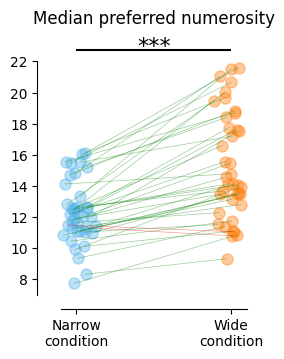

In [592]:
# Compute per-subject medians for 'mu' in 'wide' and 'narrow'
#ind = (df3.mu.narrow>=0) & (df3.mu.wide>=0) #& (df3.mu.narrow<=40) & (df3.mu.wide<=40)
# mu_wide_medians = df3[('mu', 'wide')].groupby('subject').median()
# mu_narrow_medians = df3[('mu', 'narrow')].groupby('subject').median()
mu_wide_medians = df3.mu_wide.groupby('subject').median()
mu_narrow_medians = df3.mu_narrow.groupby('subject').median()
print( (mu_wide_medians >= mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition larger than in Narrow condition' )
print( (mu_wide_medians <  mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition smaller than in Narrow condition' )

fig, ax = plt.subplots(figsize=(3, 3.6))
paired_strip_plot(ax, x1=1, x2=2, y1=mu_narrow_medians, y2=mu_wide_medians, 
                  col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE], color_incr_line='g', color_decr_line='r',)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
ax.set_title("Median preferred numerosity")
ax.set_xlim(0.75, 2.25)
ax.set_ylim(6.1,23.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# paired test
paired_test = pg.ttest(mu_narrow_medians, mu_wide_medians, paired=True)
print(f"Paired t-test: t = {paired_test['T'][0]:.3f}, p = {paired_test['p-val'][0]:.3g}, dof = {paired_test['dof'][0]}")
# add a horizontal line above the two clouds of dots, with tree stars, reflecting the p-value
ax.hlines(0.95*ax.get_ylim()[1], 1, 2, color='k', lw=1.5)
ax.text(1.5, 0.96*ax.get_ylim()[1], '***', ha='center', va='center', fontsize=16, color='k')

ax.spines.left.set_bounds((7, 22))
ax.spines.bottom.set_bounds((.9, 2.1))

#fig.savefig('figures/delta_median_mu.pdf', bbox_inches='tight')

In [593]:
paired_test['p-val']

T-test    1.009408e-10
Name: p-val, dtype: float64

In [594]:
df3.index.get_level_values('subject').unique()

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41], dtype='int64', name='subject')

15.803714180297627 % of voxels have $\mu_{w} - \mu_{n} < 0$


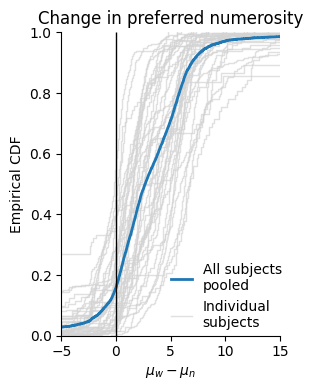

In [595]:
fig, ax = plt.subplots(figsize=(3, 4))
all_data = []
#ind = (df3.mu.narrow>=10) & (df3.mu.wide>=10) #& (df3.mu.narrow<=40) & (df3.mu.wide<=40)
subjects = df3.index.get_level_values('subject').unique()
for subject in subjects:
    data = df3.xs(subject, level='subject').mu_delta_wn #[('mu', 'delta_wn')]
    all_data.append(pd.DataFrame({'mu_delta_wn': data.dropna(), 'subject': subject}))
all_data = pd.concat(all_data, ignore_index=True)
# Plot the CDFs for each subject in light grey (no hue, loop over subjects)
c_ind = 'lightgrey'
for subject in subjects:
    subj_data = all_data[all_data['subject'] == subject]
    sns.ecdfplot(data=subj_data, x='mu_delta_wn', color=c_ind, linewidth=1, alpha=0.7, legend=False)

# Plot the pooled CDF (all subjects together) in a bold color
sns.ecdfplot(data=all_data, x='mu_delta_wn', color='C0', linewidth=2, label='All subjects pooled')
print( (all_data.mu_delta_wn<0).mean() * 100, '% of voxels have $\mu_{w} - \mu_{n} < 0$' )

#plt.title("Empirical CDF of $\mu_{w} - \mu_{n}$")
plt.gca().set_title("Change in preferred numerosity")
plt.xlabel('$\mu_{w} - \mu_{n}$')
plt.ylabel('Empirical CDF')
plt.legend(handles=[plt.Line2D([0], [0], color='C0', lw=2, label='All subjects\npooled'),
                    plt.Line2D([0], [0], color=c_ind, alpha=.7, lw=1, label='Individual\nsubjects')], loc=(.475,0), handlelength=1.5)
plt.tight_layout()
plt.xlim(-5, 15)
plt.vlines(0, 0, 1, color='black', linestyle='-', lw=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# fig.savefig('figures/cdf_delta_mu.pdf', bbox_inches='tight')

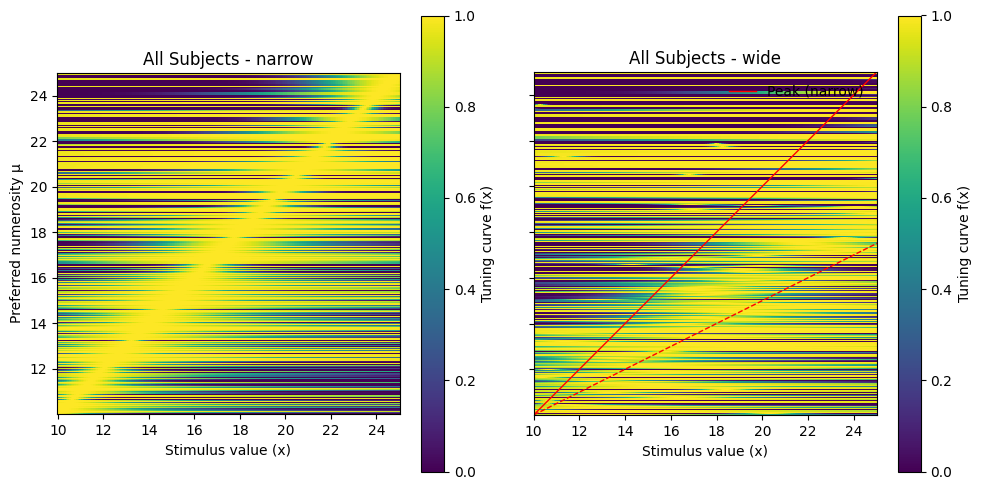

In [596]:
# Filter: only voxels with 10 <= mu (narrow) <= 25
mu_narrow_all = df3.mu_narrow #[('mu', 'narrow')]
mask = (mu_narrow_all >= 10) & (mu_narrow_all <= 25)
filtered_voxel_indices = mu_narrow_all[mask].sort_values().index          

x_vals   = np.linspace(10, 25, 200)
dx = x_vals[1] - x_vals[0]
x_edges  = np.linspace(x_vals[0]-dx/2, x_vals[-1]+dx/2, len(x_vals)+1)

# NEW  y-edges so vertical position depends only on μ, not voxel count
mu_sorted = df3.loc[filtered_voxel_indices].mu_narrow.values #[('mu', 'narrow')].values
y_edges   = np.concatenate(([mu_sorted[0] - (mu_sorted[1]-mu_sorted[0])/2],
                            (mu_sorted[:-1] + mu_sorted[1:]) / 2,
                            [mu_sorted[-1] + (mu_sorted[-1]-mu_sorted[-2])/2]))

conditions = ['narrow', 'wide']
fig, axes = plt.subplots(1, 2, figsize=(10, 5 ), sharey=True)

for ax in axes: 
    ax.set_aspect('equal', adjustable='box') 

peak_locs = []

for i, cond in enumerate(conditions):
    ax = axes[i]
    img = []
    for idx in filtered_voxel_indices:
        #baseline  = df3.loc[idx][('baseline',  cond)]
        #amplitude = df3.loc[idx][('amplitude', cond)]
        #mu        = df3.loc[idx][('mu',       cond)]
        mu        = df3.loc[idx][f'mu_{cond}']
        #sd        = df3.loc[idx][('sd',       cond)]
        sd        = df3.loc[idx][f'sd_{cond}']
        #fx = np.exp(-.5*((x_vals - mu) / sd) ** 2)
        fx = np.exp(-.5*((np.log(x_vals) - np.log(mu) ) / sd) ** 2)
        #fx = -.5*((np.log(x_vals) - np.log(mu) ) / sd) ** 2
        #fx = baseline + amplitude * np.exp(-.5*((np.log(x_vals) - np.log(mu) ) / sd) ** 2)
        img.append(fx)
        if i == 0:
            peak_locs.append(mu)
    img = np.array(img)

    # CHANGED ↓  imshow → pcolormesh with the pre-computed edges
    im = ax.pcolormesh(x_edges, y_edges, img, shading='auto', cmap='viridis')

    ax.set_title(f'All Subjects - {cond}')
    ax.set_xlabel('Stimulus value (x)')
    if i == 0:
        ax.set_ylabel('Preferred numerosity μ')
    fig.colorbar(im, ax=ax, label='Tuning curve f(x)')

    if i == 1:
        # CHANGED ↓  use μ values instead of row indices
        ax.plot(peak_locs, mu_sorted, 'r-',  linewidth=1, label='Peak (narrow)')
        ax.plot(10 + 2*(np.array(peak_locs) - 10), mu_sorted, 'r--', linewidth=1)
        ax.legend(loc='upper right')
        ax.set_xlim(x_vals[0], x_vals[-1])

    # # NEW  flip so small μ at top
    # ax.invert_yaxis()                                               

plt.tight_layout()
plt.show()


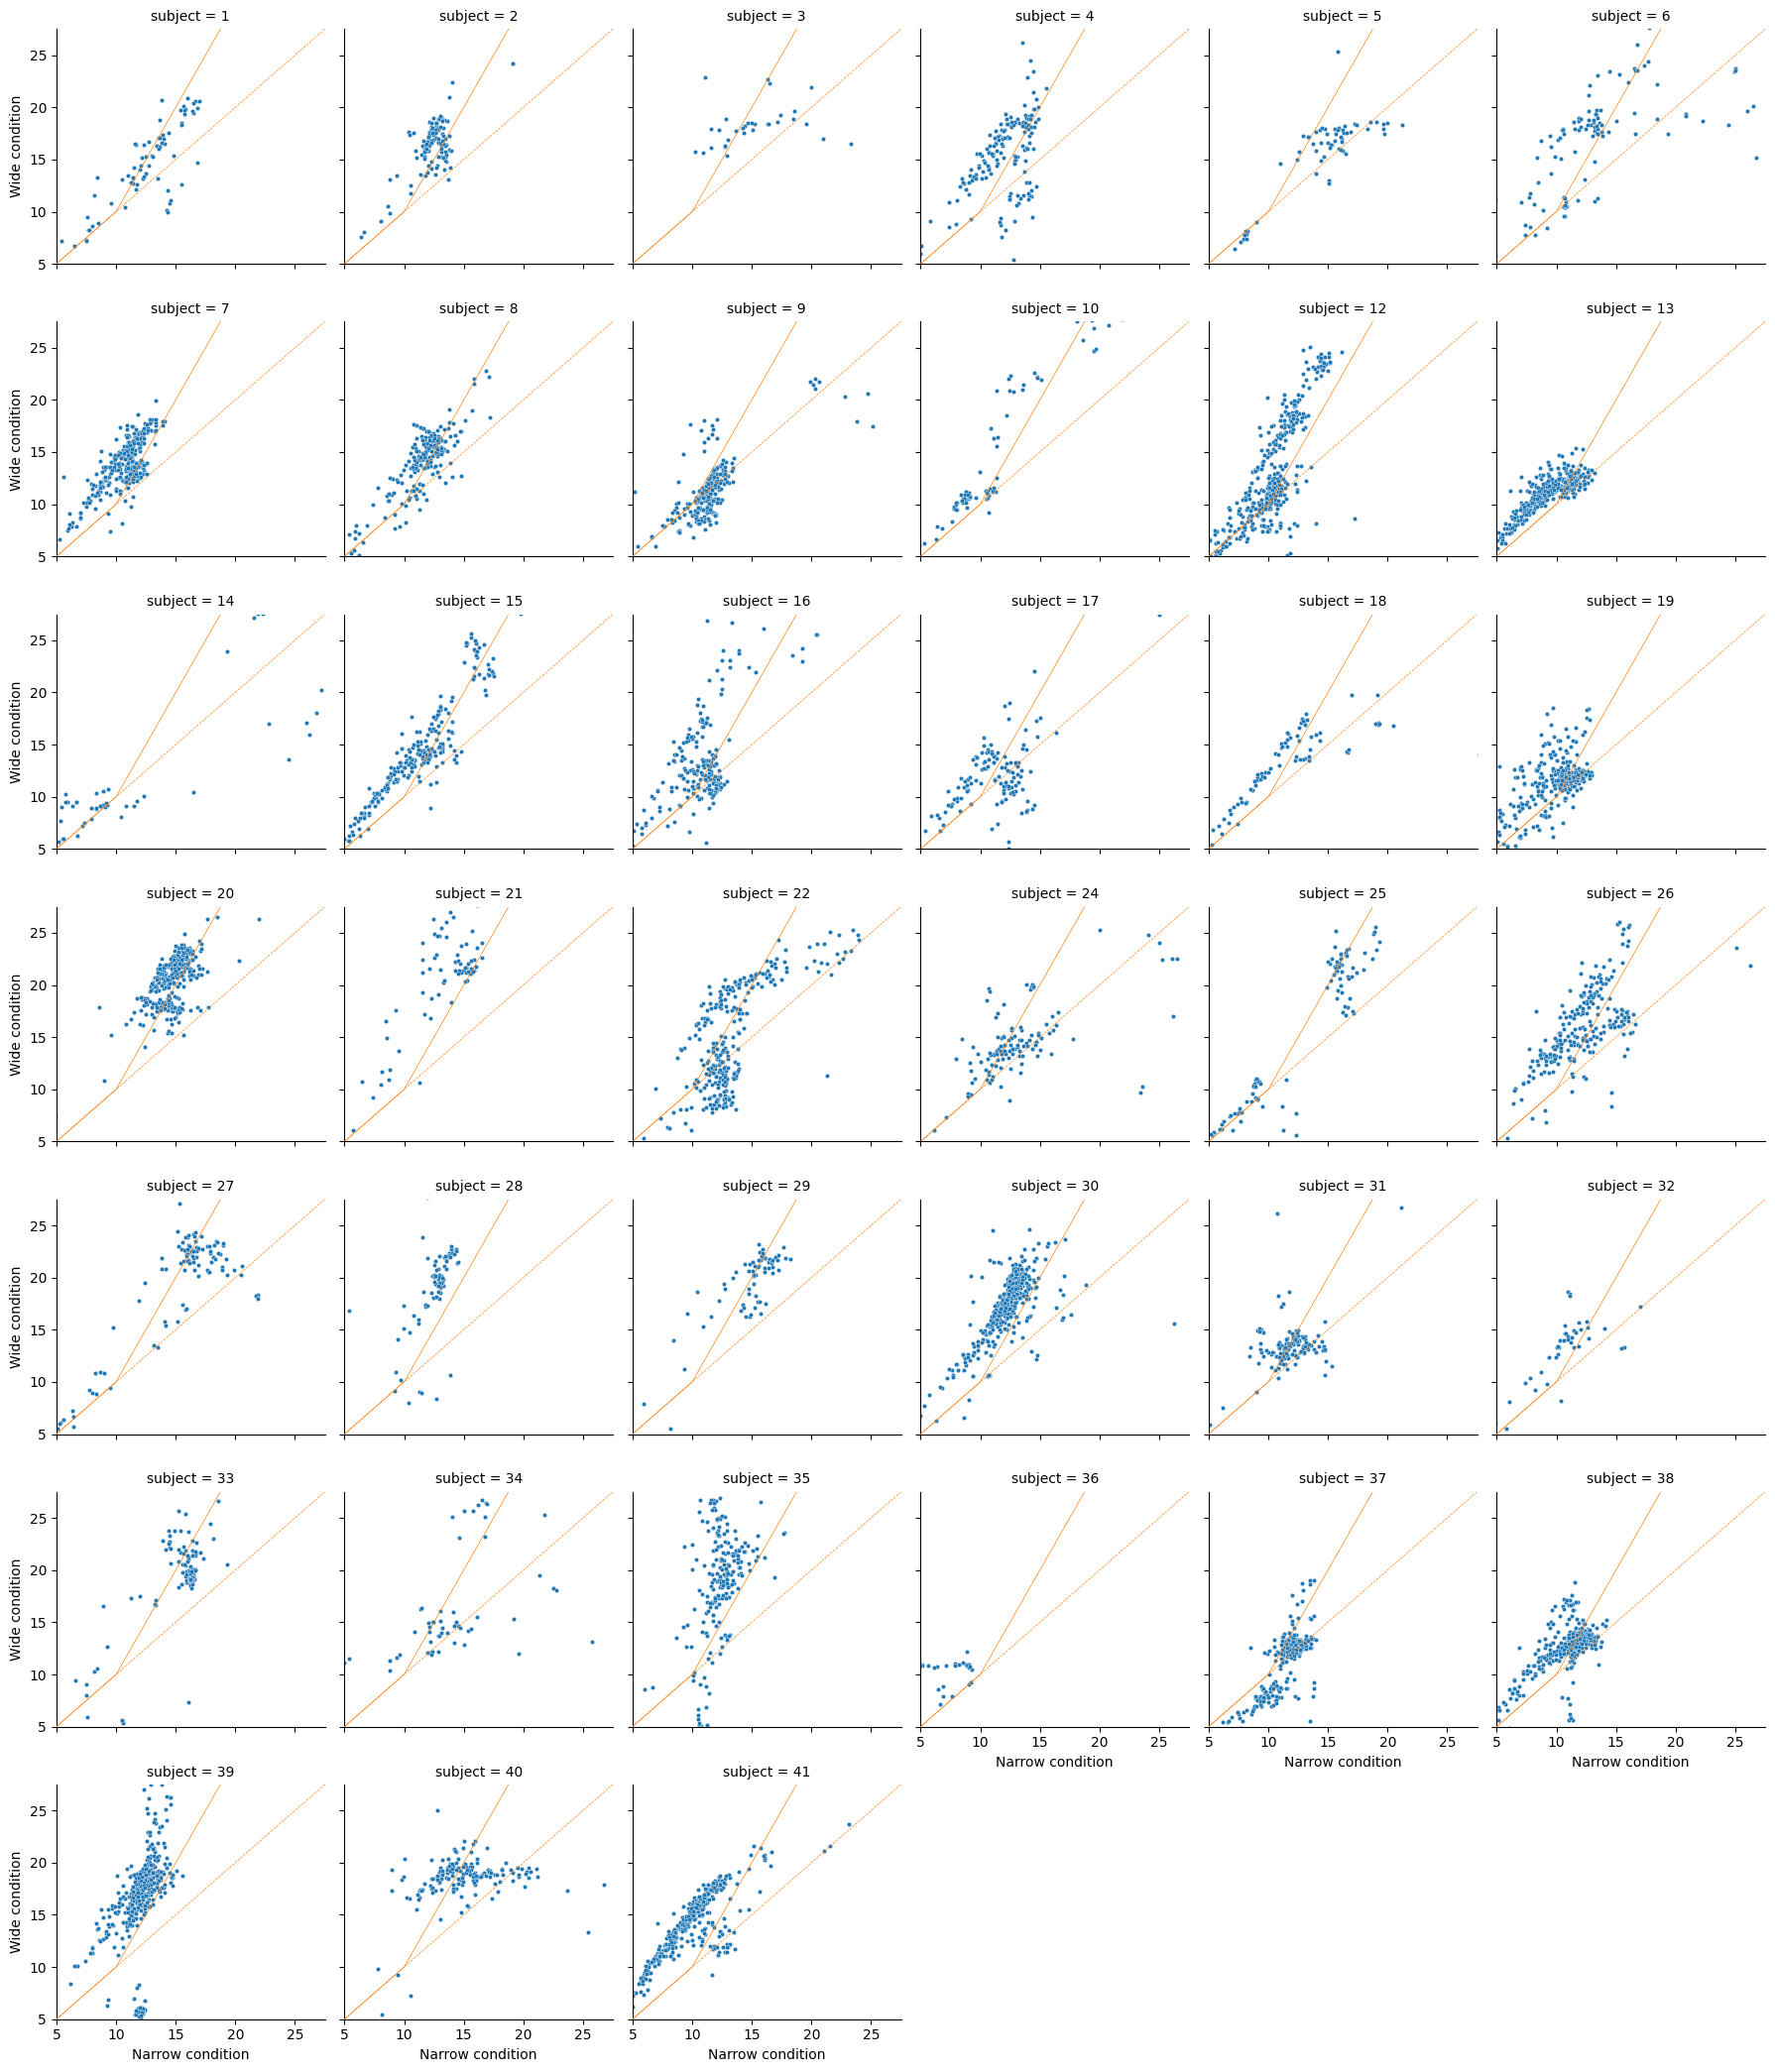

In [480]:
df_plt = df3.reset_index()
g = sns.FacetGrid(df_plt, col="subject", col_wrap=6, height=3, sharex=True, sharey=True)
g.map_dataframe(sns.scatterplot,
                #x=('mu', 'narrow'), y=('mu', 'wide'),
                x='mu_narrow', y='mu_wide',
                color='C0', s=10, alpha=1,) # edgecolor=None)
g.set_axis_labels("Narrow condition", "Wide condition")
g.set(xlim=(5,27.5), ylim=(5,27.5))
for ax in g.axes.flatten():
    ax.axline((0,0), slope=1, color='C1', ls='--', lw=.5, zorder=100)
    ax.plot([0, 10, 40], [0, 10, 70], c='C1', lw=.5, zorder=100)
plt.tight_layout()
plt.show()

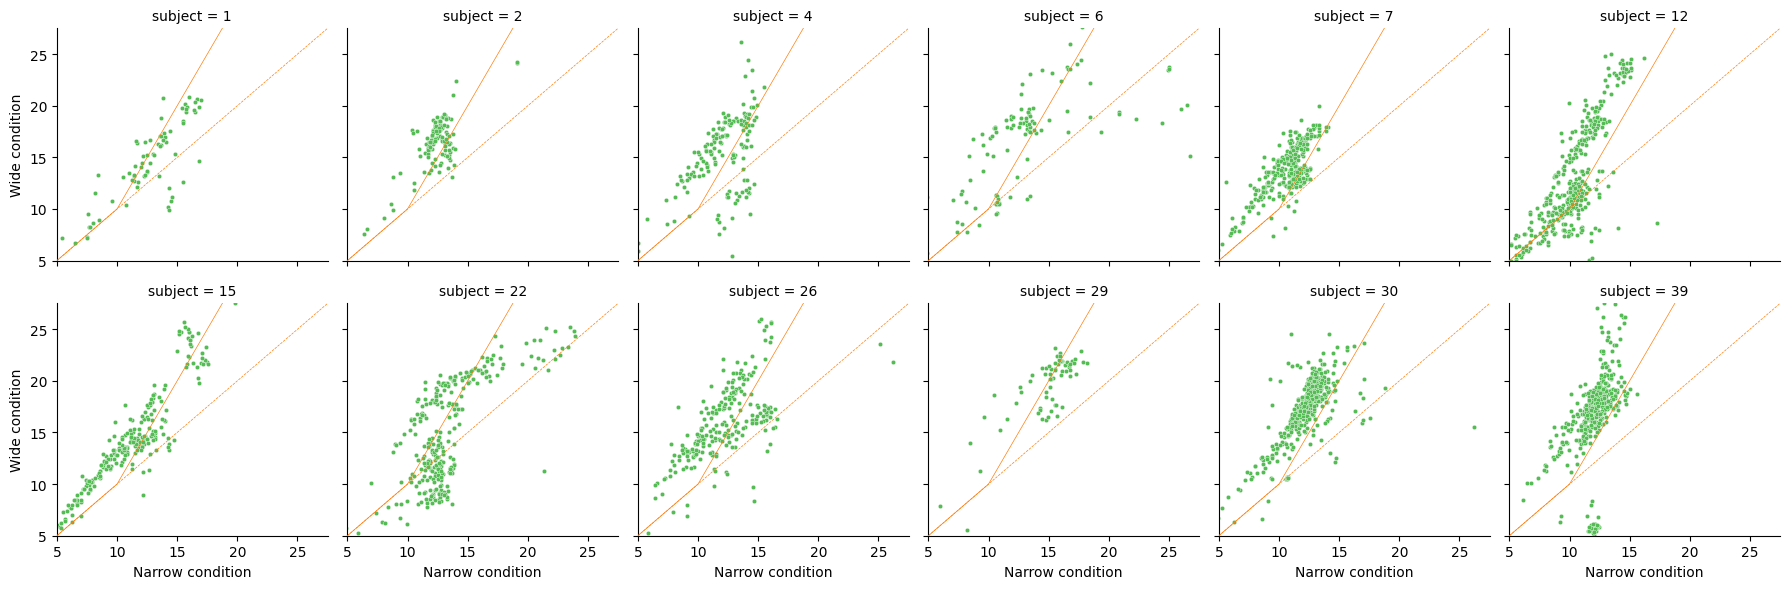

In [481]:
df_plt = index_filter(df3, subject=[1,2,4,6,7,12,15,22,26,29,30,39]).reset_index()
g = sns.FacetGrid(df_plt, col="subject", col_wrap=6, height=3, sharex=True, sharey=True)
g.map_dataframe(sns.scatterplot,
                #x=('mu', 'narrow'), y=('mu', 'wide'),
                x='mu_narrow', y='mu_wide',
                color=THIRD_COLOR, s=10, alpha=1,) # edgecolor=None)
g.set_axis_labels("Narrow condition", "Wide condition")
g.set(xlim=(5,27.5), ylim=(5,27.5))
for ax in g.axes.flatten():
    ax.axline((0,0), slope=1, color='C1', ls='--', lw=.5, zorder=100)
    ax.plot([0, 10, 40], [0, 10, 70], c='C1', lw=.5, zorder=100)
plt.tight_layout()
plt.show()

(0.0, 25.0)

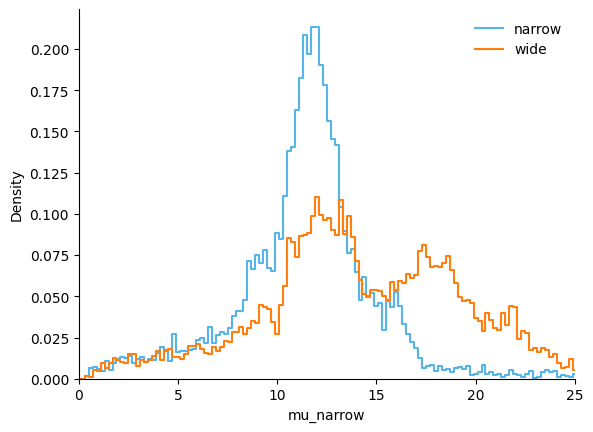

In [483]:
dx = 0.2
bins = np.arange(-dx/2, 25+dx/2+.000001, dx)
sns.histplot(df3.mu_narrow, element='step', fill=False, color=COLORS_COND[NARROW], stat='density', label=NARROW, binrange=(0, 25), bins=bins)
sns.histplot(df3.mu_wide  , element='step', fill=False, color=COLORS_COND[WIDE],   stat='density', label=WIDE,   binrange=(0, 25), bins=bins)
plt.legend()
sns.despine()
plt.xlim(0, 25)

(10.0, 25.0)

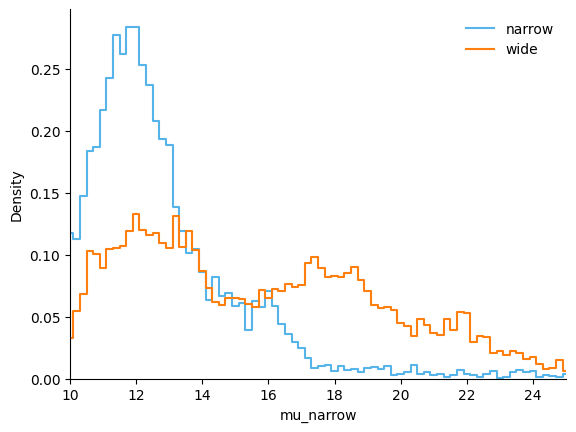

In [484]:
dx = 0.2
bins = np.arange(10-dx/2, 25+dx/2+.000001, dx)
sns.histplot(df3.mu_narrow, element='step', fill=False, color=COLORS_COND[NARROW], stat='density', label=NARROW, binrange=(10, 25), bins=bins)
sns.histplot(df3.mu_wide  , element='step', fill=False, color=COLORS_COND[WIDE],   stat='density', label=WIDE,   binrange=(10, 25), bins=bins)
plt.legend()
sns.despine()
plt.xlim(10, 25)

# Model 5 - subject-wise delta_wide

In [602]:
# dfe5 = index_filter(pars, type='estimates', smoothed=True, model_label=5, ) 
# dfgt5 = index_filter(pars, type='ground_truth', smoothed=True, model_label=5, ) 
# dfe5  = dfe5[  dfe5[ ('cvr2', 'nan')] > 0] #.drop(columns='alpha')
# dfgt5 = dfgt5[ dfgt5[('cvr2', 'nan')] > 0] #.drop(columns='alpha')
dfe5 = index_filter(pars, response_fit=True, model_label=5, )
dfe5 = dfe5[ dfe5.cvr2 > 0]
dfgt5 = index_filter(pars, response_fit=False, model_label=5, )
dfgt5 = dfgt5[ dfgt5.cvr2 > 0]

0.15619743 5.9677258 2.253248442820512 1.964078 0.18627692471764382
12
[0.         0.57142857 1.14285714 1.71428571 2.28571429 2.85714286 3.42857143 4.         4.57142857 5.14285714 5.71428571 6.28571429]
[0.28571429 0.85714286 1.42857143 2.         2.57142857 3.14285714 3.71428571 4.28571429 4.85714286 5.42857143 6.        ]


Text(1.914078, 2, 'median')

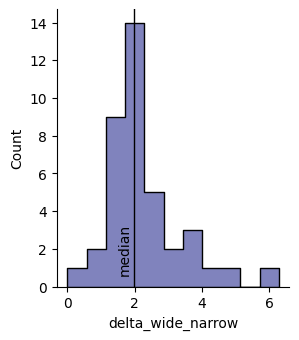

In [603]:
fig, ax = plt.subplots(figsize=(3, 3.6))
ratio_mu = dfe5.delta_wide_narrow.groupby('subject').first()
print(ratio_mu.min(), ratio_mu.max(), ratio_mu.mean(), ratio_mu.median(), ratio_mu.sem())
# nb_bins = 13
# dw = (ratio_mu.max() - ratio_mu.min()) / nb_bins
# bins = np.arange(2-dw/2-((2-ratio_mu.min()+.25)//dw)*dw, 6.+dw, dw)
#dw = .5
nb_bins_02 = 3
dw = 2 / (nb_bins_02 + 1/2)
#bins = np.arange(-dw/2, 7., dw)
bins = np.arange(0, ratio_mu.max()+dw, dw)
print(len(bins))
print(bins)
print( .5*(bins[:-1] + bins[1:]) )
sns.histplot(ratio_mu, bins=bins, ax=ax, color=plt.cm.Spectral_r(0.02), element='step', ec='k' ) # plt.cm.RdYlBu(0.4)
#sns.ecdfplot(ratio_mu, ax=ax, color='C0', linewidth=2, label='All subjects pooled')
sns.despine(fig)
#ax.axvline(2, color='k', linestyle='-', lw=1)
ax.axvline(ratio_mu.median(), color='k', linestyle='-', lw=1)
ax.text(ratio_mu.median()-.05, 2, 'median', rotation=90, va='center', ha='right')

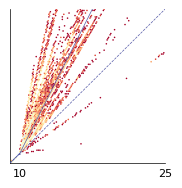

In [487]:
fig, ax = plt.subplots(figsize=(2,2))
this_df = dfe5
nmin_5, nmax_5 = 9, 25
ind = (dfe5.mu_narrow>=nmin_5) & (dfe5.mu_wide>=nmin_5) & (dfe5.mu_narrow<=nmax_5) & (dfe5.mu_wide<=nmax_5)
#sns.histplot(dfe5[ind].mu, x='narrow', y='wide', bins=161, ax=ax, pmax=1, alpha=1, color='grey')
cmap = plt.cm.RdYlBu #summer, YlOrRd_r , ---- 'RdYlBu', 'Spectral', 
ax.hexbin(dfe5[ind].mu_narrow, dfe5[ind].mu_wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0., cmap=cmap, mincnt=1, edgecolors='none', bins='log')
ax.set_xlim(nmin_5,nmax_5); ax.set_ylim(nmin_5,nmax_5)
this_color = plt.cm.Spectral_r(0.02)
ax.axline((0,0), slope=1, color=this_color, ls='--', lw=.5, zorder=100)
ax.plot([0, 10, 40], [0, 10, 70], c=this_color, lw=.5, zorder=100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.set_xlabel(None); ax.set_ylabel(None)
#ax.set_title('Free-slope model', fontsize=8)
ax.set_xticks([10,25]); ax.set_yticks([10,25]); ax.set_yticklabels([None,None]);
ax.tick_params(axis='both', labelsize=8, length=0)

In [488]:
np.arange(2-((2-ratio_mu.min())//dw+.5)*dw, 6.+dw, dw)

array([0.        , 0.57142857, 1.14285714, 1.71428571, 2.28571429, 2.85714286, 3.42857143, 4.        , 4.57142857, 5.14285714, 5.71428571,
       6.28571429])

0.15619743 5.9677258 2.253248442820512 1.964078 0.18627692471764382


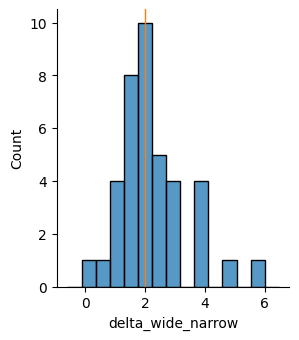

In [489]:
fig, ax = plt.subplots(figsize=(3, 3.6))
ratio_mu = dfe5.delta_wide_narrow.groupby('subject').first()
print(ratio_mu.min(), ratio_mu.max(), ratio_mu.mean(), ratio_mu.median(), ratio_mu.sem() )
dw = .47
sns.histplot(ratio_mu, bins=np.arange(2-(2//dw+1.5)*dw, 6.+dw, dw), ax=ax,)
#sns.ecdfplot(ratio_mu, ax=ax, color='C0', linewidth=2, label='All subjects pooled')
sns.despine(fig)
ax.axvline(2, color='C1', linestyle='-', lw=1)

In [490]:
print(sorted(ratio_mu))

[0.15619743, 0.70350844, 0.8750543, 1.2300447, 1.2550579, 1.2772125, 1.3105263, 1.3152603, 1.4615268, 1.5304906, 1.5347533, 1.6909493, 1.7168945, 1.7318991, 1.7733885, 1.8004893, 1.8084729, 1.926806, 1.9592503, 1.964078, 1.9716936, 2.0470965, 2.1359594, 2.1499162, 2.2576168, 2.268883, 2.3688104, 2.4932153, 2.6186748, 2.7392347, 2.8316061, 3.161634, 3.1662412, 3.9158642, 3.9571798, 3.9969351, 4.1041055, 4.7024364, 5.9677258]


In [604]:
pg.ttest(ratio_mu, y=1)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,6.727878,38,two-sided,5.754501e-08,"[1.88, 2.63]",1.077323,2.475e+05,0.999998


In [492]:
pg.ttest(ratio_mu, y=2)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,1.359527,38,two-sided,0.181993,"[1.88, 2.63]",0.217698,0.404,0.263326


In [605]:
index_filter(compare_res_est, Model2=5)

,Mean Model 1,Mean Model 2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model1,,,,,,,,,,
0,0.280115,0.296499,-2.331584,38,two-sided,2.512463e-02,"[-0.03, -0.0]",0.092669,1.894,0.087194
1,0.298597,0.296499,0.671113,38,two-sided,5.062080e-01,"[-0.0, 0.01]",0.011872,0.213,0.050599
2,0.282952,0.296499,-2.521319,38,two-sided,1.600596e-02,"[-0.02, -0.0]",0.075026,2.761,0.074229
3,0.263062,0.296499,-6.966512,38,two-sided,2.729784e-08,"[-0.04, -0.02]",0.193447,4.994e+05,0.217874
4,0.303130,0.296499,2.196206,38,two-sided,3.425123e-02,"[0.0, 0.01]",0.037558,1.468,0.056012


# Figure - preferred numerosities

In [493]:
from matplotlib import rcParams

In [494]:
from matplotlib.patches import FancyBboxPatch
import matplotlib.transforms as mtransforms

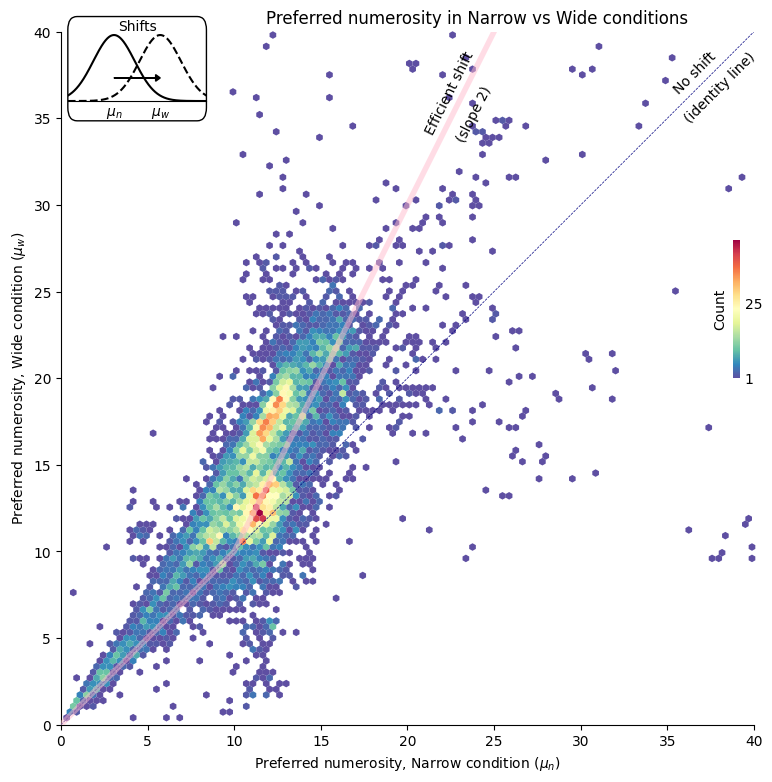

In [495]:
fig, ax = plt.subplots(figsize=(9, 9))
ax.set_aspect('equal') #, adjustable='box')
nmax = 40
ind = (df3.mu_narrow>=0) & (df3.mu_wide>=0) & (df3.mu_narrow<=nmax) & (df3.mu_wide<=nmax)
#sns.histplot(df3[ind].mu, x='narrow', y='wide', bins=161, ax=ax, pmax=.8, alpha=1, cmap='YlGnBu_r', thresh=0) # cmap='YlGnBu_r', 'plasma
#sns.kdeplot(df3[ind].mu, x='narrow', y='wide', ax=ax, levels=6, thresh=.5, fill=True, cmap='YlGnBu')
#ax.hexbin(df3[ind].mu.narrow, df3[ind].mu.wide, gridsize=(50*np.array([np.sqrt(3),1])).astype(int), linewidths=0., cmap='YlGnBu_r', mincnt=1, edgecolors='none')
cmap = plt.cm.Spectral_r # 'RdYlBu_r', 'YlGnBu_r', 'Spectral_r', 
hb = ax.hexbin(df3[ind].mu_narrow, df3[ind].mu_wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0., cmap=cmap, mincnt=1,
          edgecolors='none', clip_on=False)
#sns.regplot(df3[ind].mu, x='narrow', y='wide', ax=ax, scatter=False, lowess=True, color='#FF0000') # ci=None,
cbar_ax = ax.inset_axes([0.97, 0.5, .01, .2])
cb = fig.colorbar(hb, cax=cbar_ax, label='Count', ticks=[1,25,49], drawedges=False)
cb.ax.yaxis.set_label_position('left')
#cb.ax.yaxis.tick_left()
cbar_ax.tick_params(axis='both', length=0)
cb.outline.set_visible(False)

ax.set_xlim(0,nmax); ax.set_ylim(0,nmax)
ax.axline((0,0), slope=1, color='navy', ls='--', lw=.5, zorder=100)
ax.plot([0, 10, 40], [0, 10, 70], c="xkcd:pastel pink", alpha=.5, lw=4, zorder=100)
ax.set_xlabel('Preferred numerosity, Narrow condition ($\mu_n$)')
ax.set_ylabel('Preferred numerosity, Wide condition ($\mu_w$)')
ax.set_title('Preferred numerosity in Narrow vs Wide conditions', x=.6)
ax.text(38, 38+1, 'No shift', fontsize=10, ha='right', va='top', rotation=45)
ax.text(40.25, 38+1, '(identity line)', fontsize=10, ha='right', va='top', rotation=45)
ax.text(24, 38+1, 'Efficient shift', fontsize=10, ha='right', va='top', rotation=63.43)
ax.text(25, 36+1, '(slope 2)', fontsize=10, ha='right', va='top', rotation=63.43)

inset_width = 0.2; inset_height = .1
inset_ax = ax.inset_axes([0.01, 0.9, inset_width, inset_height], ) 
#inset_ax = fig.add_axes([inset_width/2, 0.8, inset_width, inset_width], )
xxs = np.linspace(0, 3, 1000)
inset_ax.plot(xxs, np.exp(-(xxs-1)**2/.4), color='k') 
inset_ax.plot(xxs, np.exp(-(xxs-2)**2/.4), color='k', linestyle='--')
inset_ax.arrow(x=1, y=0.35, dx=1, dy=0, color='k', lw=1, head_width=0.1, head_length=0.1, length_includes_head=True, zorder=100)
inset_ax.set_ylim(0, None)
inset_ax.set_xlim(0, 3)
inset_ax.set_yticks([])
inset_ax.set_xticks([1,2])
inset_ax.set_xticklabels(['$\mu_n$', '$\mu_w$'])
inset_ax.tick_params(axis='x', length=0)
bb = mtransforms.Bbox([[0., -.3], [3, 1.28]])
fancy = FancyBboxPatch(bb.p0, bb.width, bb.height, clip_on=False, facecolor="w", boxstyle="round,pad=0,rounding_size=0.2") # zorder=1000000)
inset_ax.add_patch(fancy)
inset_ax.set_title('Shifts', fontsize=10, y=.9, ha='center')

sns.despine(fig)
sns.despine(ax=inset_ax, left=True)
#ax.grid()
#fig.savefig('figures/mu_wide_vs_narrow_test2.pdf', bbox_inches='tight')

In [496]:
from matplotlib.patches import ConnectionPatch

In [497]:
#THIRD_COLOR = '#EEFFEE'
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10

In [511]:
(df3.mu_narrow > 25).mean() 

0.023736317796089042

97.71% of voxels have 0 <= mu (narrow) <= 40 and 0 <= mu (wide) <= 40
2.29% of voxels have mu (narrow) or mu (wide) outside [0, 40]
32 subjects have median $\mu$ in Wide condition larger than in Narrow condition
7 subjects have median $\mu$ in Wide condition smaller than in Narrow condition
Paired t-test: t = -4.863, p = 2.04e-05, dof = 38
21.487039563437925 % of voxels have $\mu_{w} - \mu_{n} < 0$
               T  dof alternative     p-val        CI95%   cohen-d   BF10     power
T-test  2.196206   38   two-sided  0.034251  [0.0, 0.01]  0.037558  1.468  0.056012


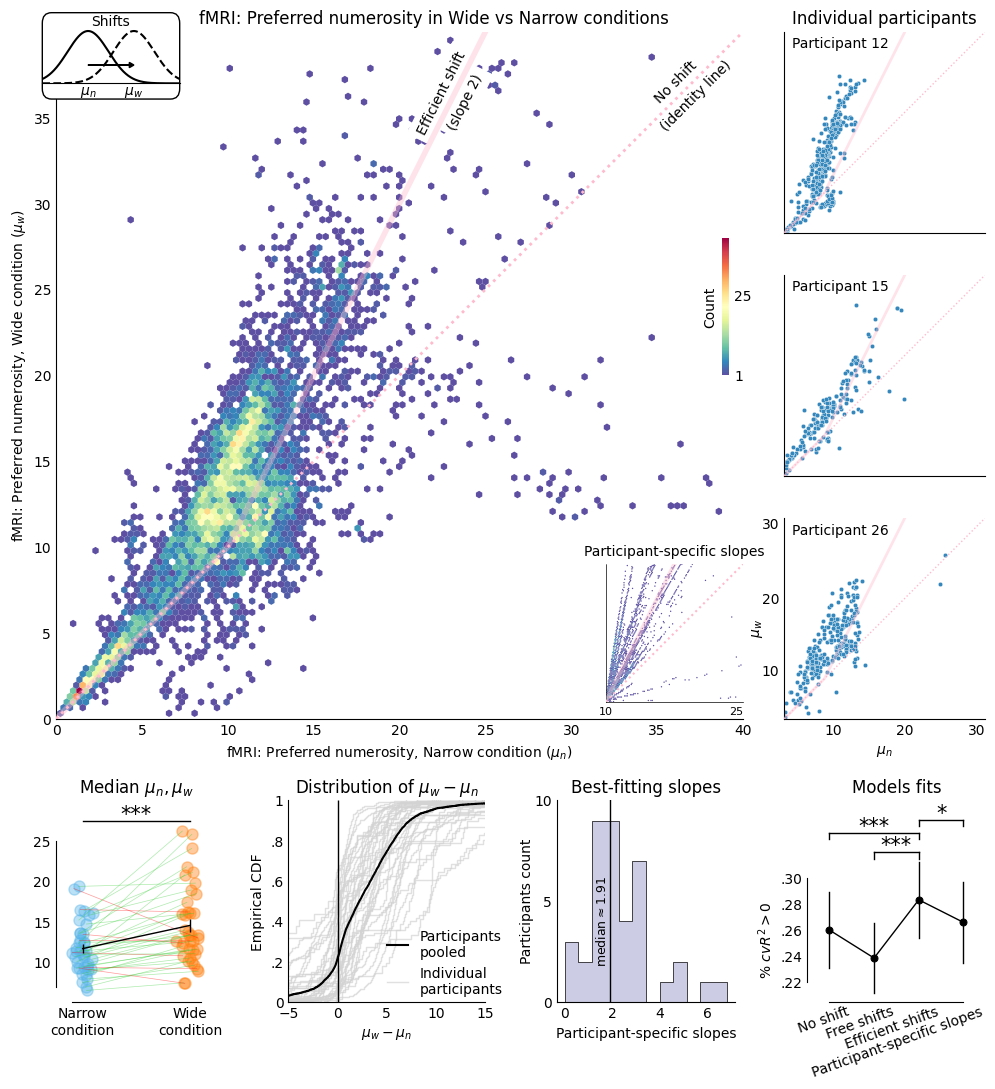

In [514]:
nrows = 4
WITH_GROUND_TRUTH = True
this_df3 = df3_gt if WITH_GROUND_TRUTH else df3
#fig = plt.figure(figsize=(12, nrows*3))
gs = plt.GridSpec(nrows=nrows, ncols=4, height_ratios=(1,1,1,1.2))
#fig, axs = plt.subplots(nrows=nrows, ncols=4, figsize=(12, nrows*3), height_ratios=(1,1,1,1.2))
fig = plt.figure(figsize=(12, (nrows+.2)*3))
#ax = fig.add_subplot(nrows,4,(1,11))
ax = fig.add_subplot(gs[:3, :3])
ax.set_aspect('equal') #, adjustable='box')

cmap = plt.cm.Spectral_r # 'RdYlBu_r', 'YlGnBu_r', 'Spectral_r', 
MUMU_COLOR = cmap(.1) # THIRD_COLOR
LINE_COLOR = 'xkcd:pastel pink' #'C1'

nmax = 40
ind = (this_df3.mu_narrow>=0) & (this_df3.mu_wide>=0) & (this_df3.mu_narrow<=nmax) & (this_df3.mu_wide<=nmax)
print(f'{ind.mean()*100:.2f}% of voxels have 0 <= mu (narrow) <= {nmax} and 0 <= mu (wide) <= {nmax}')
print(f'{(~ind).mean()*100:.2f}% of voxels have mu (narrow) or mu (wide) outside [{0}, {nmax}]')
#sns.histplot(this_df3[ind].mu, x='narrow', y='wide', bins=161, ax=ax, pmax=1, alpha=1, color=MUMU_COLOR, kde=True)
#sns.kdeplot(this_df3[ind].mu, x='narrow', y='wide', ax=ax, levels=6, thresh=.5, fill=True, cmap='YlGnBu')
hb = ax.hexbin(this_df3[ind].mu_narrow, this_df3[ind].mu_wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0.,
          cmap=cmap, mincnt=1, edgecolors='none', clip_on=False)
#sns.scatterplot(this_df3[ind].mu, x='narrow', y='wide', ax=ax, color=MUMU_COLOR, s=1)
#sns.kdeplot(this_df3[ind].mu, x='narrow', y='wide', ax=ax, levels=8, thresh=.1, fill=False, cmap='YlGnBu_r')
#sns.regplot(this_df3[ind].mu, x='narrow', y='wide', ax=ax, scatter=False, line_kws={'color': LINE_COLOR, 'lw': .5}, lowess=True) # ci=None, 
# ns = np.arange(0, 26, 1)
# ys = [ this_df3[(this_df3.mu.narrow>=n-.5) & (this_df3.mu.narrow<=n+.5)].mu.wide.mean() for n in ns]
# ysems = [ this_df3[(this_df3.mu.narrow>=n-.5) & (this_df3.mu.narrow<=n+.5)].mu.wide.sem() for n in ns]
# ax.errorbar(ns, ys, yerr=ysems, color='#FF0000', lw=2, zorder=100)

# Colorbar
cbar_ax = ax.inset_axes([0.97, 0.5, .01, .2])
cb = fig.colorbar(hb, cax=cbar_ax, label='Count', ticks=[1,25,45], drawedges=False)
cb.ax.yaxis.set_label_position('left')
#cb.ax.yaxis.tick_left()
cbar_ax.tick_params(axis='both', length=0)
cb.outline.set_visible(False)

ax.set_xlim(0,nmax); ax.set_ylim(0,nmax)
ax.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=2, zorder=100)
ax.plot([0, 10, 40], [0, 10, 70], c=LINE_COLOR, lw=4, alpha=.4, zorder=100)
ax.set_xlabel('fMRI: Preferred numerosity, Narrow condition ($\mu_n$)')
ax.set_ylabel('fMRI: Preferred numerosity, Wide condition ($\mu_w$)')
ax.set_title('fMRI: Preferred numerosity in Wide vs Narrow conditions', x=.55, y=1.)
ax.text(37.5, 37.5+1, 'No shift', fontsize=10, ha='right', va='top', rotation=45)
ax.text(39.5, 37.5+1, '(identity line)', fontsize=10, ha='right', va='top', rotation=45)
ax.text(24, 38+1,   'Efficient shift', fontsize=10, ha='right', va='top', rotation=63.43, backgroundcolor='w')
ax.text(25, 36.7+1, '(slope 2)', fontsize=10, ha='right', va='top', rotation=63.43, backgroundcolor='w')
#ax.text(22.5, 35+1,   'Efficient shift', fontsize=10, ha='right', va='top', rotation=63.43, backgroundcolor='w')
#ax.text(23.5, 33.7+1, '(slope 2)', fontsize=10, ha='right', va='top', rotation=63.43)
#ax.grid()
ax.set_yticks([0,5,10,15,20,25,30,35])

ax.tick_params(axis='both', length=0)

sns.despine(fig)

##### Icon
icon_width = 0.2; icon_height = .08
icon_ax = ax.inset_axes([-.02, 0.925, icon_width, icon_height], ) 
#inset_ax = fig.add_axes([inset_width/2, 0.8, inset_width, inset_width], )
xxs = np.linspace(0, 3, 1000)
icon_ax.plot(xxs, np.exp(-(xxs-1)**2/.4), color='k') 
icon_ax.plot(xxs, np.exp(-(xxs-2)**2/.4), color='k', linestyle='--')
icon_ax.arrow(x=1, y=0.35, dx=1, dy=0, color='k', lw=1, head_width=0.1, head_length=0.1, length_includes_head=True, zorder=100)
icon_ax.set_ylim(0, None)
icon_ax.set_xlim(0, 3)
icon_ax.set_yticks([])
icon_ax.set_xticks([1,2])
icon_ax.set_xticklabels(['$\mu_n$', '$\mu_w$'])
icon_ax.tick_params(axis='x', length=0, pad=0.5, labelsize=10)
bb = mtransforms.Bbox([[0., -.3], [3, 1.35]])
fancy = FancyBboxPatch(bb.p0, bb.width, bb.height, clip_on=False, facecolor="w", boxstyle="round,pad=0,rounding_size=0.2") # zorder=1000000)
icon_ax.add_patch(fancy)
icon_ax.set_title('Shifts', fontsize=10, y=.9, ha='center')


this_df5 = dfgt5 if WITH_GROUND_TRUTH else dfe5
if True:
    inset_width = 0.2
    #### Inset KDE
    # inset_ax = ax.inset_axes([0.575, 0.025, inset_width, inset_width], aspect='equal') 
    # sns.kdeplot(this_df3[ind].mu, x='narrow', y='wide', ax=inset_ax, levels=6, cmap=cmap, thresh=.15, linewidths=.8)
    # inset_ax.set_xlim(9,25); inset_ax.set_ylim(9,25)
    # inset_ax.axline((0,0), slope=1, color=LINE_COLOR, ls='--', lw=.5, zorder=100)
    # inset_ax.plot([0, 10, 40], [0, 10, 70], c=LINE_COLOR, lw=.5, zorder=100)
    # inset_ax.spines['top'].set_visible(False); inset_ax.spines['right'].set_visible(False)
    # inset_ax.spines['left'].set_linewidth(0.5); inset_ax.spines['bottom'].set_linewidth(0.5)
    # inset_ax.set_xlabel(None); inset_ax.set_ylabel(None)
    # inset_ax.set_xticks([10,25]); inset_ax.set_yticks([10, 25]); inset_ax.set_yticklabels([None,None]); #inset_ax.set_xticklabels([None,None]); 
    # inset_ax.tick_params(axis='both', labelsize=8, length=0)
    # inset_ax.get_xticklabels()[-1].set_ha('right')

    ### Inset Model 5
    inset_ax2 = ax.inset_axes([0.8, 0.025, inset_width, inset_width], aspect='equal')
    nmin_5, nmax_5 = 10, 25
    ind = (this_df5.mu_narrow>=nmin_5) & (this_df5.mu_wide>=nmin_5) & (this_df5.mu_narrow<=nmax_5) & (this_df5.mu_wide<=nmax_5)
    #sns.histplot(this_df[ind].mu, x='narrow', y='wide', bins=161, ax=inset_ax2, pmax=.8, cmap=plt.cm.Spectral_r ) #alpha=.4, color=THIRD_COLOR)
    this_cmap = plt.cm.Spectral_r # 'RdYlBu_r', 'YlGnBu_r', 'Spectral_r', # plt.cm.RdYlBu #
    inset_ax2.hexbin(this_df5[ind].mu_narrow, this_df5[ind].mu_wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0., cmap=this_cmap, mincnt=1, edgecolors='none', ) #bins='log')
    inset_ax2.set_xlim(nmin_5,nmax_5); inset_ax2.set_ylim(nmin_5,nmax_5)
    inset_ax2.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=1.5, zorder=100)
    inset_ax2.plot([0, 10, 40], [0, 10, 70], c=LINE_COLOR, lw=3, alpha=.4, zorder=100)
    inset_ax2.spines['top'].set_visible(False)
    inset_ax2.spines['right'].set_visible(False)
    inset_ax2.spines['left'].set_linewidth(0.5)
    inset_ax2.spines['bottom'].set_linewidth(0.5)
    inset_ax2.set_xlabel(None); inset_ax2.set_ylabel(None)
    #inset_ax2.set_title('Free-slope model', fontsize=8)
    inset_ax2.set_xticks([10,25]); inset_ax2.set_yticks([10,25]); inset_ax2.set_yticklabels([None,None]);
    inset_ax2.tick_params(axis='both', labelsize=8, length=0)
    inset_ax2.get_xticklabels()[-1].set_ha('right')
    inset_ax2.set_title('Participant-specific slopes', backgroundcolor='w', fontsize=10)



###### Individual subjects
select_subjs = [12,15,26]
axS1 = fig.add_subplot(gs[0, 3]) # fig.add_subplot(nrows,4,4)
sns.scatterplot(data=index_filter(this_df3, subject=12), x='mu_narrow', y='mu_wide', color=MUMU_COLOR, s=10, alpha=1, ax=axS1)
axS2 = fig.add_subplot(gs[1, 3]) # fig.add_subplot(nrows,4,8)
sns.scatterplot(data=index_filter(this_df3, subject=15), x='mu_narrow', y='mu_wide', color=MUMU_COLOR, s=10, alpha=1, ax=axS2)
axS3 = fig.add_subplot(gs[2, 3]) # fig.add_subplot(nrows,4,12)
sns.scatterplot(data=index_filter(this_df3, subject=26), x='mu_narrow', y='mu_wide', color=MUMU_COLOR, s=10, alpha=1, ax=axS3)
for ii,ax in enumerate([axS1, axS2, axS3]):
    ax.set_aspect('equal')
    ax.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=1, zorder=100)
    ax.plot([0, 10, 40], [0, 10, 70], c=LINE_COLOR, lw=2, alpha=.4, zorder=100)
    ax.set_xlim(5, 30); ax.set_ylim(5, 30)
    ax.set_xlabel(None); ax.set_ylabel(None)
    ax.set_xticks([]); ax.set_yticks([])
    #ax.text(20, 10, f'Subject {select_subjs[ii]}', fontsize=10)
    ax.text(6, 28, f'Participant {select_subjs[ii]}', fontsize=10, ha='left')
axS1.set_title('Individual participants')
#axS3.set_xticks([5, 10, 15, 20, 25, 30]); axS3.set_yticks([5, 10, 15, 20, 25, 30]);
axS3.set_xticks([10,20,30]); axS3.set_yticks([10,20,30]);
#ax.set_xticklabels([]); ax.set_yticklabels([]);
axS3.tick_params(axis='both', length=0) # labelsize=8, 
axS3.get_xticklabels()[0].set_ha('left'); axS3.get_xticklabels()[-1].set_ha('right')
axS3.get_yticklabels()[-1].set_va('top'); axS3.get_yticklabels()[0].set_va('bottom')
axS3.set_xlabel('$\mu_n$')
axS3.set_ylabel('$\mu_w$', labelpad=-2, y=.45)

######## Bottom row
gs2 = plt.GridSpec(nrows=nrows, ncols=4, height_ratios=(1,1,1,1.2), hspace=.5, width_ratios=(.9,1.1,1,1), wspace=.4)

######## Median preferred numerosities
ax = fig.add_subplot(gs2[3,0])

mu_wide_medians = this_df3.mu_wide.groupby('subject').median()
mu_narrow_medians = this_df3.mu_narrow.groupby('subject').median()
print( (mu_wide_medians >= mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition larger than in Narrow condition' )
print( (mu_wide_medians <  mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition smaller than in Narrow condition' )
paired_strip_plot(ax, x1=1, x2=2, y1=mu_narrow_medians, y2=mu_wide_medians, 
                  col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE], color_incr_line='limegreen', color_decr_line='r')
ax.errorbar([1, 2], [mu_narrow_medians.mean(), mu_wide_medians.mean()], yerr=[mu_narrow_medians.sem(), mu_wide_medians.sem()],
                color='k', lw=1, marker='none')
ax.set_xticks([1, 2])
ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
#ax.set_title("Median preferred num.")
ax.set_title("Median $\mu_n, \mu_w$")
ax.set_xlim(0.75, 2.25)
ax.set_ylim(5.1,29.999) if WITH_GROUND_TRUTH else ax.set_ylim(6.1,24.5) #23.9)
# paired test
paired_test = pg.ttest(mu_narrow_medians, mu_wide_medians, paired=True)
print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
# ax.hlines(0.95*ax.get_ylim()[1], 1, 2, color='k', lw=1.5)
# ax.text(1.5, 0.96*ax.get_ylim()[1], '***', ha='center', va='center', fontsize=16, color='k')
star_line(ax, 1, 2, 27.5 if WITH_GROUND_TRUTH else 22.5, paired_test['p-val'].iloc[0], star_size=15, star_offset=-.5)

ax.tick_params(axis='both', length=0)
ax.spines.left.set_bounds((7, 25 if WITH_GROUND_TRUTH else 22))
ax.spines.bottom.set_bounds((.9, 2.1))

######## CDF of change in preferred numerosity
ax = fig.add_subplot(gs2[3,1])
all_data = []
#ind = (this_df3.mu.narrow>=10) & (this_df3.mu.wide>=10) #& (this_df3.mu.narrow<=40) & (this_df3.mu.wide<=40)
subjects = this_df3.index.get_level_values('subject').unique()
for subject in subjects:
    data = this_df3.xs(subject, level='subject')['mu_delta_wn']
    all_data.append(pd.DataFrame({'mu_delta_wn': data.dropna(), 'subject': subject}))
all_data = pd.concat(all_data, ignore_index=True)
# Plot the CDFs for each subject in light grey (no hue, loop over subjects)
c_ind = 'lightgrey'
for subject in subjects:
    subj_data = all_data[all_data['subject'] == subject]
    sns.ecdfplot(data=subj_data, x='mu_delta_wn', color=c_ind, linewidth=1, alpha=0.7, legend=False, ax=ax)
# Plot the pooled CDF (all subjects together) in a bold color
this_color = 'k'; this_lw = 1.5
sns.ecdfplot(data=all_data, x='mu_delta_wn', color=this_color, linewidth=this_lw, label='Participants pooled', ax=ax, legend=False) # THIRD_COLOR
print( (all_data.mu_delta_wn<0).mean() * 100, '% of voxels have $\mu_{w} - \mu_{n} < 0$' )
ax.set_title("Distribution of $\mu_{w} - \mu_{n}$")
#ax.set_title("Change in preferred numerosity")
ax.set_xlabel('$\mu_{w} - \mu_{n}$')
ax.set_ylabel('Empirical CDF')
ax.legend(handles=[plt.Line2D([0], [0], color=this_color, lw=this_lw, label='Participants\npooled'),
                    plt.Line2D([0], [0], color=c_ind, alpha=.7, lw=1, label='Individual\nparticipants')], loc=(.475,0),
                    handlelength=1.5, frameon=False)
ax.set_xlim(-5, 15)
ax.vlines(0, 0, 1, color='black', linestyle='-', lw=1)
ax.set_yticks([0, .2, .4, .6, .8, 1])
ax.set_yticklabels(['0', '.2', '.4', '.6', '.8', '1'])
ax.tick_params(axis='both', length=0)


########### Distribution delta_wide
ax = fig.add_subplot(gs2[3,2])
ratio_mu = this_df5.delta_wide_narrow.groupby('subject').first()
nb_bins_02 = 3
dw = 2 / (nb_bins_02 + 1/2)
bins = np.arange(0, ratio_mu.max()+dw, dw)
this_color = 1 - .4*( 1 -  np.array( plt.cm.Spectral_r(.02)[:3] ) ) # equivalent to the color with some alpha, on white. (With cB = 1 - alpha*(1-cA), color cB is like (cA,alpha) on white.)
sns.histplot(ratio_mu, bins=bins, ax=ax, color=this_color, linewidth=.5, element='step', ec='k') # plt.cm.RdYlBu(0.4)
ax.set_title("Best-fitting slopes")
ax.set_xlabel('Participant-specific slopes')
ax.set_yticks([0, 5, 10]) if WITH_GROUND_TRUTH else ax.set_yticks([0, 5, 10, 15])
ax.set_ylabel('Participants count', labelpad=0)
ax.tick_params(axis='both', length=0)
# ax.axvline(2, color=LINE_COLOR, linestyle='-', lw=1)
ax.axvline(ratio_mu.median(), color='k', linestyle='-', lw=1)
ax.text(ratio_mu.median()-.05, 4., f'median$\\approx${ratio_mu.median():.2f}', rotation=90, va='center', ha='right', fontsize=9)


########## Proportion cvR2>0
ax = fig.add_subplot(gs2[3,3])
modelz = dict( [(0, 'No shift'), (3, 'Free shifts'), (4, 'Efficient shifts'), (5, 'Participant-specific slopes')] )
these_rez = (rez if WITH_GROUND_TRUTH else rez_est).loc[:,list(modelz.keys())].rename(columns=modelz)
these_rez
#sns.stripplot(these_rez, color=FOURTH_COLOR) 
sns.pointplot(these_rez, errorbar='se', color='k', markersize=5, linewidth=1, ax=ax) # THIRD_COLOR
ax.set_xlabel(None)
#### x ticks labels positions
ax.tick_params(axis='both', length=0)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right', va='top', rotation_mode="anchor")
# Create offset transform
dx = 12./72.; dy = 2/72. 
offset = ScaledTranslation(dx, dy, fig.dpi_scale_trans)
# apply offset transform to all x ticklabels.
for label in ax.xaxis.get_majorticklabels(): label.set_transform(label.get_transform() + offset)
ax.set_xlim(-.5,3.5)
#### y 
ax.set_yticks([.22, .24, .26, .28, .3]) if WITH_GROUND_TRUTH else ax.set_yticks([.24, .26, .28, .3, .32])
ax.set_yticklabels(['.22', '.24', '.26', '.28', '.30',]) if WITH_GROUND_TRUTH else ax.set_yticklabels(['.24', '.26', '.28', '.30', '.32'])
ax.set_ylabel('% $cvR^2 > 0$', y=.5, ha='right')
#ax.set_ylim(.23, .33)
ax.spines.left.set_bounds((.22, .3)) if WITH_GROUND_TRUTH else ax.spines.left.set_bounds((.24, .32))
ax.spines.bottom.set_bounds((0, 3))
sns.despine(fig)
# (0,4), (3,4), (5,4) 
vll = 0.005
star_size = 15
star_offset = -.0025
star_line(ax, 0, 2, .335 if WITH_GROUND_TRUTH else .355, compare_res_est.loc[(0,4)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
star_line(ax, 1, 2, .320 if WITH_GROUND_TRUTH else .340, compare_res_est.loc[(3,4)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
#star_line(ax, 3, 2, .365, compare_res_est.loc[(4,5)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
onesided_test = pg.ttest(x=rez_est[4], y=rez_est[5], paired=True, alternative='greater')
notonesided_test = pg.ttest(x=rez_est[4], y=rez_est[5], paired=True)
star_line(ax, 3, 2, .345 if WITH_GROUND_TRUTH else .365, notonesided_test.iloc[0]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
print(notonesided_test)
ax.set_title('Models fits')
ax.set_ylim(None, .36 if WITH_GROUND_TRUTH else .38)

sns.despine(fig)
sns.despine(ax=icon_ax, left=True)

fig.savefig(f'figures/mu_wide_vs_narrow{"_gt" if WITH_GROUND_TRUTH else ""}.pdf', bbox_inches='tight')

In [515]:
ratio_mu.median()

1.9074111

In [516]:
1 - .4*( 1 -  np.array( plt.cm.Spectral_r(.02)[:3] ) )

array([0.73391772, 0.74145329, 0.86242215])

In [517]:
compare_res_est.loc[(3,4)]['p-val']

4.628455180204602e-10

In [518]:
1./np.sqrt(1+(np.pi**2/8)*.9*.1)

0.9487166248873418

In [597]:
#df3[ind]nmax = 40
#ind = (df3.mu.narrow>=0) & (df3.mu.wide>=0) & (df3.mu.narrow<=nmax) & (df3.mu.wide<=nmax)
delta = .5
print( df3[(df3.mu_narrow>=15-delta) & (df3.mu_narrow<=15+delta)].mu_wide.mean() )
print( df3[(df3.mu_narrow>=15-delta) & (df3.mu_narrow<=15+delta)].mu_wide.sem() )
#pg.ttest(df3[(df3.mu.narrow>=14.75) & (df3.mu.narrow<=15.25)].mu.wide, 15, alternative='two-sided')

20.011980300283287
0.1886053022390431


In [598]:
((df3.mu_narrow>25)).mean()

0.023736317796089042

In [522]:
((df3.mu_narrow<10) & (df3.mu_wide<=10)).mean()

0.12876644939121878

37 subjects have median $\mu$ in Wide condition larger than in Narrow condition
2 subjects have median $\mu$ in Wide condition smaller than in Narrow condition
Paired t-test: t = -8.814, p = 1.01e-10, dof = 38
15.803714180297627 % of voxels have $\mu_{w} - \mu_{n} < 0$


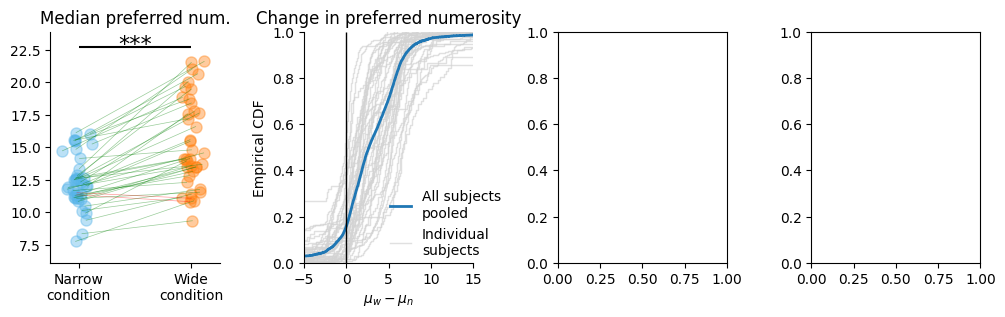

In [524]:
######## Bottom row
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(12, 3))

######## Median preferred numerosities
ax = axs[0]
# mu_wide_medians = df3[('mu', 'wide')].groupby('subject').median()
# mu_narrow_medians = df3[('mu', 'narrow')].groupby('subject').median()
mu_wide_medians = df3.mu_wide.groupby('subject').median()
mu_narrow_medians = df3.mu_narrow.groupby('subject').median()
print( (mu_wide_medians >= mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition larger than in Narrow condition' )
print( (mu_wide_medians <  mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition smaller than in Narrow condition' )
paired_strip_plot(ax, x1=1, x2=2, y1=mu_narrow_medians, y2=mu_wide_medians, 
                  col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE], color_incr_line='g', color_decr_line='r',)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
ax.set_title("Median preferred num.")
ax.set_xlim(0.75, 2.25)
ax.set_ylim(6.1,23.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# paired test
paired_test = pg.ttest(mu_narrow_medians, mu_wide_medians, paired=True)
print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
# add a horizontal line above the two clouds of dots, with tree stars, reflecting the p-value
ax.hlines(0.95*ax.get_ylim()[1], 1, 2, color='k', lw=1.5)
ax.text(1.5, 0.96*ax.get_ylim()[1], '***', ha='center', va='center', fontsize=16, color='k')


######## CDF of change in preferred numerosity
ax = axs[1]
all_data = []
#ind = (df3.mu.narrow>=10) & (df3.mu.wide>=10) #& (df3.mu.narrow<=40) & (df3.mu.wide<=40)
subjects = df3.index.get_level_values('subject').unique()
for subject in subjects:
    data = df3.xs(subject, level='subject').mu_delta_wn # [('mu', 'delta_wn')]
    all_data.append(pd.DataFrame({'mu_delta_wn': data.dropna(), 'subject': subject}))
all_data = pd.concat(all_data, ignore_index=True)
# Plot the CDFs for each subject in light grey (no hue, loop over subjects)
c_ind = 'lightgrey'
for subject in subjects:
    subj_data = all_data[all_data['subject'] == subject]
    sns.ecdfplot(data=subj_data, x='mu_delta_wn', color=c_ind, linewidth=1, alpha=0.7, legend=False, ax=ax)

# Plot the pooled CDF (all subjects together) in a bold color
sns.ecdfplot(data=all_data, x='mu_delta_wn', color='C0', linewidth=2, label='All subjects pooled', ax=ax)
print( (all_data.mu_delta_wn<0).mean() * 100, '% of voxels have $\mu_{w} - \mu_{n} < 0$' )

#plt.title("Empirical CDF of $\mu_{w} - \mu_{n}$")
ax.set_title("Change in preferred numerosity")
ax.set_xlabel('$\mu_{w} - \mu_{n}$')
ax.set_ylabel('Empirical CDF')
ax.legend(handles=[plt.Line2D([0], [0], color='C0', lw=2, label='All subjects\npooled'),
                    plt.Line2D([0], [0], color=c_ind, alpha=.7, lw=1, label='Individual\nsubjects')], loc=(.475,0), handlelength=1.5)
ax.set_xlim(-5, 15)
ax.vlines(0, 0, 1, color='black', linestyle='-', lw=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.subplots_adjust(wspace=0.5)

#fig.savefig('figures/bottom_row.pdf', bbox_inches='tight')

## For presentation

90.69% of voxels have 5 <= mu (narrow) <= 30 and 5 <= mu (wide) <= 30
9.31% of voxels have mu (narrow) or mu (wide) outside [5, 30]


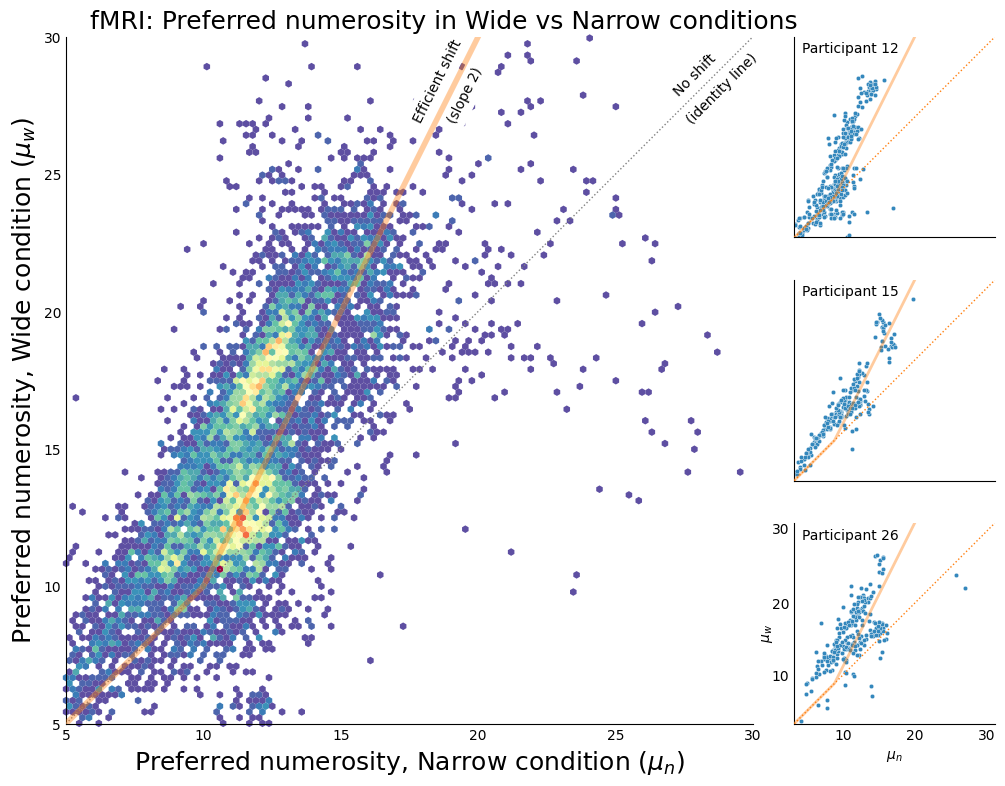

In [526]:
nrows = 4
#fig = plt.figure(figsize=(12, nrows*3))
gs = plt.GridSpec(nrows=nrows, ncols=4, height_ratios=(1,1,1,1.2))
#fig, axs = plt.subplots(nrows=nrows, ncols=4, figsize=(12, nrows*3), height_ratios=(1,1,1,1.2))
fig = plt.figure(figsize=(12, (nrows+.2)*3))
#ax = fig.add_subplot(nrows,4,(1,11))
ax = fig.add_subplot(gs[:3, :3])
ax.set_aspect('equal') #, adjustable='box')

cmap = plt.cm.Spectral_r # 'RdYlBu_r', 'YlGnBu_r', 'Spectral_r', 
MUMU_COLOR = cmap(.1) # THIRD_COLOR
LINE_COLOR = 'C1' #'xkcd:pastel pink' #'C1'

nmin = 5
nmax = 30
ind = (df3.mu_narrow>=nmin) & (df3.mu_wide>=nmin) & (df3.mu_narrow<=nmax) & (df3.mu_wide<=nmax)
print(f'{ind.mean()*100:.2f}% of voxels have {nmin} <= mu (narrow) <= {nmax} and {nmin} <= mu (wide) <= {nmax}')
print(f'{(~ind).mean()*100:.2f}% of voxels have mu (narrow) or mu (wide) outside [{nmin}, {nmax}]')
hb = ax.hexbin(df3[ind].mu_narrow, df3[ind].mu_wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0.,
          cmap=cmap, mincnt=1, edgecolors='none', clip_on=False)

# Colorbar
# cbar_ax = ax.inset_axes([0.97, 0.5, .01, .2])
# cb = fig.colorbar(hb, cax=cbar_ax, label='Count', ticks=[1,25,49], drawedges=False)
# cb.ax.yaxis.set_label_position('left')
# #cb.ax.yaxis.tick_left()
# cbar_ax.tick_params(axis='both', length=0)
# cb.outline.set_visible(False)

ax.set_xlim(nmin,nmax); ax.set_ylim(nmin,nmax)
ax.axline((nmin,nmin), slope=1, color='grey', ls=':', lw=1, zorder=100)
ax.plot([nmin, 10, 40], [nmin, 10, 70], c=LINE_COLOR, lw=4, alpha=.4, zorder=100)
ax.set_xlabel('Preferred numerosity, Narrow condition ($\mu_n$)', fontsize=18)
ax.set_ylabel('Preferred numerosity, Wide condition ($\mu_w$)', fontsize=18)
ax.set_title('fMRI: Preferred numerosity in Wide vs Narrow conditions', x=.55, y=1., fontsize=18)
ax.text(28.75, 28.5+1, 'No shift', fontsize=10, ha='right', va='top', rotation=45)
ax.text(30.25, 28.5+1, '(identity line)', fontsize=10, ha='right', va='top', rotation=45)
ax.text(19.5, 29+1,   'Efficient shift', fontsize=10, ha='right', va='top', rotation=63.43, backgroundcolor='w')
ax.text(20.25, 28+1, '(slope 2)', fontsize=10, ha='right', va='top', rotation=63.43, backgroundcolor='w')
#ax.text(22.5, 35+1,   'Efficient shift', fontsize=10, ha='right', va='top', rotation=63.43, backgroundcolor='w')
#ax.text(23.5, 33.7+1, '(slope 2)', fontsize=10, ha='right', va='top', rotation=63.43)
#ax.grid()
ax.set_yticks([5,10,15,20,25,30])

ax.tick_params(axis='both', length=0)

sns.despine(fig)

###### Individual subjects
select_subjs = [12,15,26]
axS1 = fig.add_subplot(gs[0, 3]) # fig.add_subplot(nrows,4,4)
sns.scatterplot(data=index_filter(df3, subject=12), x='mu_narrow', y='mu_wide', color=MUMU_COLOR, s=10, alpha=1, ax=axS1)
axS2 = fig.add_subplot(gs[1, 3]) # fig.add_subplot(nrows,4,8)
sns.scatterplot(data=index_filter(df3, subject=15), x='mu_narrow', y='mu_wide', color=MUMU_COLOR, s=10, alpha=1, ax=axS2)
axS3 = fig.add_subplot(gs[2, 3]) # fig.add_subplot(nrows,4,12)
sns.scatterplot(data=index_filter(df3, subject=26), x='mu_narrow', y='mu_wide', color=MUMU_COLOR, s=10, alpha=1, ax=axS3)
for ii,ax in enumerate([axS1, axS2, axS3]):
    ax.set_aspect('equal')
    ax.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=1, zorder=100)
    ax.plot([0, 10, 40], [0, 10, 70], c=LINE_COLOR, lw=2, alpha=.4, zorder=100)
    ax.set_xlim(5, 30); ax.set_ylim(5, 30)
    ax.set_xlabel(None); ax.set_ylabel(None)
    ax.set_xticks([]); ax.set_yticks([])
    #ax.text(20, 10, f'Subject {select_subjs[ii]}', fontsize=10)
    ax.text(6, 28, f'Participant {select_subjs[ii]}', fontsize=10, ha='left')
#axS1.set_title('Individual participants')
#axS3.set_xticks([5, 10, 15, 20, 25, 30]); axS3.set_yticks([5, 10, 15, 20, 25, 30]);
axS3.set_xticks([10,20,30]); axS3.set_yticks([10,20,30]);
#ax.set_xticklabels([]); ax.set_yticklabels([]);
axS3.tick_params(axis='both', length=0) # labelsize=8, 
axS3.get_xticklabels()[0].set_ha('left'); axS3.get_xticklabels()[-1].set_ha('right')
axS3.get_yticklabels()[-1].set_va('top'); axS3.get_yticklabels()[0].set_va('bottom')
axS3.set_xlabel('$\mu_n$')
axS3.set_ylabel('$\mu_w$', labelpad=-2, y=.45)

######## Bottom row
gs2 = plt.GridSpec(nrows=nrows, ncols=4, height_ratios=(1,1,1,1.2), hspace=.5, width_ratios=(.9,1.1,1,1), wspace=.4)

if False:
    ######## Median preferred numerosities
    ax = fig.add_subplot(gs2[3,0])

    mu_wide_medians = df3[('mu', 'wide')].groupby('subject').median()
    mu_narrow_medians = df3[('mu', 'narrow')].groupby('subject').median()
    print( (mu_wide_medians >= mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition larger than in Narrow condition' )
    print( (mu_wide_medians <  mu_narrow_medians).sum(), 'subjects have median $\mu$ in Wide condition smaller than in Narrow condition' )
    paired_strip_plot(ax, x1=1, x2=2, y1=mu_narrow_medians, y2=mu_wide_medians, 
                    col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE], color_incr_line='limegreen', color_decr_line='r',)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
    #ax.set_title("Median preferred num.")
    ax.set_title("Median $\mu_n, \mu_w$")
    ax.set_xlim(0.75, 2.25)
    ax.set_ylim(6.1,24.5) #23.9)
    # paired test
    paired_test = pg.ttest(mu_narrow_medians, mu_wide_medians, paired=True)
    print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
    # ax.hlines(0.95*ax.get_ylim()[1], 1, 2, color='k', lw=1.5)
    # ax.text(1.5, 0.96*ax.get_ylim()[1], '***', ha='center', va='center', fontsize=16, color='k')
    star_line(ax, 1, 2, 22.5, paired_test['p-val'].iloc[0], star_size=15, star_offset=-.5)

    ax.tick_params(axis='both', length=0)
    ax.spines.left.set_bounds((7, 22))
    ax.spines.bottom.set_bounds((.9, 2.1))

    ######## CDF of change in preferred numerosity
    ax = fig.add_subplot(gs2[3,1])
    all_data = []
    #ind = (df3.mu.narrow>=10) & (df3.mu.wide>=10) #& (df3.mu.narrow<=40) & (df3.mu.wide<=40)
    subjects = df3.index.get_level_values('subject').unique()
    for subject in subjects:
        data = df3.xs(subject, level='subject')[('mu', 'delta_wn')]
        all_data.append(pd.DataFrame({'mu_delta_wn': data.dropna(), 'subject': subject}))
    all_data = pd.concat(all_data, ignore_index=True)
    # Plot the CDFs for each subject in light grey (no hue, loop over subjects)
    c_ind = 'lightgrey'
    for subject in subjects:
        subj_data = all_data[all_data['subject'] == subject]
        sns.ecdfplot(data=subj_data, x='mu_delta_wn', color=c_ind, linewidth=1, alpha=0.7, legend=False, ax=ax)
    # Plot the pooled CDF (all subjects together) in a bold color
    this_color = 'k'; this_lw = 1.5
    sns.ecdfplot(data=all_data, x='mu_delta_wn', color=this_color, linewidth=this_lw, label='Participants pooled', ax=ax, legend=False) # THIRD_COLOR
    print( (all_data.mu_delta_wn<0).mean() * 100, '% of voxels have $\mu_{w} - \mu_{n} < 0$' )
    ax.set_title("Distribution of $\mu_{w} - \mu_{n}$")
    #ax.set_title("Change in preferred numerosity")
    ax.set_xlabel('$\mu_{w} - \mu_{n}$')
    ax.set_ylabel('Empirical CDF')
    ax.legend(handles=[plt.Line2D([0], [0], color=this_color, lw=this_lw, label='Participants\npooled'),
                        plt.Line2D([0], [0], color=c_ind, alpha=.7, lw=1, label='Individual\nparticipants')], loc=(.475,0),
                        handlelength=1.5, frameon=False)
    ax.set_xlim(-5, 15)
    ax.vlines(0, 0, 1, color='black', linestyle='-', lw=1)
    ax.set_yticks([0, .2, .4, .6, .8, 1])
    ax.set_yticklabels(['0', '.2', '.4', '.6', '.8', '1'])
    ax.tick_params(axis='both', length=0)


    ########### Distribution delta_wide
    ax = fig.add_subplot(gs2[3,2])
    ratio_mu = dfe5.delta_wide.narrow.groupby('subject').first()
    nb_bins_02 = 3
    dw = 2 / (nb_bins_02 + 1/2)
    bins = np.arange(0, ratio_mu.max()+dw, dw)
    this_color = 1 - .4*( 1 -  np.array( plt.cm.Spectral_r(.02)[:3] ) ) # equivalent to the color with some alpha, on white. (With cB = 1 - alpha*(1-cA), color cB is like (cA,alpha) on white.)
    sns.histplot(ratio_mu, bins=bins, ax=ax, color=this_color, linewidth=.5, element='step', ec='k') # plt.cm.RdYlBu(0.4)
    ax.set_title("Best-fitting slopes")
    ax.set_xlabel('Participant-specific slopes')
    ax.set_yticks([0, 5, 10, 15])
    ax.set_ylabel('Participants count', labelpad=0)
    ax.tick_params(axis='both', length=0)
    # ax.axvline(2, color=LINE_COLOR, linestyle='-', lw=1)
    ax.axvline(ratio_mu.median(), color='k', linestyle='-', lw=1)
    ax.text(ratio_mu.median()-.05, 4., f'median$\\approx${ratio_mu.median():.2f}', rotation=90, va='center', ha='right', fontsize=9)


    ########## Proportion cvR2>0
    ax = fig.add_subplot(gs2[3,3])
    modelz = dict( [(0, 'No shift'), (3, 'Free shifts'), (4, 'Efficient shifts'), (5, 'Participant-specific slopes')] )
    these_rez = rez_est.loc[:,list(modelz.keys())].rename(columns=modelz)
    these_rez
    #sns.stripplot(these_rez, color=FOURTH_COLOR) 
    sns.pointplot(these_rez, errorbar='se', color='k', markersize=5, linewidth=1, ax=ax) # THIRD_COLOR
    ax.set_xlabel(None)
    #### x ticks labels positions
    ax.tick_params(axis='both', length=0)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', va='top', rotation_mode="anchor")
    # Create offset transform
    dx = 12./72.; dy = 2/72. 
    offset = ScaledTranslation(dx, dy, fig.dpi_scale_trans)
    # apply offset transform to all x ticklabels.
    for label in ax.xaxis.get_majorticklabels(): label.set_transform(label.get_transform() + offset)
    ax.set_xlim(-.5,3.5)
    #### y 
    ax.set_yticks([.24, .26, .28, .3, .32])
    ax.set_yticklabels(['.24', '.26', '.28', '.30', '.32'])
    ax.set_ylabel('% $cvR^2 > 0$', y=.5, ha='right')
    #ax.set_ylim(.23, .33)
    ax.spines.left.set_bounds((.24, .32))
    ax.spines.bottom.set_bounds((0, 3))
    sns.despine(fig)
    # (0,4), (3,4), (5,4) 
    vll = 0.005
    star_size = 15
    star_offset = -.0025
    star_line(ax, 0, 2, .355, compare_res_est.loc[(0,4)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
    star_line(ax, 1, 2, .340, compare_res_est.loc[(3,4)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
    #star_line(ax, 3, 2, .365, compare_res_est.loc[(4,5)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
    onesided_test = pg.ttest(x=rez_est[4], y=rez_est[5], paired=True, alternative='greater')
    notonesided_test = pg.ttest(x=rez_est[4], y=rez_est[5], paired=True)
    star_line(ax, 3, 2, .365, notonesided_test.iloc[0]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
    print(notonesided_test)
    ax.set_title('Models fits')
    ax.set_ylim(None, .38)

sns.despine(fig)
#sns.despine(ax=icon_ax, left=True)

#fig.savefig('figures/pres_mu_wide_vs_narrow.pdf', bbox_inches='tight')

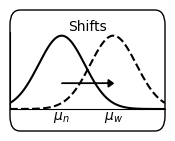

In [527]:
##### Icon
icon_width = 0.2; icon_height = .08
fig, icon_ax = plt.subplots(figsize=(2, 1))
#inset_ax = fig.add_axes([inset_width/2, 0.8, inset_width, inset_width], )
xxs = np.linspace(0, 3, 1000)
icon_ax.plot(xxs, np.exp(-(xxs-1)**2/.4), color='k') 
icon_ax.plot(xxs, np.exp(-(xxs-2)**2/.4), color='k', linestyle='--')
icon_ax.arrow(x=1, y=0.35, dx=1, dy=0, color='k', lw=1, head_width=0.1, head_length=0.1, length_includes_head=True, zorder=100)
icon_ax.set_ylim(0, None)
icon_ax.set_xlim(0, 3)
icon_ax.set_yticks([])
icon_ax.set_xticks([1,2])
icon_ax.set_xticklabels(['$\mu_n$', '$\mu_w$'])
icon_ax.tick_params(axis='x', length=0, pad=0.5, labelsize=10)
bb = mtransforms.Bbox([[0., -.3], [3, 1.35]])
fancy = FancyBboxPatch(bb.p0, bb.width, bb.height, clip_on=False, facecolor="w", boxstyle="round,pad=0,rounding_size=0.2") # zorder=1000000)
icon_ax.add_patch(fancy)
icon_ax.set_title('Shifts', fontsize=10, y=.9, ha='center')
sns.despine(fig)
fig.savefig('figures/icon_mu_shift.pdf', bbox_inches='tight')

# Model 14 (free sds)

In [528]:
# dfgt14 = index_filter(pars, type='ground_truth', smoothed=True, model_label=14)
# dfgt14 = dfgt14[ dfgt14[('cvr2', 'nan')] > 0] #.drop(columns='alpha')
# dfgt14.index.rename(['subject', 'voxel'], inplace=True)
# dfgt14

# dfest14 = index_filter(pars, type='estimates', smoothed=True, model_label=14)
# dfest14 = dfest14[ dfest14[('cvr2', 'nan')] > 0] #.drop(columns='alpha')
# dfest14.index.rename(['subject', 'voxel'], inplace=True)
# dfest14

# was:
# 98.06% of voxels have 0 <= mu (narrow) <= 40 and 0 <= mu (wide) <= 40
# 1.94% of voxels have mu (narrow) or mu (wide) outside [0, 40]
# 37 subjects have median $\mu$ in Wide condition larger than in Narrow condition
# 2 subjects have median $\mu$ in Wide condition smaller than in Narrow condition
# Paired t-test: t = -8.983, p = 6.16e-11, dof = 38
# 16.15884115884116 % of voxels have $\mu_{w} - \mu_{n} < 0$
#                T  dof alternative     p-val        CI95%   cohen-d   BF10     power
# T-test  2.592253   38   two-sided  0.013459  [0.0, 0.02]  0.053155  3.196  0.062084
# 98.06% of voxels have 0 <= mu (narrow) <= 40 and 0 <= mu (wide) <= 40
# 1.94% of voxels have mu (narrow) or mu (wide) outside [0, 40]
# 37 subjects have median $\mu$ in Wide condition larger than in Narrow condition
# 2 subjects have median $\mu$ in Wide condition smaller than in Narrow condition
# Paired t-test: t = -8.983, p = 6.16e-11, dof = 38
# 16.15884115884116 % of voxels have $\mu_{w} - \mu_{n} < 0$
#                T  dof alternative     p-val        CI95%   cohen-d   BF10     power
# T-test  2.592253   38   two-sided  0.013459  [0.0, 0.02]  0.053155  3.196  0.062084

dfgt14 = index_filter(pars, response_fit=False, model_label=14)
dfgt14 = dfgt14[ dfgt14.cvr2> 0]
dfgt14

dfest14 = index_filter(pars, response_fit=True, model_label=14)
dfest14 = dfest14[ dfest14.cvr2> 0]
dfest14

loglikelihood      cvr2          aic          bic  mu_narrow    mu_wide  sd_narrow   sd_wide  delta_wide_narrow  delta_wide_wide  amplitude_narrow  \
subject voxel                                                                                                                                                       
1       10       -676.686509  0.007944  1365.373018  1390.415734  12.181757  14.363514   0.692355  1.001164                2.0              2.0          1.356081   
        13       -627.091152  0.008833  1266.182305  1291.225021  11.979450  13.958900   0.401673  0.546460                2.0              2.0          0.632903   
        16       -547.389083  0.000943  1106.778167  1131.820883  11.622056  13.244112   0.359948  0.441931                2.0              2.0          0.422997   
        19       -473.538336  0.001557   959.076672   984.119388  10.287462  10.574924   0.395287  0.442017                2.0              2.0          0.400638   
        20       -611.058284  0.010135  1234.116568  1259.159285  10.003069  10.006138   0.572352  0.672433                2.0              2.0          0.665699   
...                      ...       ...          ...          ...        ...        ...        ...       ...                ...              ...               ...   
41      684      -221.417046  0.016693   454.834092   479.876809  15.565413  21.130827   0.095523  0.149099                2.0              2.0          0.279757   
        686      -439.871532  0.002267   891.743064   916.785781  11.275817  12.551634   0.311528  0.221549                2.0              2.0          0.315620   
        687      -427.407692  0.004594   866.815384   891.858100  11.196170  12.392340   0.310941  0.198242                2.0              2.0          0.332232   
        689      -282.387715  0.002505   576.775430   601.818147  13.385760  16.771520   0.743725  1.033240                2.0              2.0          0.764908   
        691      -295.100289  0.002261   602.200579   627.243296  13.528701  17.057402   0.654947  0.945158                2.0              2.0          0.603408   

               amplitude_wide  baseline_narrow  baseline_wide        r2  
subject voxel                                                            
1       10           1.356081        -1.472868      -1.472868  0.024319  
        13           0.632903        -0.612679      -0.612679  0.029108  
        16           0.422997        -0.392825      -0.392825  0.023620  
        19           0.400638        -0.349652      -0.349652  0.026793  
        20           0.665699        -0.738390      -0.738390  0.029158  
...                       ...              ...            ...       ...  
41      684          0.279757         0.164614       0.164614  0.041674  
        686          0.315620        -0.230035      -0.230035  0.027359  
        687          0.332232        -0.056568      -0.056568  0.031147  
        689          0.764908        -0.328955      -0.328955  0.027378  
        691          0.603408        -0.276618      -0.276618  0.021567  

[8827 rows x 15 columns]

In [529]:
# dfest14[('sd_nat', 'narrow')] = dfest14.mu.narrow * np.sqrt( np.exp(dfest14.sd.narrow**2) - 1 )
# dfest14[('sd_nat', 'wide')] = dfest14.mu.wide * np.sqrt( np.exp(dfest14.sd.wide**2) - 1 )
# dfgt14[('sd_nat', 'narrow')] = dfgt14.mu.narrow * np.sqrt( np.exp(dfgt14.sd.narrow**2) - 1 )
# dfgt14[('sd_nat', 'wide')] = dfgt14.mu.wide * np.sqrt( np.exp(dfgt14.sd.wide**2) - 1 )

# dfest14[('fwhm_nat', 'narrow')] = 2 * dfest14.mu.narrow * np.sinh(dfest14.sd.narrow * np.sqrt(2 * np.log(2)))
# dfest14[('fwhm_nat', 'wide')]   = 2 * dfest14.mu.wide * np.sinh(dfest14.sd.wide * np.sqrt(2 * np.log(2)))
# dfgt14[('fwhm_nat', 'narrow')]  = 2 * dfgt14.mu.narrow * np.sinh(dfgt14.sd.narrow * np.sqrt(2 * np.log(2)))
# dfgt14[('fwhm_nat', 'wide')]    = 2 * dfgt14.mu.wide * np.sinh(dfgt14.sd.wide * np.sqrt(2 * np.log(2)))

In [530]:
(dfest14[dfest14.mu_narrow>=10].mu_wide-10) / (dfest14[dfest14.mu_narrow>=10].mu_narrow-10)

subject  voxel
1        10       2.0
         13       2.0
         16       2.0
         19       2.0
         20       2.0
                 ... 
41       684      2.0
         686      2.0
         687      2.0
         689      2.0
         691      2.0
Length: 7104, dtype: float64

In [606]:
print( pg.corr( dfgt14.sd_narrow, dfgt14.sd_wide ) )

            n         r         CI95%          p-val       BF10  power
pearson  7977  0.267562  [0.25, 0.29]  7.700274e-131  5.64e+126    1.0


In [532]:
#( subject_sd_corrs['p-val'] < 0.05 ).mean()

In [609]:
meth = 'spearman' #'spearman'
print( pg.corr( dfest14.sd_narrow, dfest14.sd_wide, method=meth ) )
subject_sd_corrs = dfest14.groupby(level='subject').apply(lambda g: pg.corr(g.sd_narrow, g.sd_wide, method=meth))
subject_sd_corrs.describe(percentiles=[.1, .15, .2, .25, .5, .75, .8, .85, .9])

             n         r        CI95%  p-val  power
spearman  8827  0.901278  [0.9, 0.91]    0.0    1.0


,n,r,p-val,power
count,39.000000,39.000000,3.900000e+01,39.000000
mean,226.333333,0.851583,1.079126e-07,0.999906
std,148.421401,0.133655,6.738874e-07,0.000588
min,44.000000,0.299327,1.250256e-286,0.996330
10%,80.200000,0.722088,4.286337e-204,1.000000
15%,90.700000,0.798443,7.994984e-192,1.000000
20%,95.800000,0.817625,9.841392e-132,1.000000
25%,101.000000,0.836427,2.621517e-127,1.000000
50%,171.000000,0.876198,2.015600e-52,1.000000
75%,332.000000,0.935625,2.787236e-24,1.000000


In [610]:
( subject_sd_corrs['r'] > 0. ).sum(), ( subject_sd_corrs['r'] <= 0. ).sum()

(39, 0)

In [612]:
# this should be corrected for multiple tests
( subject_sd_corrs[subject_sd_corrs['r'] > 0.]['p-val'] < 0.05 ).mean()

1.0

In [613]:
rej, pvals_corr = pg.multicomp(subject_sd_corrs[subject_sd_corrs['r'] > 0.]['p-val'])
rej.mean(), (pvals_corr < 0.05).mean(), (pvals_corr < 0.01).mean(), (pvals_corr < 0.001).mean()

(1.0, 1.0, 1.0, 1.0)

In [614]:
dfest14

loglikelihood      cvr2          aic          bic  mu_narrow    mu_wide  sd_narrow   sd_wide  delta_wide_narrow  delta_wide_wide  amplitude_narrow  \
subject voxel                                                                                                                                                       
1       10       -676.686509  0.007944  1365.373018  1390.415734  12.181757  14.363514   0.692355  1.001164                2.0              2.0          1.356081   
        13       -627.091152  0.008833  1266.182305  1291.225021  11.979450  13.958900   0.401673  0.546460                2.0              2.0          0.632903   
        16       -547.389083  0.000943  1106.778167  1131.820883  11.622056  13.244112   0.359948  0.441931                2.0              2.0          0.422997   
        19       -473.538336  0.001557   959.076672   984.119388  10.287462  10.574924   0.395287  0.442017                2.0              2.0          0.400638   
        20       -611.058284  0.010135  1234.116568  1259.159285  10.003069  10.006138   0.572352  0.672433                2.0              2.0          0.665699   
...                      ...       ...          ...          ...        ...        ...        ...       ...                ...              ...               ...   
41      684      -221.417046  0.016693   454.834092   479.876809  15.565413  21.130827   0.095523  0.149099                2.0              2.0          0.279757   
        686      -439.871532  0.002267   891.743064   916.785781  11.275817  12.551634   0.311528  0.221549                2.0              2.0          0.315620   
        687      -427.407692  0.004594   866.815384   891.858100  11.196170  12.392340   0.310941  0.198242                2.0              2.0          0.332232   
        689      -282.387715  0.002505   576.775430   601.818147  13.385760  16.771520   0.743725  1.033240                2.0              2.0          0.764908   
        691      -295.100289  0.002261   602.200579   627.243296  13.528701  17.057402   0.654947  0.945158                2.0              2.0          0.603408   

               amplitude_wide  baseline_narrow  baseline_wide        r2  sd_delta_wn  sd_ratio_wn  
subject voxel                                                                                      
1       10           1.356081        -1.472868      -1.472868  0.024319     0.308810     1.446028  
        13           0.632903        -0.612679      -0.612679  0.029108     0.144788     1.360462  
        16           0.422997        -0.392825      -0.392825  0.023620     0.081983     1.227765  
        19           0.400638        -0.349652      -0.349652  0.026793     0.046730     1.118218  
        20           0.665699        -0.738390      -0.738390  0.029158     0.100081     1.174859  
...                       ...              ...            ...       ...          ...          ...  
41      684          0.279757         0.164614       0.164614  0.041674     0.053577     1.560881  
        686          0.315620        -0.230035      -0.230035  0.027359    -0.089979     0.711169  
        687          0.332232        -0.056568      -0.056568  0.031147    -0.112699     0.637555  
        689          0.764908        -0.328955      -0.328955  0.027378     0.289515     1.389277  
        691          0.603408        -0.276618      -0.276618  0.021567     0.290211     1.443107  

[8827 rows x 17 columns]

In [615]:
pg.rm_corr

<function pingouin.correlation.rm_corr(data=None, x=None, y=None, subject=None)>

In [540]:
# print( pg.corr( dfgt14.fwhm_nat.narrow, dfgt14.fwhm_nat.wide ) )
# dfgt14.groupby(level='subject').apply(lambda g: pg.corr(g.fwhm_nat.narrow, g.fwhm_nat.wide)).describe(percentiles=[.5, .75, .8, .85, .9])

In [541]:
# print( pg.corr( dfest14.fwhm_nat.narrow, dfest14.fwhm_nat.wide ) )
# dfest14.groupby(level='subject').apply(lambda g: pg.corr(g.fwhm_nat.narrow, g.fwhm_nat.wide)).describe(percentiles=[.5, .75, .8, .85, .9])

In [543]:
for zz in ['sd',]: # 'sd_nat', 'fwhm_nat']:
    dfgt14[f'{zz}_delta_wn'] = dfgt14[f'{zz}_wide'] - dfgt14[f'{zz}_narrow']
    dfgt14[f'{zz}_ratio_wn'] = dfgt14[f'{zz}_wide'] / dfgt14[f'{zz}_narrow']
    dfest14[f'{zz}_delta_wn'] = dfest14[f'{zz}_wide'] - dfest14[f'{zz}_narrow']
    dfest14[f'{zz}_ratio_wn'] = dfest14[f'{zz}_wide'] / dfest14[f'{zz}_narrow']

32 subjects have median $\sigma$ in Wide condition larger than in Narrow condition
7 subjects have median $\sigma$ in Wide condition smaller than in Narrow condition
Paired t-test: t = -6.268, p = 2.44e-07, dof = 38


/var/folders/jq/_79_qpxx3vd0thkqqmw37l1c0000gn/T/ipykernel_28410/2897190673.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Paired t-test: t = {paired_test['T'][0]:.3f}, p = {paired_test['p-val'][0]:.3g}, dof = {paired_test['dof'][0]}")


Text(1.5, 1.4725, '***')

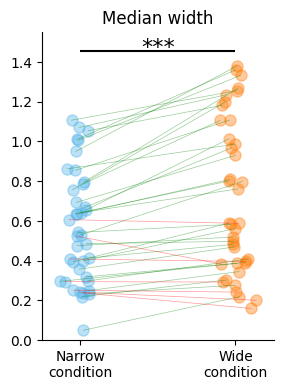

In [616]:
# Compute per-subject medians for 'mu' in 'wide' and 'narrow'
#nmax = 40
this_df = dfest14
#ind = this_df == this_df # true everywhere (except nans but idc)
#ind = (this_df.mu.narrow>=0) & (this_df.mu.wide>=0) & (this_df.mu.narrow<=nmax) & (this_df.mu.wide<=nmax)
sd_wide_medians = this_df.sd_wide.groupby('subject').median()
sd_narrow_medians = this_df.sd_narrow.groupby('subject').median()
print( (sd_wide_medians >= sd_narrow_medians).sum(), 'subjects have median $\sigma$ in Wide condition larger than in Narrow condition' )
print( (sd_wide_medians <  sd_narrow_medians).sum(), 'subjects have median $\sigma$ in Wide condition smaller than in Narrow condition' )

fig, ax = plt.subplots(figsize=(3, 4))
paired_strip_plot(ax, x1=1, x2=2, y1=sd_narrow_medians, y2=sd_wide_medians, 
                  col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE], color_incr_line='g', color_decr_line='r',)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
ax.set_title("Median width")
ax.set_xlim(0.75, 2.25)
ax.set_ylim(0.,1.55)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# paired test
paired_test = pg.ttest(sd_narrow_medians, sd_wide_medians, paired=True)
print(f"Paired t-test: t = {paired_test['T'][0]:.3f}, p = {paired_test['p-val'][0]:.3g}, dof = {paired_test['dof'][0]}")
# add a horizontal line above the two clouds of dots, with tree stars, reflecting the p-value
ax.hlines(0.94*ax.get_ylim()[1], 1, 2, color='k', lw=1.5)
ax.text(1.5, 0.95*ax.get_ylim()[1], '***', ha='center', va='center', fontsize=16, color='k')

#fig.savefig('figures/delta_median_sd.pdf', bbox_inches='tight')

22.544465843434917 % of voxels have $\sigma_{w} - \sigma_{n} < 0$


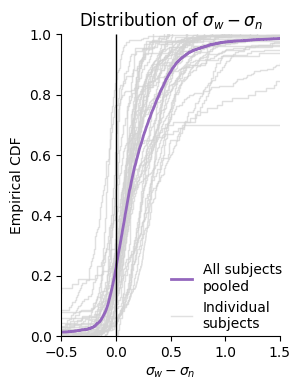

In [546]:
fig, ax = plt.subplots(figsize=(3, 4))
all_data = []
this_df = dfest14
#ind = (df3.mu.narrow>=10) & (df3.mu.wide>=10) #& (df3.mu.narrow<=40) & (df3.mu.wide<=40)
qty = 'delta' # delta or ratio
subjects = this_df.index.get_level_values('subject').unique()
for subject in subjects:
    data = this_df.xs(subject, level='subject')[(f'sd_{qty}_wn')]
    all_data.append(pd.DataFrame({f'sd_{qty}_wn': data.dropna(), 'subject': subject}))
all_data = pd.concat(all_data, ignore_index=True)
# Plot the CDFs for each subject in light grey (no hue, loop over subjects)
c_ind = 'lightgrey'
for subject in subjects:
    subj_data = all_data[all_data['subject'] == subject]
    sns.ecdfplot(data=subj_data, x=f'sd_{qty}_wn', color=c_ind, linewidth=1, alpha=0.7, legend=False)

# Plot the pooled CDF (all subjects together) in a bold color
sns.ecdfplot(data=all_data, x=f'sd_{qty}_wn', color=FOURTH_COLOR, linewidth=2, label='All subjects pooled')
print( (all_data.sd_delta_wn<0).mean() * 100, '% of voxels have $\sigma_{w} - \sigma_{n} < 0$' )

#plt.title("Empirical CDF of $\sigma_{w} - \sigma_{n}$")
plt.gca().set_title("Distribution of $\sigma_{w} - \sigma_{n}$")
plt.xlabel('$\sigma_{w} - \sigma_{n}$')
plt.ylabel('Empirical CDF')
plt.legend(handles=[plt.Line2D([0], [0], color=FOURTH_COLOR, lw=2, label='All subjects\npooled'),
                    plt.Line2D([0], [0], color=c_ind, alpha=.7, lw=1, label='Individual\nsubjects')], loc=(.475,0), handlelength=1.5)
plt.tight_layout()
if qty=='delta':
    plt.xlim(-.5, 1.5)
else:
    plt.xlim(0.5, 3.)
    #plt.vlines(np.sqrt(2), 0, 1, color='black', linestyle='-', lw=1)
plt.vlines(0 if qty=='delta' else 1, 0, 1, color='black', linestyle='-', lw=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#fig.savefig('figures/cdf_delta_sd.pdf', bbox_inches='tight')

2.435708621275632% of the data not shown in the figure (σ>3)


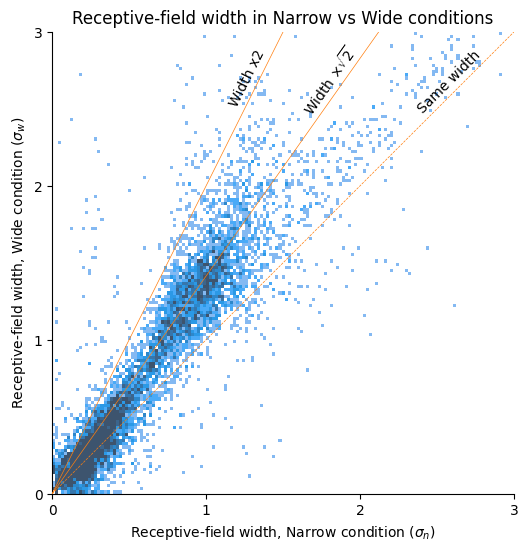

In [548]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal') #, adjustable='box')
#nmax = 40
this_df = dfest14
ind = this_df == this_df # true everywhere (except nans but idc)
#ind = (this_df.mu.narrow>=10) & (this_df.mu.wide>=10) #& (this_df.mu.narrow<=nmax) & (this_df.mu.wide<=nmax)
#sns.displot(this_df[ind].mu, x='narrow', y='wide', kind='hist', bins=41)
sns.histplot(this_df[ind], x='sd_narrow', y='sd_wide', bins=801, ax=ax, pmax=.6, alpha=1)
#sns.scatterplot(this_df[ind].mu, x='narrow', y='wide', color='C0', s=1, ax=ax, alpha=1, ec='none')
#sns.displot(this_df[ind].mu, x='narrow', y='wide', kind='kde', bins=41, ax=ax)
#sns.kdeplot(this_df[ind].mu, x='narrow', y='wide', ax=ax, levels=5, color='lightgrey', thresh=.1, linewidth=1, zorder=-1000)
σmax = 3
print( f'{( (this_df[ind].sd_narrow > σmax) | (this_df[ind].sd_wide > σmax) ).mean()*100}% of the data not shown in the figure (σ>{σmax})' )
ax.set_xlim(0,σmax); ax.set_ylim(0,σmax)
ax.axline((0,0), slope=1, color='C1', ls='--', lw=.5, zorder=100)
ax.plot([0, σmax], [0, 2*σmax], c='C1', lw=.5, zorder=100)
ax.plot([0, σmax], [0, np.sqrt(2)*σmax], c='C1', lw=.5, zorder=100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Receptive-field width, Narrow condition ($\sigma_n$)')
ax.set_ylabel('Receptive-field width, Wide condition ($\sigma_w$)')
ax.set_title('Receptive-field width in Narrow vs Wide conditions')
ax.text(2.8, 2.8+.1, 'Same width', fontsize=10, ha='right', va='top', rotation=45)
ax.text(1.4, 2.8+.1, 'Width x2', fontsize=10, ha='right', va='top', rotation=63.43)
ax.text(2., 2.*np.sqrt(2)+.1, 'Width $\\times\sqrt{2}$', fontsize=10, ha='right', va='top', rotation=54.74)
ax.set_yticks([0, 1, 2, 3])
ax.set_xticks([0, 1, 2, 3]);
# #ax.grid()
#fig.savefig('figures/sd_wide_vs_narrow.pdf', bbox_inches='tight')

KstestResult(statistic=0.10479211510139345, pvalue=1.3449304601018732e-42, statistic_location=0.1892282093172289, statistic_sign=-1)
KstestResult(statistic=0.07658321060382917, pvalue=6.262444195901533e-23, statistic_location=0.19185430278445154, statistic_sign=-1)


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,5.658235,8826,two-sided,1.577141e-08,"[0.05, 0.1]",0.074875,1.039e+05,1.0


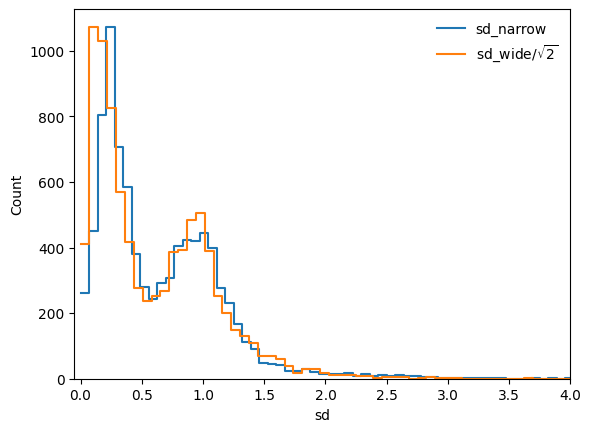

In [550]:
cu = False
dfx14 = dfest14
sns.histplot( dfx14.sd_narrow, label='sd_narrow', cumulative=cu, element='step', fill=False);
plt.gca().set_xlabel('sd')
sns.histplot( dfx14.sd_wide/np.sqrt(2), label='sd_wide$/\sqrt{2}$', cumulative=cu, element='step', fill=False)
plt.xlim(-.05,4); plt.legend()
print( stats.ks_2samp(dfx14.sd_narrow, dfx14.sd_wide/np.sqrt(2)))
print( stats.ks_2samp(dfx14.sd_narrow, dfx14.sd_wide/1.287794))
pg.ttest(x=dfx14.sd_narrow, y=dfx14.sd_wide/np.sqrt(2), paired=True)

8827


Text(0.5, 0, 'Receptive-field width (σ)')

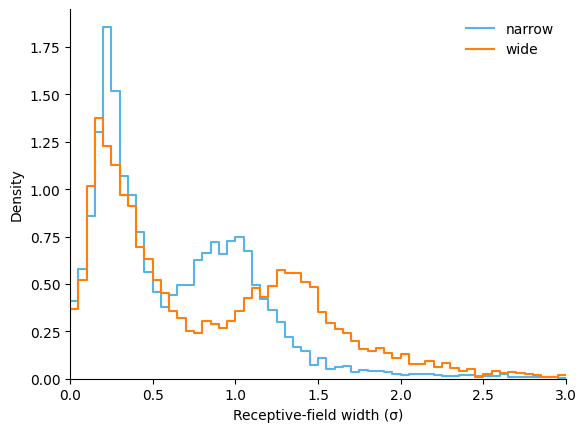

In [551]:
dx = 0.05
bins = np.arange(0., 3.+.000001, dx)
wscale = 1. #/np.sqrt(2)
# ind  = such that dfest14[ind] is dfest14
ind = dfest14.sd_narrow.notna()
#ind = dfest14.mu.narrow <= 10
print(sum(ind))
sns.histplot(dfest14[ind].sd_narrow, element='step', fill=False, color=COLORS_COND[NARROW], stat='density', label=NARROW,  binrange=(0, 3), bins=bins)
sns.histplot(dfest14[ind].sd_wide*wscale, element='step', fill=False, color=COLORS_COND[WIDE],   stat='density', label=WIDE,   binrange=(0, 3), bins=bins)
plt.legend()
sns.despine()
plt.xlim(0, 3)
plt.xlabel('Receptive-field width (σ)')

In [552]:
def odr_1dregression(x, y, data=None):
    if data is None:
        dat = odr.Data(x, y)
    else:
        dat = odr.Data(data[x], data[y])
    myodr = odr.ODR(dat, odr.unilinear, beta0=[1., 0.]) # start point = identity
    res = myodr.run()
    return res

def odr_pred(odr_res, x):
    B = odr_res.beta
    return B[0]*np.asarray(x) + B[1]

AttributeError: 'DataFrame' object has no attribute 'mu'

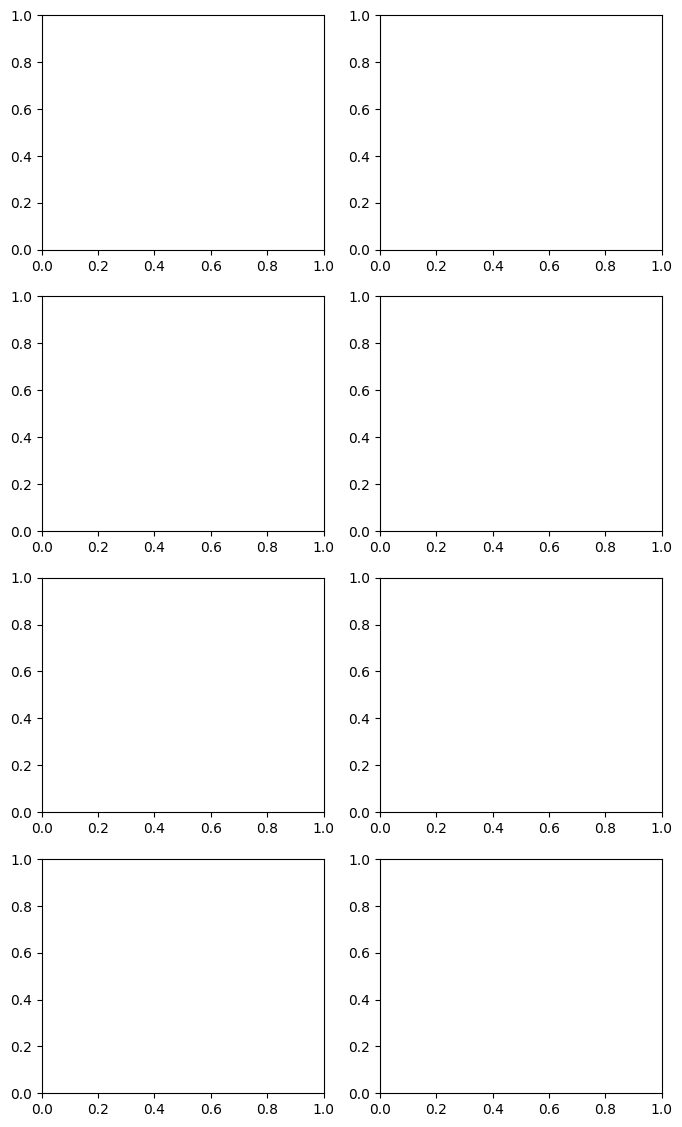

In [553]:
fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(8, 14))

# sigma vs sigma when mu_narrow <= 10
ind = (dfest14.mu.narrow<=10) & (dfest14.sd.narrow<=3) & (dfest14.sd.wide<=3)
print(sum(ind))
ax = axs[0,0]
ax.set_title('$\mu_{narrow} \leq 10$')
ax.set_xlabel('Receptive-field width (σ)')
dx = 0.05
bins = np.arange(0., 3.+.000001, dx)
sns.histplot(dfest14[ind].sd.narrow, element='step', fill=False, color=COLORS_COND[NARROW], stat='density', label=NARROW,  binrange=(0, 3), bins=bins, ax=ax)
sns.histplot(dfest14[ind].sd.wide,   element='step', fill=False, color=COLORS_COND[WIDE],   stat='density', label=WIDE,   binrange=(0, 3), bins=bins, ax=ax)
ax = axs[0,1]
sns.regplot(x=dfest14.sd.narrow[ind], y=dfest14.sd.wide[ind], scatter_kws={'s':1, 'alpha':.3}, ax=ax)
ax.axline((0, 0), slope=1, color='lightgrey', linestyle='-')
#ax.axline((0,0), slope=1.3, color='pink', linestyle='-', lw=1)
res = odr_1dregression(dfest14[ind].sd.narrow, dfest14[ind].sd.wide); print(res.beta)
ax.plot( [0,3], odr_pred(res, [0,3]), color='pink', linestyle='-', lw=1)
ax.set_xlabel('$\sigma_n$'); ax.set_ylabel('$\sigma_w$')
ax.set_xlim(0,3); ax.set_ylim(0,3)

# sigma vs sigma when mu_narrow > 10
ind = (dfest14.mu.narrow>10) & (dfest14.sd.narrow<=3) & (dfest14.sd.wide<=3)
print(sum(ind))
ax = axs[1,0]
ax.set_title('$\mu_{narrow} > 10$')
ax.set_xlabel('Receptive-field width (σ)')
dx = 0.05
bins = np.arange(0., 3.+.000001, dx)
sns.histplot(dfest14[ind].sd.narrow, element='step', fill=False, color=COLORS_COND[NARROW], stat='density', label=NARROW,  binrange=(0, 3), bins=bins, ax=ax)
sns.histplot(dfest14[ind].sd.wide*wscale, element='step', fill=False, color=COLORS_COND[WIDE],   stat='density', label=WIDE,   binrange=(0, 3), bins=bins, ax=ax)
ax = axs[1,1]
sns.regplot(x=dfest14.sd.narrow[ind], y=dfest14.sd.wide[ind], scatter_kws={'s':1, 'alpha':.3}, ax=ax)
ax.axline((0, 0), slope=1, color='lightgrey', linestyle='-')
#ax.axline((0,0), slope=1.3, color='pink', linestyle='-', lw=1)
#ax.plot([.5, 2.], [.5, .5+1.5*2], color='pink', linestyle='-', lw=1)
res = odr_1dregression(dfest14[ind].sd.narrow, dfest14[ind].sd.wide); print(res.beta)
ax.plot( [0,3], odr_pred(res, [0,3]), color='pink', linestyle='-', lw=1)
ax.set_xlabel('$\sigma_n$'); ax.set_ylabel('$\sigma_w$')
ax.set_xlim(0,3); ax.set_ylim(0,3)

# sigma vs sigma when mu_narrow > 10 and sd_narrow >= .5
ind = (dfest14.mu.narrow>10) & (dfest14.sd.narrow>=.5) &  (dfest14.sd.narrow<=3) & (dfest14.sd.wide<=3)
print(sum(ind))
ax = axs[2,0]
ax.set_title('$\mu_{narrow} > 10$ and $\sigma_n \geq 0.5$')
ax.set_xlabel('Receptive-field width (σ)')
dx = 0.05
bins = np.arange(0., 3.+.000001, dx)
sns.histplot(dfest14[ind].sd.narrow, element='step', fill=False, color=COLORS_COND[NARROW], stat='density', label=NARROW,  binrange=(0, 3), bins=bins, ax=ax)
sns.histplot(dfest14[ind].sd.wide,   element='step', fill=False, color=COLORS_COND[WIDE],   stat='density', label=WIDE,   binrange=(0, 3), bins=bins, ax=ax)
ax = axs[2,1]
sns.regplot(x=dfest14.sd.narrow[ind], y=dfest14.sd.wide[ind], scatter_kws={'s':1, 'alpha':.3}, ax=ax)
ax.axline((0, 0), slope=1, color='lightgrey', linestyle='-')
#ax.axline((0,0), slope=1.3, color='pink', linestyle='-', lw=1)
#ax.plot([.5, 2.], [.5, .5+1.5*2], color='pink', linestyle='-', lw=1)
ax.set_xlabel('$\sigma_n$'); ax.set_ylabel('$\sigma_w$')
res = odr_1dregression(dfest14[ind].sd.narrow, dfest14[ind].sd.wide); print(res.beta)
ax.plot( [0,3], odr_pred(res, [0,3]), color='pink', linestyle='-', lw=1)
ax.set_xlim(0,3); ax.set_ylim(0,3)

# sigma vs sigma when mu_narrow > 10 and sd_narrow <= .5
ind = (dfest14.mu.narrow>10) & (dfest14.sd.narrow<=.5) &  (dfest14.sd.wide<=3)
print(sum(ind))
ax = axs[3,0]
ax.set_title('$\mu_{narrow} > 10$ and $\sigma_n \leq 0.5$')
ax.set_xlabel('Receptive-field width (σ)')
dx = 0.05
bins = np.arange(0., 3.+.000001, dx)
sns.histplot(dfest14[ind].sd.narrow, element='step', fill=False, color=COLORS_COND[NARROW], stat='density', label=NARROW,  binrange=(0, 3), bins=bins, ax=ax)
sns.histplot(dfest14[ind].sd.wide,   element='step', fill=False, color=COLORS_COND[WIDE],   stat='density', label=WIDE,   binrange=(0, 3), bins=bins, ax=ax)
ax = axs[3,1]
sns.regplot(x=dfest14.sd.narrow[ind], y=dfest14.sd.wide[ind], scatter_kws={'s':1, 'alpha':.3}, ax=ax)
ax.axline((0, 0), slope=1, color='lightgrey', linestyle='-')
#ax.axline((0,0), slope=1.3, color='pink', linestyle='-', lw=1)
#ax.plot([.5, 2.], [.5, .5+1.5*2], color='pink', linestyle='-', lw=1)
ax.set_xlabel('$\sigma_n$'); ax.set_ylabel('$\sigma_w$')
res = odr_1dregression(dfest14[ind].sd.narrow, dfest14[ind].sd.wide); print(res.beta)
ax.plot( [0,3], odr_pred(res, [0,3]), color='pink', linestyle='-', lw=1)
ax.set_xlim(0,3); ax.set_ylim(0,3)

fig.tight_layout()

[-0.04396433  1.54481736]
[0.00713726 0.16056435]


(0.0, 80.0)

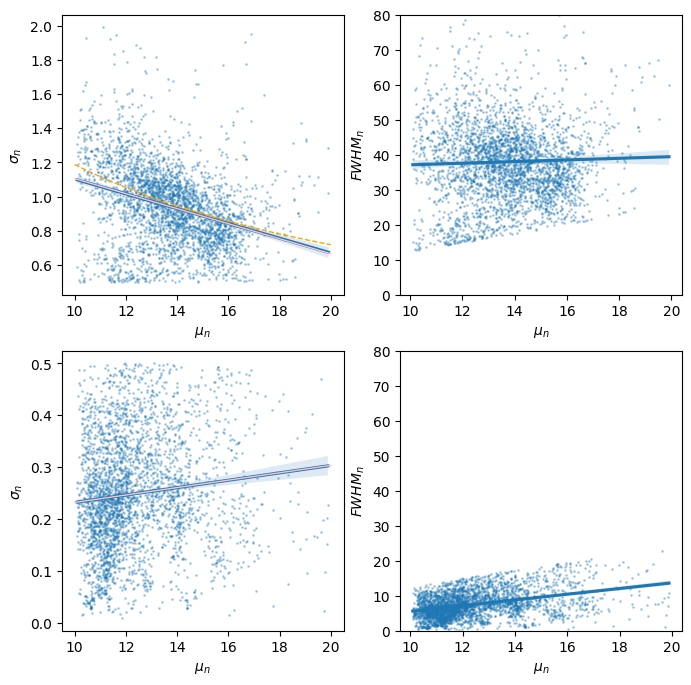

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

ind = (dfest14.mu.narrow>=10.1) & (dfest14.mu.narrow<=20) & (dfest14.sd.narrow<=2) & (dfest14.sd.narrow>=.5)
ax = axs[0,0]
sns.regplot(x=dfest14.mu.narrow[ind], y=dfest14.sd.narrow[ind], scatter_kws={'s':1, 'alpha':.3}, ax=ax)
ax.set_xlabel('$\mu_n$'); ax.set_ylabel('$\sigma_n$')
res = odr_1dregression(dfest14[ind].mu.narrow, dfest14[ind].sd.narrow); print(res.beta)
ax.plot( [10,20], odr_pred(res, [10,20]), color='pink', linestyle='-', lw=1)
xxx = np.linspace(10, 20, 100)
ax.plot(xxx, np.arcsinh(38/(2*xxx))/np.sqrt(2*np.log(2)), color='orange', linestyle='--', lw=1) # sigma if fwhm is constant
ax = axs[0,1]
fwhms = 2 * dfest14.mu.narrow[ind] * np.sinh( dfest14.sd.narrow[ind] * np.sqrt(2 * np.log(2)) )
sns.regplot(x=dfest14.mu.narrow[ind], y=fwhms, scatter_kws={'s':1, 'alpha':.3}, ax=ax)
ax.set_xlabel('$\mu_n$'); ax.set_ylabel('$FWHM_n$')
# res = odr_1dregression(dfest14[ind].mu.narrow, fwhms); print(res.beta); res.pprint()
# ax.plot( [10,20], odr_pred(res, [10,20]), color='pink', linestyle='-', lw=1)
ax.set_ylim(0,80)


ax = axs[1,0]
ind = (dfest14.mu.narrow>=10.1) & (dfest14.mu.narrow<=20) & (dfest14.sd.narrow<=.5)
sns.regplot(x=dfest14.mu.narrow[ind], y=dfest14.sd.narrow[ind], scatter_kws={'s':1, 'alpha':.3}, ax=ax)
ax.set_xlabel('$\mu_n$'); ax.set_ylabel('$\sigma_n$')
res = odr_1dregression(dfest14[ind].mu.narrow, dfest14[ind].sd.narrow); print(res.beta)
ax.plot( [10,20], odr_pred(res, [10,20]), color='pink', linestyle='-', lw=1)
# xxx = np.linspace(10, 20, 100)
# ax.plot(xxx, np.arcsinh(38/(2*xxx))/np.sqrt(2*np.log(2)), color='orange', linestyle='--', lw=1)
ax = axs[1,1]
fwhms = 2 * dfest14.mu.narrow[ind] * np.sinh( dfest14.sd.narrow[ind] * np.sqrt(2 * np.log(2)) )
sns.regplot(x=dfest14.mu.narrow[ind], y=fwhms, scatter_kws={'s':1, 'alpha':.3}, ax=ax)
ax.set_xlabel('$\mu_n$'); ax.set_ylabel('$FWHM_n$')
ax.set_ylim(0,80)

In [264]:
np.arcsinh(5.) / np.sqrt(2*np.log(2))

1.9640042950648147

# Model 15 (r_sd)

In [620]:
# Model 15 is better
# print(rez[14].mean(), rez[15].mean())
# print( pg.ttest(x=rez[14], y=rez[15], paired=True) )
# Model 15 is better than 14
print(rez_est[14].mean(), rez_est[15].mean())
pg.ttest(x=rez_est[14], y=rez_est[15], paired=True)
# Model 15 is better than 4
print(rez_est[4].mean(), rez_est[15].mean())
pg.ttest(x=rez_est[4], y=rez_est[15], paired=True)

0.2859119711697223 0.3155111920740877
0.30312953705811424 0.3155111920740877


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-2.414218,38,two-sided,0.020693,"[-0.02, -0.0]",0.070778,2.226,0.071533


In [621]:
# dfest15 = index_filter(pars, type='estimates', smoothed=True, model_label=15)
# dfest15 = dfest15[ dfest15[('cvr2', 'nan')] > 0] #.drop(columns='alpha')
# dfest15.index.rename(['subject', 'voxel'], inplace=True)
# dfest15[('sd','ratio_wn')] = dfest15.sd.wide / dfest15.sd.narrow
# dfest15

# dfgt15 = index_filter(pars, type='ground_truth', smoothed=True, model_label=15)
# dfgt15 = dfgt15[ dfgt15[('cvr2', 'nan')] > 0] #.drop(columns='alpha')
# dfgt15.index.rename(['subject', 'voxel'], inplace=True)
# dfgt15[('sd','ratio_wn')] = dfgt15.sd.wide / dfgt15.sd.narrow
# dfgt15

dfest15 = index_filter(pars, response_fit=False, model_label=15)
dfest15 = dfest15[ dfest15.cvr2> 0]
dfest15['sd_ratio_wn'] = dfest15.sd_wide / dfest15.sd_narrow
dfest15

dfgt15 = index_filter(pars, response_fit=True, model_label=15)
dfgt15 = dfgt15[ dfgt15.cvr2> 0] #.drop(columns='alpha')
dfgt15['sd_ratio_wn'] = dfgt15.sd_wide / dfgt15.sd_narrow
dfgt15

loglikelihood      cvr2          aic          bic  mu_narrow    mu_wide  sd_narrow   sd_wide  delta_wide_narrow  delta_wide_wide  amplitude_narrow  \
subject voxel                                                                                                                                                       
1       13       -627.265372  0.005674  1266.530744  1291.573461  12.315397  14.630795   0.326917  0.371576                2.0              2.0          0.525354   
        16       -547.407109  0.002421  1106.814218  1131.856935  11.754172  13.508345   0.340996  0.387579                2.0              2.0          0.406663   
        17       -570.199773  0.000316  1152.399545  1177.442262  10.001604  10.003208   0.431897  0.490898                2.0              2.0          0.469995   
        18       -532.113315  0.000222  1076.226630  1101.269346  11.610137  13.220274   0.372982  0.423934                2.0              2.0          0.426717   
        19       -473.539647  0.011969   959.079294   984.122011  10.018812  10.037624   0.417084  0.474061                2.0              2.0          0.413217   
...                      ...       ...          ...          ...        ...        ...        ...       ...                ...              ...               ...   
41      684      -223.708018  0.018472   459.416037   484.458753  14.725738  19.451475   0.558743  0.777786                2.0              2.0          0.633661   
        686      -440.539931  0.008596   893.079862   918.122579   9.999515   9.999515   0.355585  0.494985                2.0              2.0          0.323596   
        687      -427.952816  0.014609   867.905632   892.948349   9.999698   9.999698   0.396009  0.551256                2.0              2.0          0.348727   
        689      -282.390773  0.012179   576.781546   601.824263  13.376223  16.752445   0.767240  1.068020                2.0              2.0          0.806261   
        691      -295.128561  0.002116   602.257123   627.299840  13.527811  17.055622   0.761653  1.060243                2.0              2.0          0.749757   

               amplitude_wide  baseline_narrow  baseline_wide        r2  sd_ratio_wn  
subject voxel                                                                         
1       13           0.525354        -0.488440      -0.488440  0.028403     1.136609  
        16           0.406663        -0.372227      -0.372227  0.023547     1.136609  
        17           0.469995        -0.501347      -0.501347  0.023005     1.136609  
        18           0.426717        -0.250381      -0.250381  0.025871     1.136609  
        19           0.413217        -0.354132      -0.354132  0.026788     1.136609  
...                       ...              ...            ...       ...          ...  
41      684          0.633661        -0.313933      -0.313933  0.032482     1.392029  
        686          0.323596        -0.239805      -0.239805  0.024646     1.392029  
        687          0.348727        -0.089988      -0.089988  0.028944     1.392029  
        689          0.806261        -0.369694      -0.369694  0.027366     1.392029  
        691          0.749757        -0.424592      -0.424592  0.021451     1.392029  

[9738 rows x 16 columns]

In [556]:
rez_est.loc[:,[14,15]].mean()

model_label
14    0.285912
15    0.315511
dtype: float64

In [558]:
print( dfest15.sd_ratio_wn.groupby('subject').first().mean(), dfest15.sd_ratio_wn.groupby('subject').first().std() )
print( dfest15.sd_ratio_wn.groupby('subject').first().median() )
print( dfgt15.sd_ratio_wn.groupby('subject').first().mean(), dfgt15.sd_ratio_wn.groupby('subject').first().std() )
print( dfgt15.sd_ratio_wn.groupby('subject').first().median() )
np.sqrt(2)

1.2877944588717374 0.24858483811582568
1.309339674301479
1.304754457830862 0.24664963098064527
1.321174469451246


1.4142135623730951

In [622]:
# test if the mean is significantly different from 1
print( stats.ttest_1samp(dfest15.sd_ratio_wn.groupby('subject').first(), 1) )
#print( pg.ttest(x=dfest15.sd_ratio_wn.groupby('subject').first(), y=1) )
print( stats.ttest_1samp(dfgt15.sd_ratio_wn.groupby('subject').first(), 1) )

TtestResult(statistic=7.2300299295274275, pvalue=1.2036774014055539e-08, df=38)
TtestResult(statistic=7.716172011244838, pvalue=2.6987830478430184e-09, df=38)


In [560]:
# test if the mean is significantly different from sqrt(2)
print( stats.ttest_1samp(dfest15.sd_ratio_wn.groupby('subject').first(), np.sqrt(2) ) )
print( stats.ttest_1samp(dfgt15.sd_ratio_wn.groupby('subject').first(), np.sqrt(2) ) )
# ratio_wn_gt15 = dfgt15.sd_ratio_wn.groupby('subject').first()
# ratio_wn_est15 = dfest15.sd_ratio_wn.groupby('subject').first()
# Using bootstrap to test if the median is significantly different from sqrt(2) ?

TtestResult(statistic=-3.1759259909385356, pvalue=0.002961285029114354, df=38)
TtestResult(statistic=-2.77142879174373, pvalue=0.008593168432867927, df=38)


In [623]:
# test if the mean is significantly different from 2
print( stats.ttest_1samp(dfest15.sd_ratio_wn.groupby('subject').first(), 2) )
print( stats.ttest_1samp(dfgt15.sd_ratio_wn.groupby('subject').first(), 2) )

TtestResult(statistic=-17.892169983118098, pvalue=4.182052724464494e-20, df=38)
TtestResult(statistic=-17.60313608408512, pvalue=7.276866362959838e-20, df=38)


TtestResult(statistic=7.2300299295274275, pvalue=1.2036774014055539e-08, df=38)


Text(0.5, 1.0, 'Sd ratio_wn parameter (Model 15)')

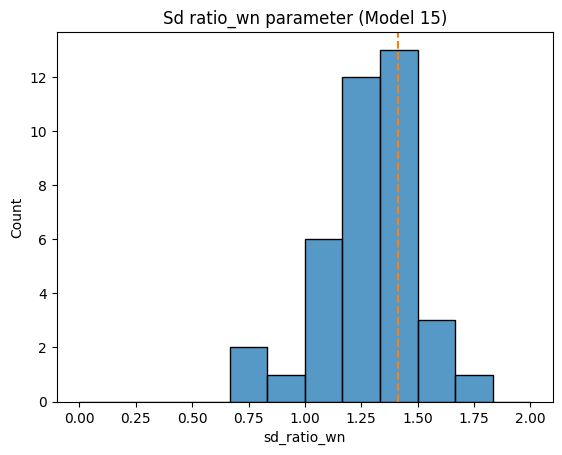

In [562]:
sns.histplot( dfgt15.sd_ratio_wn.groupby('subject').first(), bins=np.linspace(0,2,13))
plt.axvline(np.sqrt(2), ls='--', color='C1')
print( stats.ttest_1samp( dfest15.sd_ratio_wn.groupby('subject').first(), popmean=1) )
#stats.ttest_1samp( dfest15.sd_ratio_wn.groupby('subject').first(), popmean=np.sqrt(2))
plt.title('Sd ratio_wn parameter (Model 15)')

In [564]:
print( dfest15.sd_ratio_wn.groupby('subject').first().mean(), dfgt15.sd_ratio_wn.groupby('subject').first().mean() )
print( dfest15.sd_ratio_wn.groupby('subject').first().median(), dfgt15.sd_ratio_wn.groupby('subject').first().median() )

1.2877944588717374 1.304754457830862
1.309339674301479 1.321174469451246


1.2877944588717374


count    39.000000
mean      1.287794
std       0.248585
min       0.745288
25%       1.152647
50%       1.309340
75%       1.461959
max       1.722680
Name: sd_ratio_wn, dtype: float64

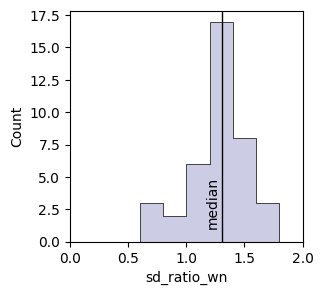

In [565]:
fig, ax = plt.subplots(figsize=(3, 3))
ratio_sd = dfest15.sd_ratio_wn.groupby('subject').first()
print(ratio_sd.mean())
dw = .2
bins = np.arange(-dw, ratio_sd.max()+dw, dw)
this_color = 1 - .4*( 1 -  np.array( plt.cm.Spectral_r(.02)[:3] ) ) # equivalent to the color with some alpha, on white. (With cB = 1 - alpha*(1-cA), color cB is like (cA,alpha) on white.)
sns.histplot(ratio_sd, ax=ax, bins=bins, color=this_color, linewidth=.5, element='step', ec='k') # bins=bins, 
ax.set_xlim(0,2)
ax.axvline(ratio_sd.median(), color='k', linestyle='-', lw=1)
ax.text(ratio_sd.median()-.02, 3, 'median', rotation=90, va='center', ha='right')
ratio_sd.describe()

In [625]:
index_filter( old_compare_res_est, Model1=[4, 14, 15], Model2=31)

,Mean Model 1,Mean Model 2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model1,,,,,,,,,,
4,0.301325,0.324579,-5.058881,38,two-sided,1.104442e-05,"[-0.03, -0.01]",0.132543,1842.339,0.127284
14,0.285912,0.324579,-10.475808,38,two-sided,9.233215e-13,"[-0.05, -0.03]",0.220234,8.915e+09,0.268357
15,0.315511,0.324579,-5.079256,38,two-sided,1.036221e-05,"[-0.01, -0.01]",0.051364,1953.932,0.061278


In [626]:
index_filter( compare_res_est, Model1=[4, 14, 15], Model2=31)

,Mean Model 1,Mean Model 2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
Model1,,,,,,,,,,
4,0.303130,0.324579,-4.936446,38,two-sided,1.618874e-05,"[-0.03, -0.01]",0.122494,1295.319,0.115748
14,0.285912,0.324579,-10.475808,38,two-sided,9.233215e-13,"[-0.05, -0.03]",0.220234,8.915e+09,0.268357
15,0.315511,0.324579,-5.079256,38,two-sided,1.036221e-05,"[-0.01, -0.01]",0.051364,1953.932,0.061278


0.20489470688673878% of the data not shown in the figure (σ>3)


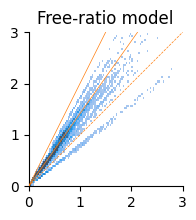

In [567]:
fig, ax = plt.subplots(figsize=(2, 2))
ax.set_aspect('equal') #, adjustable='box')
nmax = 40
this_df = dfest15
ind = this_df == this_df # true everywhere (except nans but idc)
#ind = (this_df.mu.narrow>=0) & (this_df.mu.wide>=0) & (this_df.mu.narrow<=nmax) & (this_df.mu.wide<=nmax)
#sns.displot(this_df[ind].sd, x='narrow', y='wide', kind='hist', bins=41)
sns.histplot(this_df[ind], x='sd_narrow', y='sd_wide', bins=161, ax=ax, pmax=.6, alpha=1)
#sns.scatterplot(this_df[ind].sd, x='narrow', y='wide', color='C0', s=1, ax=ax, alpha=1, ec='none')
#sns.displot(this_df[ind].sd, x='narrow', y='wide', kind='kde', bins=41, ax=ax)
#sns.kdeplot(this_df[ind].sd, x='narrow', y='wide', ax=ax, levels=5, color='lightgrey', thresh=.1, linewidth=1, zorder=-1000)
σmax = 3
print( f'{( (this_df[ind].sd_narrow > σmax) | (this_df[ind].sd_wide > σmax) ).mean()*100}% of the data not shown in the figure (σ>{σmax})' )
ax.set_xlim(0,σmax); ax.set_ylim(0,σmax)
ax.axline((0,0), slope=1, color='C1', ls='--', lw=.5, zorder=100)
ax.plot([0, σmax], [0, 2*σmax], c='C1', lw=.5, zorder=100)
ax.plot([0, σmax], [0, np.sqrt(2)*σmax], c='C1', lw=.5, zorder=100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.set_title('Free-ratio model')
ax.set_yticks([0, 1, 2, 3])
ax.set_xticks([0, 1, 2, 3]);
#ax.get_xticklabels()[-1].set_ha('right')
#ax.text(38, 38+1, 'No shift', fontsize=10, ha='right', va='top', rotation=45)
#ax.text(24, 38+1, 'Efficient shift', fontsize=10, ha='right', va='top', rotation=63.43)
#ax.grid()
#fig.savefig('figures/sd_wide_vs_narrow_freeratio.pdf', bbox_inches='tight')

# Figure - widths

In [568]:
mean_ratio_sd = dfest15.sd_ratio_wn.groupby('subject').first().mean()
mean_ratio_sd

1.2877944588717374

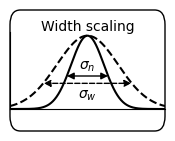

In [569]:
##### Icon
icon_width = 0.2; icon_height = .08
fig, icon_ax = plt.subplots(figsize=(2,1))
#inset_ax = fig.add_axes([inset_width/2, 0.8, inset_width, inset_width], )
xxs = np.linspace(0, 3, 1000)
icon_ax.plot(xxs, np.exp(-(xxs-1.5)**2/.2), color='k') 
icon_ax.plot(xxs, np.exp(-(xxs-1.5)**2/.7), color='k', linestyle='--')
#icon_ax.arrow(x=1, y=0.35, dx=1, dy=0, color='k', lw=1, head_width=0.1, head_length=0.1, length_includes_head=True, zorder=100, )
icon_ax.annotate("", xytext=(1.05, .45), xy=(1.95, .45), arrowprops=dict(arrowstyle="<|-|>", color='k'))
icon_ax.annotate("", xytext=(.6, .35), xy=(2.4, .35), arrowprops=dict(arrowstyle="<|-|>", ls='--', color='k'))
icon_ax.set_ylim(0, None)
icon_ax.set_xlim(0, 3)
icon_ax.set_yticks([])
icon_ax.set_xticks([])
#icon_ax.set_xticklabels(['$\sigma_n$', '$\sigma_w$'])
icon_ax.text(1.5, .475, '$\sigma_n$', fontsize=10, ha='center', va='bottom')
icon_ax.text(1.5, .275, '$\sigma_w$', fontsize=10, ha='center', va='top')
icon_ax.tick_params(axis='x', length=0, pad=0.5, labelsize=10)
bb = mtransforms.Bbox([[0., -.3], [3, 1.35]])
fancy = FancyBboxPatch(bb.p0, bb.width, bb.height, clip_on=False, facecolor="w", boxstyle="round,pad=0,rounding_size=0.2") # zorder=1000000)
icon_ax.add_patch(fancy)
icon_ax.set_title('Width scaling', fontsize=10, y=.9, ha='center')
sns.despine(ax=icon_ax)
fig.savefig('figures/icon_width_scaling.pdf', bbox_inches='tight')

In [576]:
ratio_sd.mean(), ratio_sd.median()

(1.304754457830862, 1.321174469451246)

2.435708621275632% of the data not shown in the figure (σ>3)
32 subjects have median $\sigma$ in Wide condition larger than in Narrow condition
7 subjects have median $\sigma$ in Wide condition smaller than in Narrow condition
Paired t-test: t = -6.268, p = 2.44e-07, dof = 38
22.544465843434917 % of voxels have $\sigma_{w} - \sigma_{n} < 0$
1.2877944588717374


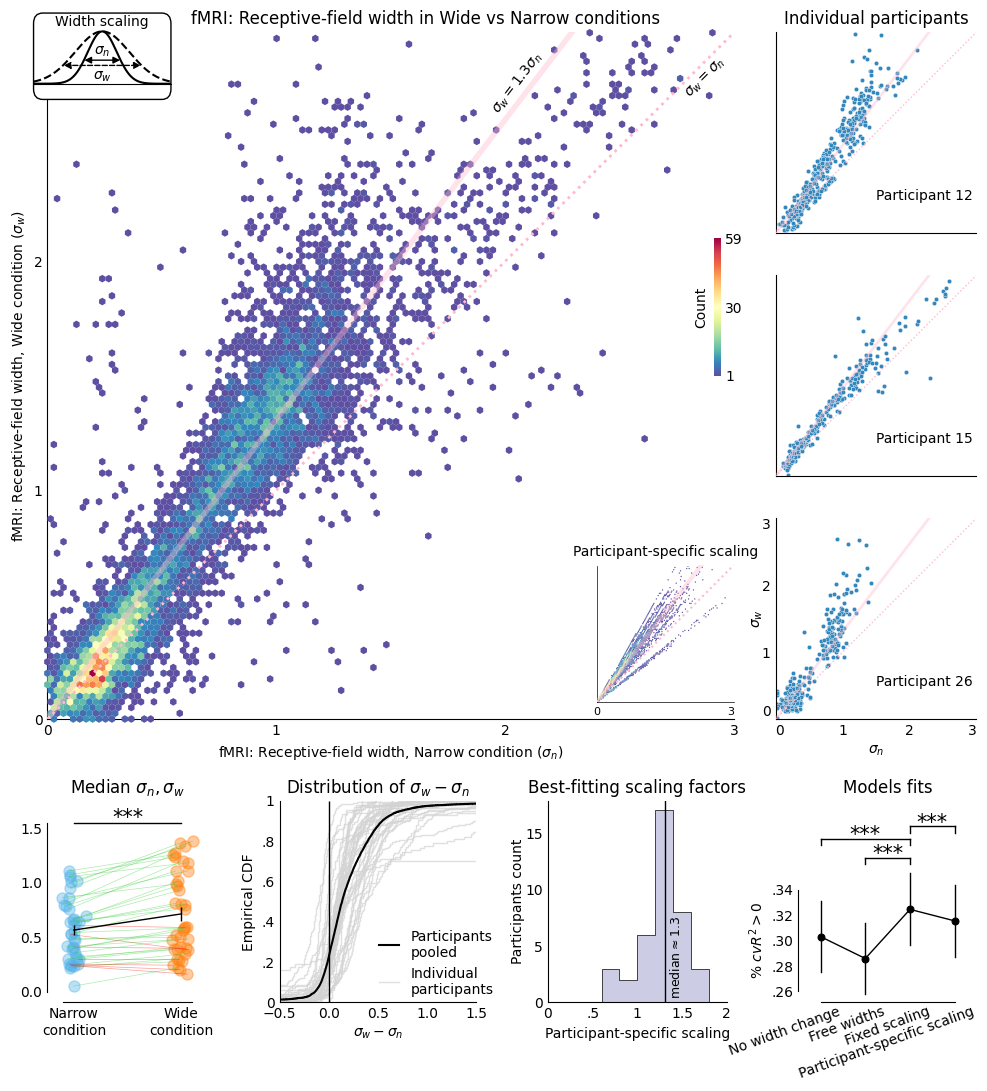

In [581]:
nrows = 4
WITH_GROUND_TRUTH = False
this_df14 = dfgt14 if WITH_GROUND_TRUTH else dfest14
this_df15 = dfgt15 if WITH_GROUND_TRUTH else dfest15
#fig = plt.figure(figsize=(12, nrows*3))
gs = plt.GridSpec(nrows=nrows, ncols=4, height_ratios=(1,1,1,1.2))
#fig, axs = plt.subplots(nrows=nrows, ncols=4, figsize=(12, nrows*3), height_ratios=(1,1,1,1.2))
fig = plt.figure(figsize=(12, (nrows+.2)*3))
#ax = fig.add_subplot(nrows,4,(1,11))
ax = fig.add_subplot(gs[:3, :3])
ax.set_aspect('equal') #, adjustable='box')

cmap = plt.cm.Spectral_r #RdYlBu_r # 'RdYlBu_r', 'YlGnBu_r', 'Spectral_r', 
SDSD_COLOR = cmap(.1) # THIRD_COLOR
LINE_COLOR = 'xkcd:pastel pink' #'C1' 

σmax = 3
ind = (this_df14.sd_narrow <= σmax) & (this_df14.sd_wide <= σmax)
#sns.histplot(dfest14[ind].sd, x='narrow', y='wide', bins=801, ax=ax, pmax=.6, alpha=1, color=SDSD_COLOR)
#sns.kdeplot(dfest14[ind].sd, x='narrow', y='wide', ax=ax, levels=6, thresh=.5, fill=True, cmap='YlGnBu')
hb = ax.hexbin(this_df14[ind].sd_narrow, this_df14[ind].sd_wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0., cmap=cmap, mincnt=1, edgecolors='none', clip_on=False, zorder=10)
#sns.scatterplot(dfest14[ind].sd, x='narrow', y='wide', ax=ax, color=SDSD_COLOR, s=1)
#sns.kdeplot(dfest14[ind].sd, x='narrow', y='wide', ax=ax, levels=8, thresh=.1, fill=False, cmap='YlGnBu_r')
#sns.regplot(dfest14[ind].sd, x='narrow', y='wide', ax=ax, scatter=False, line_kws={'color': LINE_COLOR, 'lw': .5}, lowess=True) # ci=None, 
print( f'{(~ind).mean()*100}% of the data not shown in the figure (σ>{σmax})' )
ax.set_xlim(0,σmax); ax.set_ylim(0,σmax)

# Colorbar
cbar_ax = ax.inset_axes([0.97, 0.5, .01, .2])
cb = fig.colorbar(hb, cax=cbar_ax, label='Count', ticks=[1, 30, 59], drawedges=False)
cb.ax.yaxis.set_label_position('left')
#cb.ax.yaxis.tick_left()
cbar_ax.tick_params(axis='both', length=0)
cb.outline.set_visible(False)


ax.tick_params(axis='both', length=0)

median_ratio_sd = this_df15.sd_ratio_wn.groupby('subject').first().median()

ax.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=2, zorder=100)
ax.plot([0, σmax], [0, median_ratio_sd*σmax], c=LINE_COLOR, lw=4, alpha=.4, zorder=100)
#ax.plot([0, σmax], [0, np.sqrt(2)*σmax], c=LINE_COLOR, lw=.5, zorder=100)

ax.set_xlabel('fMRI: Receptive-field width, Narrow condition ($\sigma_n$)')
ax.set_ylabel('fMRI: Receptive-field width, Wide condition ($\sigma_w$)')
ax.set_title('fMRI: Receptive-field width in Wide vs Narrow conditions', x=.55, y=1)

ax.text(2.975, 2.8+.1, '$\sigma_w=\sigma_n$', fontsize=10, ha='right', va='top', rotation=45) # Same width
ax.text(2.18 , 2.18*median_ratio_sd+.07, f'$\sigma_w={median_ratio_sd:.1f}\sigma_n$', fontsize=10, ha='right', va='top',
        rotation=np.arctan(median_ratio_sd)*180/np.pi,) # backgroundcolor='w', zorder=100)
#ax.text(2., 2.*np.sqrt(2)+.1, 'Width $\\times\sqrt{2}$', fontsize=10, ha='right', va='top', rotation=54.74)
ax.set_yticks([0, 1, 2, 3])
ax.set_xticks([0, 1, 2, 3]);


##### Icon
icon_width = 0.2; icon_height = .08
icon_ax = ax.inset_axes([-.02, 0.925, icon_width, icon_height], zorder=1000)
#inset_ax = fig.add_axes([inset_width/2, 0.8, inset_width, inset_width], )
xxs = np.linspace(0, 3, 1000)
icon_ax.plot(xxs, np.exp(-(xxs-1.5)**2/.2), color='k') 
icon_ax.plot(xxs, np.exp(-(xxs-1.5)**2/.7), color='k', linestyle='--')
#icon_ax.arrow(x=1, y=0.35, dx=1, dy=0, color='k', lw=1, head_width=0.1, head_length=0.1, length_includes_head=True, zorder=100, )
icon_ax.annotate("", xytext=(1.05, .45), xy=(1.95, .45), arrowprops=dict(arrowstyle="<|-|>", color='k'))
icon_ax.annotate("", xytext=(.6, .35), xy=(2.4, .35), arrowprops=dict(arrowstyle="<|-|>", ls='--', color='k'))
icon_ax.set_ylim(0, None)
icon_ax.set_xlim(0, 3)
icon_ax.set_yticks([])
icon_ax.set_xticks([])
#icon_ax.set_xticklabels(['$\sigma_n$', '$\sigma_w$'])
icon_ax.text(1.5, .475, '$\sigma_n$', fontsize=10, ha='center', va='bottom')
icon_ax.text(1.5, .275, '$\sigma_w$', fontsize=10, ha='center', va='top')
icon_ax.tick_params(axis='x', length=0, pad=0.5, labelsize=10)
bb = mtransforms.Bbox([[0., -.3], [3, 1.35]])
fancy = FancyBboxPatch(bb.p0, bb.width, bb.height, clip_on=False, facecolor="w", boxstyle="round,pad=0,rounding_size=0.2") # zorder=1000000)
icon_ax.add_patch(fancy)
icon_ax.set_title('Width scaling', fontsize=10, y=.9, ha='center')
sns.despine(ax=icon_ax)


if True:
    inset_width = 0.2
    #### Inset KDE
    # # inset_ax = ax.inset_axes([0.8, 0.3, inset_width, inset_width], aspect='equal') 
    # # inset_ax = ax.inset_axes([0.025, 0.79, inset_width, inset_width], aspect='equal') 
    # inset_ax = ax.inset_axes([0.575, 0.025, inset_width, inset_width], aspect='equal') 
    # sns.kdeplot(dfest14[ind].sd, x='narrow', y='wide', ax=inset_ax, levels=6, cmap=cmap, thresh=.15, linewidths=.8)
    # inset_ax.set_xlim(0,3); inset_ax.set_ylim(0,3)
    # inset_ax.axline((0,0), slope=1, color=LINE_COLOR, ls='--', lw=.5, zorder=100)
    # inset_ax.plot([0, σmax], [0, mean_ratio_sd*σmax], c=LINE_COLOR, lw=.5, zorder=100)
    # #inset_ax.plot([0, σmax], [0, np.sqrt(2)*σmax], c=LINE_COLOR, lw=.5, zorder=100)
    # inset_ax.spines['top'].set_visible(False); inset_ax.spines['right'].set_visible(False)
    # inset_ax.spines['left'].set_linewidth(0.5); inset_ax.spines['bottom'].set_linewidth(0.5)
    # inset_ax.set_xlabel(None); inset_ax.set_ylabel(None)
    # #inset_ax.set_title('KDE', fontsize=8)
    # inset_ax.set_xticks([0,3]); inset_ax.set_yticks([0, 3]); inset_ax.set_yticklabels([None,None]); #inset_ax.set_xticklabels([None,None]); 
    # inset_ax.tick_params(axis='both', labelsize=8, length=0)
    # inset_ax.get_xticklabels()[-1].set_ha('right')

    ### Inset Model 15
    inset_ax2 = ax.inset_axes([0.8, 0.025, inset_width, inset_width], aspect='equal')
    ind = (this_df15.sd_narrow<=σmax) & (this_df15.sd_wide<=σmax)
    this_cmap = plt.cm.Spectral_r # 'RdYlBu_r', 'YlGnBu_r', 'Spectral_r', # plt.cm.RdYlBu #
    #sns.histplot(dfest15[ind].sd, x='narrow', y='wide', bins=161, ax=inset_ax2, pmax=.8, alpha=1, color=THIRD_COLOR)
    inset_ax2.hexbin(this_df15[ind].sd_narrow, this_df15[ind].sd_wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0., cmap=this_cmap, mincnt=1, edgecolors='none')
    inset_ax2.set_xlim(0,3); inset_ax2.set_ylim(0,3)
    inset_ax2.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=1.5, zorder=100)
    inset_ax2.plot([0, σmax], [0, median_ratio_sd*σmax], c=LINE_COLOR, lw=3, alpha=.4, zorder=100)
    #inset_ax2.plot([0, σmax], [0, np.sqrt(2)*σmax], c=LINE_COLOR, lw=.5, zorder=100)
    inset_ax2.spines['top'].set_visible(False); inset_ax2.spines['right'].set_visible(False)
    inset_ax2.spines['left'].set_linewidth(0.5); inset_ax2.spines['bottom'].set_linewidth(0.5)
    inset_ax2.set_xlabel(None); inset_ax2.set_ylabel(None)
    #inset_ax2.set_title('Free-slope model', fontsize=8)
    inset_ax2.set_xticks([0,3]); inset_ax2.set_yticks([0,3]); inset_ax2.set_yticklabels([None,None]);
    inset_ax2.tick_params(axis='both', labelsize=8, length=0)
    inset_ax2.get_xticklabels()[-1].set_ha('right')
    inset_ax2.set_title('Participant-specific scaling', fontsize=10, backgroundcolor='w')

###### Individual subjects
select_subjs = [12,15,26]
axS1 = fig.add_subplot(gs[0, 3]) # fig.add_subplot(nrows,4,4)
sns.scatterplot(data=index_filter(this_df14, subject=12), x='sd_narrow', y='sd_wide', color=SDSD_COLOR, s=10, alpha=1, ax=axS1)
axS2 = fig.add_subplot(gs[1, 3]) # fig.add_subplot(nrows,4,8)
sns.scatterplot(data=index_filter(this_df14, subject=15), x='sd_narrow', y='sd_wide', color=SDSD_COLOR, s=10, alpha=1, ax=axS2)
axS3 = fig.add_subplot(gs[2, 3]) # fig.add_subplot(nrows,4,12)
sns.scatterplot(data=index_filter(this_df14, subject=26), x='sd_narrow', y='sd_wide', color=SDSD_COLOR, s=10, alpha=1, ax=axS3)
for ii,ax in enumerate([axS1, axS2, axS3]):
    ax.set_aspect('equal')
    ax.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=1, zorder=100)
    ax.plot([0, σmax], [0, median_ratio_sd*σmax], c=LINE_COLOR, lw=2, alpha=.4, zorder=100)
    #ax.plot([0, σmax], [0, np.sqrt(2)*σmax], c=LINE_COLOR, lw=.5, zorder=100)
    ax.set_xlim(0, 3); ax.set_ylim(0, 3)
    ax.set_xlabel(None); ax.set_ylabel(None)
    ax.set_xticks([]); ax.set_yticks([])
    #ax.set_title(f'Subject {select_subjs[ii]}', x=.6, y=.1, fontsize=10)
    ax.text(1.5, .5, f'Participant {select_subjs[ii]}', fontsize=10)
axS1.set_title('Individual participants')
axS3.set_xticks([0,1,2,3]); axS3.set_yticks([0,1,2,3]);
#ax.set_xticklabels([]); ax.set_yticklabels([]);
axS3.tick_params(axis='both', length=0) # labelsize=8, 
axS3.get_xticklabels()[0].set_ha('left'); axS3.get_xticklabels()[-1].set_ha('right')
axS3.get_yticklabels()[-1].set_va('top'); axS3.get_yticklabels()[0].set_va('bottom')
axS3.set_xlabel('$\sigma_n$')
axS3.set_ylabel('$\sigma_w$', labelpad=-2,) # y=.45)

######## Bottom row
gs2 = plt.GridSpec(nrows=nrows, ncols=4, height_ratios=(1,1,1,1.2), hspace=.5, width_ratios=(.9,1.1,1,1), wspace=.4)

######## Median preferred numerosities
ax = fig.add_subplot(gs2[3,0])

sd_wide_medians = this_df14.sd_wide.groupby('subject').median()
sd_narrow_medians = this_df14.sd_narrow.groupby('subject').median()
print( (sd_wide_medians >= sd_narrow_medians).sum(), 'subjects have median $\sigma$ in Wide condition larger than in Narrow condition' )
print( (sd_wide_medians <  sd_narrow_medians).sum(), 'subjects have median $\sigma$ in Wide condition smaller than in Narrow condition' )
paired_strip_plot(ax, x1=1, x2=2, y1=sd_narrow_medians, y2=sd_wide_medians, 
                  col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE], color_incr_line='limegreen', color_decr_line='r',)
ax.errorbar([1, 2], [sd_narrow_medians.mean(), sd_wide_medians.mean()], yerr=[sd_narrow_medians.sem(), sd_wide_medians.sem()], color='k', lw=1) 
ax.set_xticks([1, 2])
ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
ax.set_title("Median $\sigma_n, \sigma_w$")
ax.set_xlim(0.75, 2.25)
ax.set_ylim(-.1,2.15 if WITH_GROUND_TRUTH else 1.75)
# paired test
paired_test = pg.ttest(sd_narrow_medians, sd_wide_medians, paired=True)
print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
# add a horizontal line above the two clouds of dots, with tree stars, reflecting the p-value
#ax.hlines(0.94*ax.get_ylim()[1], 1, 2, color='k', lw=1.5)
#ax.text(1.5, 0.95*ax.get_ylim()[1], '***', ha='center', va='center', fontsize=16, color='k')
star_line(ax, 1, 2, 1.95 if WITH_GROUND_TRUTH else 1.55, paired_test['p-val'].iloc[0], star_size=15, star_offset=-.05, vertical_lines_length=0.)
ax.tick_params(axis='both', length=0)
ax.spines.left.set_bounds((0, 2. if WITH_GROUND_TRUTH else 1.55))
ax.spines.bottom.set_bounds((.9, 2.1))
ax.set_yticks([0, .5, 1, 1.5, 2.]) if WITH_GROUND_TRUTH else ax.set_yticks([0, .5, 1, 1.5])


######## CDF of change in preferred numerosity

ax = fig.add_subplot(gs2[3,1])
all_data = []
subjects = this_df14.index.get_level_values('subject').unique()
for subject in subjects:
    data = this_df14.xs(subject, level='subject').sd_delta_wn
    all_data.append(pd.DataFrame({'sd_delta_wn': data.dropna(), 'subject': subject}))
all_data = pd.concat(all_data, ignore_index=True)
# Plot the CDFs for each subject in light grey (no hue, loop over subjects)
c_ind = 'lightgrey'
for subject in subjects:
    subj_data = all_data[all_data['subject'] == subject]
    sns.ecdfplot(data=subj_data, x='sd_delta_wn', color=c_ind, linewidth=1, alpha=0.7, legend=False, ax=ax)
# Plot the pooled CDF (all subjects together) in a bold color
this_color = 'k'; this_lw = 1.5
sns.ecdfplot(data=all_data, x='sd_delta_wn', color=this_color, linewidth=this_lw, label='Participants pooled', ax=ax)
print( (all_data.sd_delta_wn<0).mean() * 100, '% of voxels have $\sigma_{w} - \sigma_{n} < 0$' )
ax.set_title("Distribution of $\sigma_{w} - \sigma_{n}$")
#ax.set_title("Change in preferred numerosity")
ax.set_xlabel('$\sigma_{w} - \sigma_{n}$')
ax.set_ylabel('Empirical CDF')
ax.legend(handles=[plt.Line2D([0], [0], color=this_color, lw=this_lw, label='Participants\npooled'),
                    plt.Line2D([0], [0], color=c_ind, alpha=.7, lw=1, label='Individual\nparticipants')],
                    loc=(.475,0), handlelength=1.5, frameon=False)
ax.set_xlim(-.5, 1.5)
ax.vlines(0, 0, 1, color='black', linestyle='-', lw=1)
ax.set_yticks([0, .2, .4, .6, .8, 1])
ax.set_yticklabels(['0', '.2', '.4', '.6', '.8', '1'])
ax.tick_params(axis='both', length=0)



########### Distribution ratio_sd
ax = fig.add_subplot(gs2[3,2])
ratio_sd = this_df15.sd_ratio_wn.groupby('subject').first()
print(ratio_sd.mean())
dw = .2
bins = np.arange(-dw, ratio_sd.max()+dw, dw)
this_color = 1 - .4*( 1 -  np.array( plt.cm.Spectral_r(.02)[:3] ) ) # equivalent to the color with some alpha, on white. (With cB = 1 - alpha*(1-cA), color cB is like (cA,alpha) on white.)
sns.histplot(ratio_sd, ax=ax, bins=bins, color=this_color, linewidth=.5, element='step', ec='k') # bins=bins, 
ax.set_xlim(0,2)
ax.axvline(ratio_sd.median(), color='k', linestyle='-', lw=1)
ax.text(ratio_sd.median()+ .2, 4., f'median$\\approx${ratio_sd.median():.1f}', rotation=90, va='center', ha='right', fontsize=9) # (.2 if WITH_GROUND_TRUTH else -.02)
ax.set_title("Best-fitting scaling factors")
ax.set_xlabel('Participant-specific scaling')
ax.set_yticks([0, 5, 10, 15])
ax.set_xticks([0, .5, 1, 1.5, 2])
ax.set_xticklabels(['0', '.5', '1', '1.5', '2'])
ax.set_ylabel('Participants count', labelpad=0)
ax.tick_params(axis='both', length=0)


########## Proportion cvR2>0
ax = fig.add_subplot(gs2[3,3])
####
modelz = dict( [(4, 'No width change'), (14, 'Free widths'), (31, 'Fixed scaling'), (15, 'Participant-specific scaling')] ) # 
these_rez = (rez if WITH_GROUND_TRUTH else rez_est).loc[:,list(modelz.keys())].rename(columns=modelz)
these_rez
#sns.stripplot(these_rez, color=FOURTH_COLOR) 
sns.pointplot(these_rez, errorbar='se', color='k', markersize=5, linewidth=1, ax=ax)
ax.set_xlabel(None)
#### x ticks labels positions
ax.tick_params(axis='both', length=0)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right', va='top', rotation_mode="anchor")
# Create offset transform
dx = 12./72.; dy = 2/72. 
offset = ScaledTranslation(dx, dy, fig.dpi_scale_trans)
# apply offset transform to all x ticklabels.
for label in ax.xaxis.get_majorticklabels(): label.set_transform(label.get_transform() + offset)
ax.set_xlim(-.5,3.5)
#### y 
ax.set_yticks([.24, .26, .28, .3, .32,]) if WITH_GROUND_TRUTH else ax.set_yticks([.26, .28, .3, .32, .34])
ax.set_yticklabels(['.24', '.26', '.28', '.30', '.32']) if WITH_GROUND_TRUTH else ax.set_yticklabels(['.26', '.28', '.30', '.32', '.34'])
ax.set_ylabel('% $cvR^2 > 0$', y=.5, ha='right')
ax.spines.left.set_bounds((.24, .32)) if WITH_GROUND_TRUTH else ax.spines.left.set_bounds((.26, .34))
ax.spines.bottom.set_bounds((0, 3))
sns.despine(fig)
# (0,4), (3,4), (5,4) 
vll = 0.005
star_size = 15
star_offset = -.005
star_line(ax, 0, 2, .36  if WITH_GROUND_TRUTH else .38,  compare_res_est.loc[(4,31)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
star_line(ax, 1, 2, .345 if WITH_GROUND_TRUTH else .365, compare_res_est.loc[(14,31)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
star_line(ax, 3, 2, .37  if WITH_GROUND_TRUTH else .39,  compare_res_est.loc[(15,31)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
ax.set_title('Models fits')
ax.set_ylim(None, .39 if WITH_GROUND_TRUTH else .41)

sns.despine(fig)
sns.despine(ax=icon_ax, left=True)

fig.savefig(f'figures/sd_wide_vs_narrow{"_gt" if WITH_GROUND_TRUTH else ""}.pdf', bbox_inches='tight')

0.045298963461501925

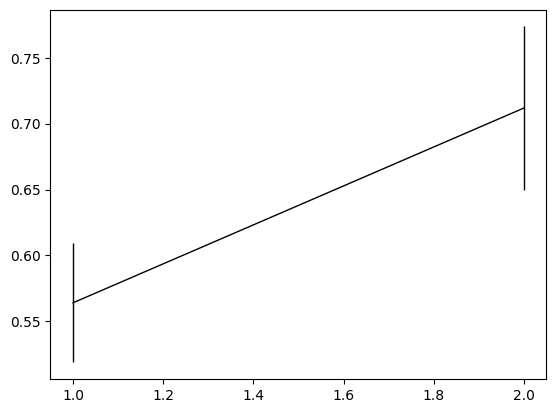

In [337]:
plt.errorbar([1,2], [sd_narrow_medians.mean(), sd_wide_medians.mean()], yerr=[sd_narrow_medians.sem(), sd_wide_medians.sem()], color='k', lw=1)
sd_narrow_medians.sem()

In [619]:
index_filter( compare_res_est, Model1=14, Model2=15)

,Mean Model 1,Mean Model 2,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
0,0.285912,0.315511,-6.74412,38,two-sided,5.469080e-08,"[-0.04, -0.02]",0.168748,2.596e+05,0.176917


## For pres

2.435708621275632% of the data not shown in the figure (σ>3)


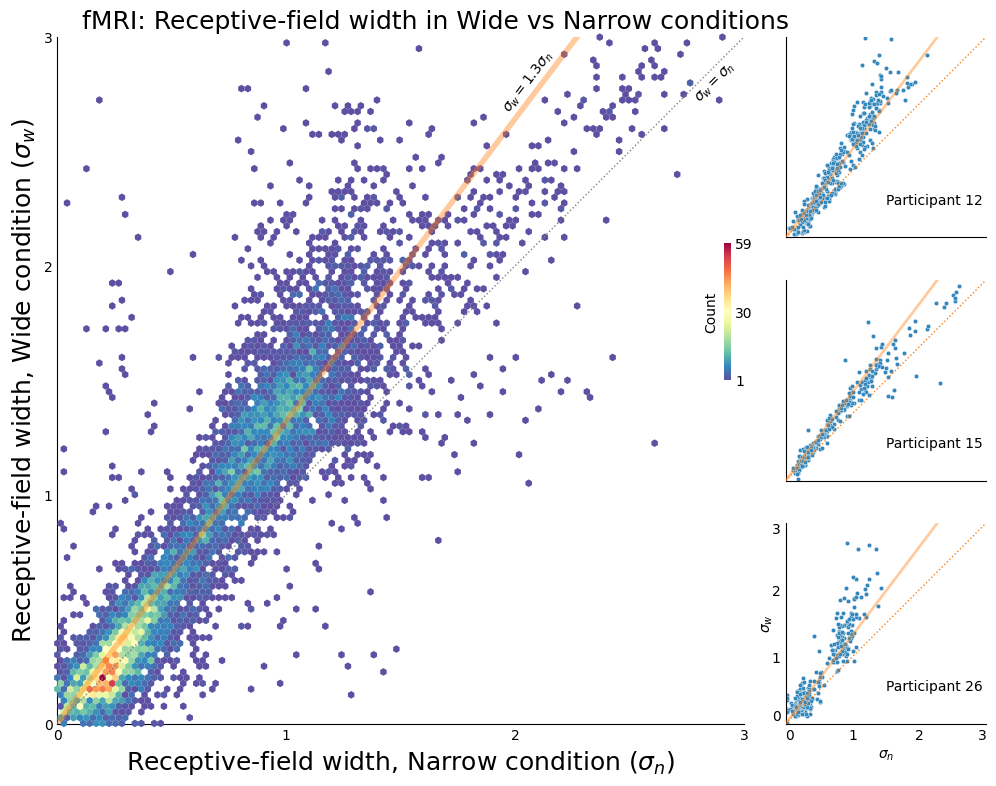

In [232]:
nrows = 4
#fig = plt.figure(figsize=(12, nrows*3))
gs = plt.GridSpec(nrows=nrows, ncols=4, height_ratios=(1,1,1,1.2))
#fig, axs = plt.subplots(nrows=nrows, ncols=4, figsize=(12, nrows*3), height_ratios=(1,1,1,1.2))
fig = plt.figure(figsize=(12, (nrows+.2)*3))
#ax = fig.add_subplot(nrows,4,(1,11))
ax = fig.add_subplot(gs[:3, :3])
ax.set_aspect('equal') #, adjustable='box')

cmap = plt.cm.Spectral_r #RdYlBu_r # 'RdYlBu_r', 'YlGnBu_r', 'Spectral_r', 
SDSD_COLOR = cmap(.1) # THIRD_COLOR
LINE_COLOR = 'C1' # 'xkcd:pastel pink' #'C1' 

σmax = 3
ind = (dfest14.sd.narrow <= σmax) & (dfest14.sd.wide <= σmax)
hb = ax.hexbin(dfest14[ind].sd.narrow, dfest14[ind].sd.wide, gridsize=(60*np.array([np.sqrt(3),1])).astype(int), linewidths=0., cmap=cmap, mincnt=1, edgecolors='none', clip_on=False, zorder=10)
print( f'{(~ind).mean()*100}% of the data not shown in the figure (σ>{σmax})' )

# Colorbar
cbar_ax = ax.inset_axes([0.97, 0.5, .01, .2])
cb = fig.colorbar(hb, cax=cbar_ax, label='Count', ticks=[1, 30, 59], drawedges=False)
cb.ax.yaxis.set_label_position('left')
#cb.ax.yaxis.tick_left()
cbar_ax.tick_params(axis='both', length=0)
cb.outline.set_visible(False)

ax.set_xlim(0,σmax); ax.set_ylim(0,σmax)
ax.tick_params(axis='both', length=0)

median_ratio_sd = dfest15.sd.ratio_wn.groupby('subject').first().median()

ax.axline((0,0), slope=1, color='grey', ls=':', lw=1, zorder=100)
ax.plot([0, σmax], [0, median_ratio_sd*σmax], c=LINE_COLOR, lw=4, alpha=.4, zorder=100)
#ax.plot([0, σmax], [0, np.sqrt(2)*σmax], c=LINE_COLOR, lw=.5, zorder=100)

ax.set_xlabel('Receptive-field width, Narrow condition ($\sigma_n$)', fontsize=18)
ax.set_ylabel('Receptive-field width, Wide condition ($\sigma_w$)', fontsize=18)
ax.set_title('fMRI: Receptive-field width in Wide vs Narrow conditions', x=.55, y=1., fontsize=18)

ax.text(2.975, 2.8+.1, '$\sigma_w=\sigma_n$', fontsize=10, ha='right', va='top', rotation=45) # Same width
ax.text(2.18 , 2.18*median_ratio_sd+.07, f'$\sigma_w={median_ratio_sd:.1f}\sigma_n$', fontsize=10, ha='right', va='top',
        rotation=np.arctan(median_ratio_sd)*180/np.pi,) # backgroundcolor='w', zorder=100)
#ax.text(2., 2.*np.sqrt(2)+.1, 'Width $\\times\sqrt{2}$', fontsize=10, ha='right', va='top', rotation=54.74)
ax.set_yticks([0, 1, 2, 3])
ax.set_xticks([0, 1, 2, 3]);

###### Individual subjects
select_subjs = [12,15,26]
axS1 = fig.add_subplot(gs[0, 3]) # fig.add_subplot(nrows,4,4)
sns.scatterplot(data=index_filter(dfest14, subject=12).sd, x='narrow', y='wide', color=SDSD_COLOR, s=10, alpha=1, ax=axS1)
axS2 = fig.add_subplot(gs[1, 3]) # fig.add_subplot(nrows,4,8)
sns.scatterplot(data=index_filter(dfest14, subject=15).sd, x='narrow', y='wide', color=SDSD_COLOR, s=10, alpha=1, ax=axS2)
axS3 = fig.add_subplot(gs[2, 3]) # fig.add_subplot(nrows,4,12)
sns.scatterplot(data=index_filter(dfest14, subject=26).sd, x='narrow', y='wide', color=SDSD_COLOR, s=10, alpha=1, ax=axS3)
for ii,ax in enumerate([axS1, axS2, axS3]):
    ax.set_aspect('equal')
    ax.axline((0,0), slope=1, color=LINE_COLOR, ls=':', lw=1, zorder=100)
    ax.plot([0, σmax], [0, median_ratio_sd*σmax], c=LINE_COLOR, lw=2, alpha=.4, zorder=100)
    #ax.plot([0, σmax], [0, np.sqrt(2)*σmax], c=LINE_COLOR, lw=.5, zorder=100)
    ax.set_xlim(0, 3); ax.set_ylim(0, 3)
    ax.set_xlabel(None); ax.set_ylabel(None)
    ax.set_xticks([]); ax.set_yticks([])
    #ax.set_title(f'Subject {select_subjs[ii]}', x=.6, y=.1, fontsize=10)
    ax.text(1.5, .5, f'Participant {select_subjs[ii]}', fontsize=10)
#axS1.set_title('Individual participants')
axS3.set_xticks([0,1,2,3]); axS3.set_yticks([0,1,2,3]);
#ax.set_xticklabels([]); ax.set_yticklabels([]);
axS3.tick_params(axis='both', length=0) # labelsize=8, 
axS3.get_xticklabels()[0].set_ha('left'); axS3.get_xticklabels()[-1].set_ha('right')
axS3.get_yticklabels()[-1].set_va('top'); axS3.get_yticklabels()[0].set_va('bottom')
axS3.set_xlabel('$\sigma_n$')
axS3.set_ylabel('$\sigma_w$', labelpad=-2,) # y=.45)

######## Bottom row
gs2 = plt.GridSpec(nrows=nrows, ncols=4, height_ratios=(1,1,1,1.2), hspace=.5, width_ratios=(.9,1.1,1,1), wspace=.4)

if False:
    ######## Median preferred numerosities
    ax = fig.add_subplot(gs2[3,0])

    sd_wide_medians = dfest14[('sd', 'wide')].groupby('subject').median()
    sd_narrow_medians = dfest14[('sd', 'narrow')].groupby('subject').median()
    print( (sd_wide_medians >= sd_narrow_medians).sum(), 'subjects have median $\sigma$ in Wide condition larger than in Narrow condition' )
    print( (sd_wide_medians <  sd_narrow_medians).sum(), 'subjects have median $\sigma$ in Wide condition smaller than in Narrow condition' )
    paired_strip_plot(ax, x1=1, x2=2, y1=sd_narrow_medians, y2=sd_wide_medians, 
                    col1=COLORS_COND[NARROW], col2=COLORS_COND[WIDE], color_incr_line='limegreen', color_decr_line='r',)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Narrow\ncondition', 'Wide\ncondition'])
    ax.set_title("Median $\sigma_n, \sigma_w$")
    ax.set_xlim(0.75, 2.25)
    ax.set_ylim(-.1,1.75)
    # paired test
    paired_test = pg.ttest(sd_narrow_medians, sd_wide_medians, paired=True)
    print(f"Paired t-test: t = {paired_test['T'].iloc[0]:.3f}, p = {paired_test['p-val'].iloc[0]:.3g}, dof = {paired_test['dof'].iloc[0]}")
    # add a horizontal line above the two clouds of dots, with tree stars, reflecting the p-value
    #ax.hlines(0.94*ax.get_ylim()[1], 1, 2, color='k', lw=1.5)
    #ax.text(1.5, 0.95*ax.get_ylim()[1], '***', ha='center', va='center', fontsize=16, color='k')
    star_line(ax, 1, 2, 1.55, paired_test['p-val'].iloc[0], star_size=15, star_offset=-.05, vertical_lines_length=0.)
    ax.tick_params(axis='both', length=0)
    ax.spines.left.set_bounds((0, 1.5))
    ax.spines.bottom.set_bounds((.9, 2.1))
    ax.set_yticks([0, .5, 1, 1.5])


    ######## CDF of change in preferred numerosity

    ax = fig.add_subplot(gs2[3,1])
    all_data = []
    subjects = dfest14.index.get_level_values('subject').unique()
    for subject in subjects:
        data = dfest14.xs(subject, level='subject')[('sd', 'delta_wn')]
        all_data.append(pd.DataFrame({'sd_delta_wn': data.dropna(), 'subject': subject}))
    all_data = pd.concat(all_data, ignore_index=True)
    # Plot the CDFs for each subject in light grey (no hue, loop over subjects)
    c_ind = 'lightgrey'
    for subject in subjects:
        subj_data = all_data[all_data['subject'] == subject]
        sns.ecdfplot(data=subj_data, x='sd_delta_wn', color=c_ind, linewidth=1, alpha=0.7, legend=False, ax=ax)
    # Plot the pooled CDF (all subjects together) in a bold color
    this_color = 'k'; this_lw = 1.5
    sns.ecdfplot(data=all_data, x='sd_delta_wn', color=this_color, linewidth=this_lw, label='Participants pooled', ax=ax)
    print( (all_data.sd_delta_wn<0).mean() * 100, '% of voxels have $\sigma_{w} - \sigma_{n} < 0$' )
    ax.set_title("Distribution of $\sigma_{w} - \sigma_{n}$")
    #ax.set_title("Change in preferred numerosity")
    ax.set_xlabel('$\sigma_{w} - \sigma_{n}$')
    ax.set_ylabel('Empirical CDF')
    ax.legend(handles=[plt.Line2D([0], [0], color=this_color, lw=this_lw, label='Participants\npooled'),
                        plt.Line2D([0], [0], color=c_ind, alpha=.7, lw=1, label='Individual\nparticipants')],
                        loc=(.475,0), handlelength=1.5, frameon=False)
    ax.set_xlim(-.5, 1.5)
    ax.vlines(0, 0, 1, color='black', linestyle='-', lw=1)
    ax.set_yticks([0, .2, .4, .6, .8, 1])
    ax.set_yticklabels(['0', '.2', '.4', '.6', '.8', '1'])
    ax.tick_params(axis='both', length=0)



    ########### Distribution ratio_sd
    ax = fig.add_subplot(gs2[3,2])
    ratio_sd = dfest15.sd.ratio_wn.groupby('subject').first()
    print(ratio_sd.mean())
    dw = .2
    bins = np.arange(-dw, ratio_sd.max()+dw, dw)
    this_color = 1 - .4*( 1 -  np.array( plt.cm.Spectral_r(.02)[:3] ) ) # equivalent to the color with some alpha, on white. (With cB = 1 - alpha*(1-cA), color cB is like (cA,alpha) on white.)
    sns.histplot(ratio_sd, ax=ax, bins=bins, color=this_color, linewidth=.5, element='step', ec='k') # bins=bins, 
    ax.set_xlim(0,2)
    ax.axvline(ratio_sd.median(), color='k', linestyle='-', lw=1)
    ax.text(ratio_sd.median()-.02, 4., f'median$\\approx${ratio_sd.median():.1f}', rotation=90, va='center', ha='right', fontsize=9)
    ax.set_title("Best-fitting scaling factors")
    ax.set_xlabel('Participant-specific scaling')
    ax.set_yticks([0, 5, 10, 15])
    ax.set_xticks([0, .5, 1, 1.5, 2])
    ax.set_xticklabels(['0', '.5', '1', '1.5', '2'])
    ax.set_ylabel('Participants count', labelpad=0)
    ax.tick_params(axis='both', length=0)


    ########## Proportion cvR2>0
    ax = fig.add_subplot(gs2[3,3])
    ####
    modelz = dict( [(4, 'No width change'), (14, 'Free widths'), (31, 'Fixed scaling'), (15, 'Participant-specific scaling')] ) # 
    these_rez = rez_est.loc[:,list(modelz.keys())].rename(columns=modelz)
    these_rez
    #sns.stripplot(these_rez, color=FOURTH_COLOR) 
    sns.pointplot(these_rez, errorbar='se', color='k', markersize=5, linewidth=1, ax=ax)
    ax.set_xlabel(None)
    #### x ticks labels positions
    ax.tick_params(axis='both', length=0)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', va='top', rotation_mode="anchor")
    # Create offset transform
    dx = 12./72.; dy = 2/72. 
    offset = ScaledTranslation(dx, dy, fig.dpi_scale_trans)
    # apply offset transform to all x ticklabels.
    for label in ax.xaxis.get_majorticklabels(): label.set_transform(label.get_transform() + offset)
    ax.set_xlim(-.5,3.5)
    #### y 
    ax.set_yticks([.26, .28, .3, .32, .34])
    ax.set_yticklabels(['.26', '.28', '.30', '.32', '.34'])
    ax.set_ylabel('% $cvR^2 > 0$', y=.5, ha='right')
    ax.spines.left.set_bounds((.26, .34))
    ax.spines.bottom.set_bounds((0, 3))
    sns.despine(fig)
    # (0,4), (3,4), (5,4) 
    vll = 0.005
    star_size = 15
    star_offset = -.005
    star_line(ax, 0, 2, .38 , compare_res_est.loc[(4,31)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
    star_line(ax, 1, 2, .365, compare_res_est.loc[(14,31)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
    star_line(ax, 3, 2, .39 , compare_res_est.loc[(15,31)]['p-val'], vertical_lines_length=vll, star_size=star_size, star_offset=star_offset)
    ax.set_title('Models fits')
    ax.set_ylim(None, .41)

sns.despine(fig)

fig.savefig('figures/pres_sd_wide_vs_narrow.pdf', bbox_inches='tight')